# Rolling ETAS vs FINE — per-window Bayona scores

Extension of the rolling comparison. Each rolling step is one forecast of length `HORIZON_DAYS`. Set `ROLLING_OUTPUT_ROOT` / `HORIZON_DAYS` below for one pre-Ridgecrest horizon at a time (short tree: 0.5 or 1; long tree: 7, 60, or 300). Intensity grids and Bayona scores come from `runnable_code/cache_rolling_analysis.py` under `analysis_cache/`. This notebook always runs that script with no seed cap: every seed that has both etas and FINE catalogs on all steps is loaded. A repeat run only computes new or changed realizations.

The same cache is what a later notebook should load when comparing experiments:

```python
import etas.rolling_analysis as rolling_analysis
store = rolling_analysis.load_analysis(horizon_dir)
```

Shell, from the repository root (example: 1-day short walk):

```bash
python runnable_code/cache_rolling_analysis.py \
  --output-root outputs/rolling_continuation_hauksson_pre_ridgecrest_short \
  --config config/rolling_continuation_hauksson_pre_ridgecrest_short.json \
  --horizon-days 1 --dh 0.1 --num-simulations 200
```

The sections below also include the rolling-comparison figures (count error, cumulative counts, rates, interevent times, magnitudes, and the concatenated CSEP overlays), a separate map for each rate (observed, ETAS mean, one ETAS realization, FINE mean, and one FINE realization), and magnitude likelihoods for the pre-test catalog, the test catalog, and every loaded realization.


In [2]:
%matplotlib inline
from __future__ import annotations

import json
import sys
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "runnable_code" / "run_rolling_continuation.py").is_file():
    if REPO_ROOT.name == "notebooks":
        REPO_ROOT = REPO_ROOT.parent
    else:
        for parent in REPO_ROOT.parents:
            if (parent / "runnable_code" / "run_rolling_continuation.py").is_file():
                REPO_ROOT = parent
                break

for folder in (REPO_ROOT, REPO_ROOT / "runnable_code"):
    if str(folder) not in sys.path:
        sys.path.insert(0, str(folder))

import continuation_ensemble as ceba
import etas.bayona_evaluations as bayona_evaluations
import etas.csep_utils as csep_utils

METHOD_LABELS = dict(ceba.DEFAULT_METHOD_LABELS)
METHOD_COLORS = dict(ceba.DEFAULT_METHOD_COLORS)
FORECAST_CATALOG_NAME = ceba._FORECAST_CATALOG_NAME

# Pre-Ridgecrest test set. Pick one root + horizon:
#   short: 0.5 or 1  → outputs/rolling_continuation_hauksson_pre_ridgecrest_short
#   long:  7, 60, 300 → outputs/rolling_continuation_hauksson_pre_ridgecrest
# Cache loads every seed finished for both methods on all steps (no seed cap).
# ROLLING_OUTPUT_ROOT = REPO_ROOT / "outputs/rolling_continuation_hauksson_pre_ridgecrest_short"
# ROLLING_CONFIG_PATH = REPO_ROOT / "config/rolling_continuation_hauksson_pre_ridgecrest_short.json"
# HORIZON_DAYS = 1
ROLLING_OUTPUT_ROOT = REPO_ROOT / "outputs/rolling_continuation_hauksson_pre_ridgecrest"
ROLLING_CONFIG_PATH = REPO_ROOT / "config/rolling_continuation_hauksson_pre_ridgecrest.json"
HORIZON_DAYS = 7
METHODS = ["etas", "FINE"]
CSEP_DH = 0.1
BAYONA_N_SIM = 200
# Spatial maps: which seed to show (None → first seed).
SPATIAL_MAP_SEED: int | None = None


def show_fig(fig=None):
    if fig is None:
        fig = plt.gcf()
    display(fig)
    plt.close(fig)


def discover_step_dirs(horizon_dir: Path) -> list[tuple[int, Path]]:
    steps = []
    for path in horizon_dir.iterdir():
        if path.is_dir() and path.name.startswith("step_"):
            steps.append((int(path.name.split("_")[1]), path))
    return sorted(steps, key=lambda item: item[0])


def load_step_windows(step_dir: Path) -> dict[str, Any] | None:
    summary_path = step_dir / "step_summary.json"
    if summary_path.is_file():
        summary = json.loads(summary_path.read_text(encoding="utf-8"))
        if isinstance(summary, dict) and "windows" in summary:
            return summary["windows"]
    config_path = step_dir / "step_config.json"
    if not config_path.is_file():
        return None
    cfg = json.loads(config_path.read_text(encoding="utf-8"))
    return {
        "forecast_start": cfg.get("timewindow_end"),
        "forecast_end": cfg.get("testwindow_end"),
    }


def method_dir(step_dir: Path, method: str) -> Path:
    candidate = step_dir / method
    if not candidate.is_dir() and method == ce.METHOD_FINE:
        candidate = step_dir / ce.METHOD_FINE_LEGACY
    return candidate


def load_step_forecast_catalog(step_dir: Path, method: str, seed: int) -> pd.DataFrame | None:
    folder = method_dir(step_dir, method)
    inv_dirs = sorted(folder.glob("inv_*")) if folder.is_dir() else []
    pointer = step_dir / "active_inversion.json"
    if pointer.is_file() and folder.is_dir():
        active_id = json.loads(pointer.read_text(encoding="utf-8")).get("inv_id")
        preferred = folder / f"inv_{active_id}"
        if active_id and preferred.is_dir():
            inv_dirs = [preferred]
    if not inv_dirs:
        return None
    catalog_path = inv_dirs[0] / f"seed_{seed}" / FORECAST_CATALOG_NAME
    if not catalog_path.is_file():
        return None
    return pd.read_csv(catalog_path)


def seeds_for_method(step_dir: Path, method: str) -> set[int]:
    folder = method_dir(step_dir, method)
    if not folder.is_dir():
        return set()
    return {
        int(path.parent.name.split("_")[1])
        for path in folder.glob("inv_*/seed_*/" + FORECAST_CATALOG_NAME)
    }


display(Markdown(
    f"**Horizon:** T = {HORIZON_DAYS:g} days. "
    f"Binary spatial simulations per window: {BAYONA_N_SIM}."
))


**Horizon:** T = 7 days. Binary spatial simulations per window: 200.

## Cached intensity and scores

The next cell runs the cache script, then loads it. Scores and rate maps come from that cache, not from a fresh integral over every seed.


In [3]:
import subprocess

import etas.rolling_analysis as rolling_analysis

script = REPO_ROOT / "runnable_code" / "cache_rolling_analysis.py"
command = [
    sys.executable,
    str(script),
    "--output-root", str(ROLLING_OUTPUT_ROOT),
    "--config", str(ROLLING_CONFIG_PATH),
    "--horizon-days", str(HORIZON_DAYS),
    "--dh", str(CSEP_DH),
    "--num-simulations", str(BAYONA_N_SIM),
    "--methods", *METHODS,
    "--repo-root", str(REPO_ROOT),
]
process = subprocess.Popen(
    command, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True,
)
assert process.stdout is not None
for line in process.stdout:
    print(line, end="", flush=True)
return_code = process.wait()
if return_code != 0:
    raise RuntimeError(f"cache script exited {return_code}")

horizon_dir = rolling_analysis.horizon_directory(ROLLING_OUTPUT_ROOT, HORIZON_DAYS)
store = rolling_analysis.load_analysis(horizon_dir)
horizon_scores = store.scores
SEEDS = store.seeds
MAP_SEED = SPATIAL_MAP_SEED if SPATIAL_MAP_SEED in SEEDS else SEEDS[0]
display(Markdown(
    f"**{store.manifest['n_steps']}** horizon windows, **{len(SEEDS)}** seeds, "
    f"{store.manifest['n_cells']} spatial cells. Map seed **{MAP_SEED}**. "
    f"Cache: `{store.cache_dir}`."
))


cache up to date: 162 steps, 30 seeds
window tests cached: 162 steps, 2 methods, 200 binary likelihood simulations
background probability cached: 162 steps, 2 methods, 30 seeds
magnitude likelihoods cached: 162 steps, 2 methods, 30 seeds
rolling-analysis cache up to date: /home/neriberman/Repos/etas/outputs/rolling_continuation_hauksson_pre_ridgecrest/horizon_7d/analysis_cache
spacetime log-likelihood cached: 162 steps, 30 seeds


**162** horizon windows, **30** seeds, 5881 spatial cells. Map seed **10**. Cache: `/home/neriberman/Repos/etas/outputs/rolling_continuation_hauksson_pre_ridgecrest/horizon_7d/analysis_cache`.

## Scores for each horizon window

Observed earthquakes are those inside the same step. ζ is the binary spatial quantile. Information gain is FINE against ETAS. These rows were written by the cache script.


In [4]:
display(horizon_scores.groupby("method")[["n_forecast", "n_observed", "zeta"]].mean())


,n_forecast,n_observed,zeta
method,,,
FINE,6.017323,6.716049,0.156180
etas,5.615265,6.716049,0.201149


## Figures

Counts use the horizon window as the time unit. The ζ diagram collects one binary spatial quantile from each window. The information-gain curve adds the per-window IGPA of FINE against ETAS. Cumulative counts are drawn when successive windows meet without overlapping.


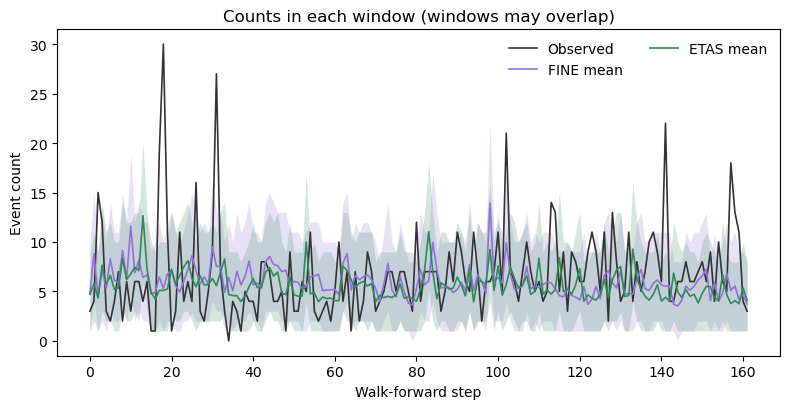

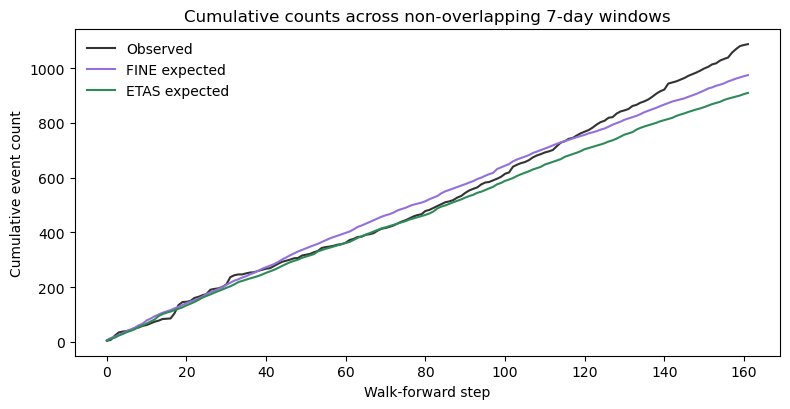

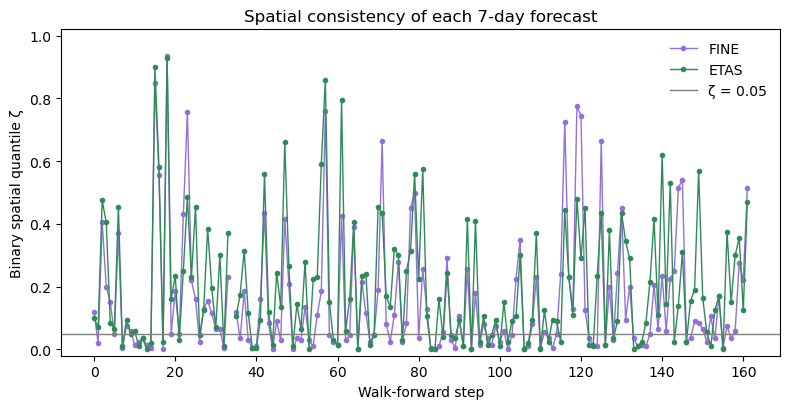

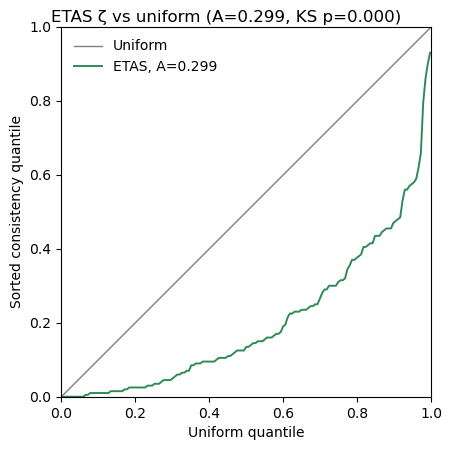

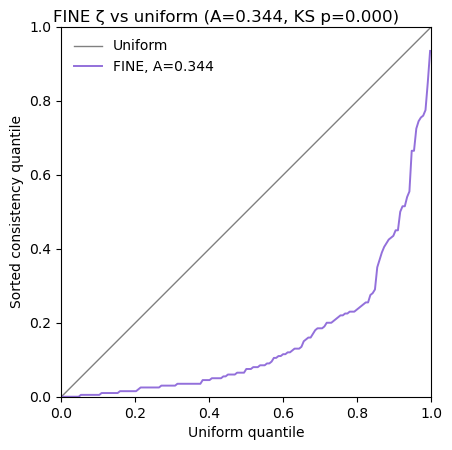

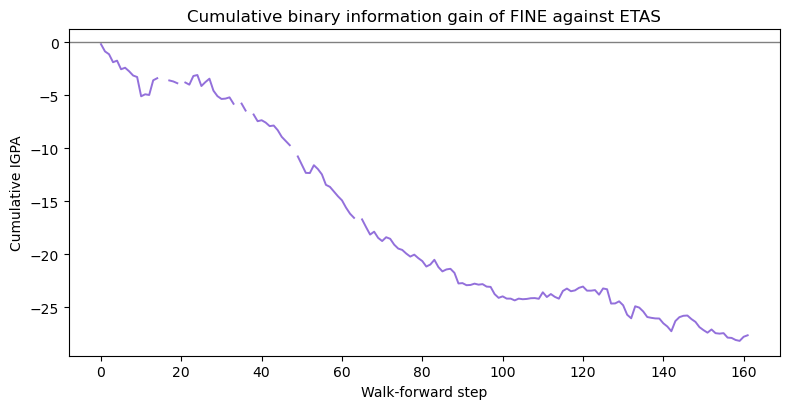

In [5]:
count_frame = horizon_scores[
    ["step_index", "method", "n_forecast", "n_observed", "poisson_low", "poisson_high"]
].copy()
show_fig(bayona_evaluations.plot_walkforward_counts(
    count_frame, colors=METHOD_COLORS, labels=METHOD_LABELS,
))

ordered = horizon_scores.sort_values(["step_index", "method"])
unique_steps = ordered.drop_duplicates("step_index").sort_values("step_index")
if len(unique_steps) >= 2:
    abut = (
        unique_steps["forecast_start"].iloc[1:].reset_index(drop=True)
        - unique_steps["forecast_end"].iloc[:-1].reset_index(drop=True)
    ).abs()
    windows_tile = bool((abut < pd.Timedelta("1min")).all())
else:
    windows_tile = True

if windows_tile:
    fig, ax = plt.subplots(figsize=(8.0, 4.2))
    ax.plot(
        unique_steps["step_index"], unique_steps["n_observed"].cumsum(),
        color="0.2", label="Observed",
    )
    for method, group in ordered.groupby("method", sort=False):
        group = group.sort_values("step_index")
        ax.plot(
            group["step_index"], group["n_forecast"].cumsum(),
            color=METHOD_COLORS.get(method),
            label=f"{METHOD_LABELS.get(method, method)} expected",
        )
    ax.set_xlabel("Walk-forward step")
    ax.set_ylabel("Cumulative event count")
    ax.set_title(f"Cumulative counts across non-overlapping {HORIZON_DAYS:g}-day windows")
    ax.legend(frameon=False)
    fig.tight_layout()
    show_fig(fig)
else:
    display(Markdown("_Windows overlap or leave a gap, so counts are not stacked._"))

fig, ax = plt.subplots(figsize=(8.0, 4.2))
for method, group in ordered.groupby("method", sort=False):
    group = group.sort_values("step_index")
    ax.plot(
        group["step_index"], group["zeta"],
        color=METHOD_COLORS.get(method), marker="o", ms=3, lw=1.0,
        label=METHOD_LABELS.get(method, method),
    )
ax.axhline(0.05, color="0.5", lw=1.0, label="ζ = 0.05")
ax.set_ylim(-0.02, 1.02)
ax.set_xlabel("Walk-forward step")
ax.set_ylabel("Binary spatial quantile ζ")
ax.set_title(f"Spatial consistency of each {HORIZON_DAYS:g}-day forecast")
ax.legend(frameon=False)
fig.tight_layout()
show_fig(fig)

for method in METHODS:
    zeta = ordered.loc[ordered["method"] == method, "zeta"].to_numpy(dtype=float)
    zeta = zeta[np.isfinite(zeta)]
    if zeta.size < 2:
        display(Markdown(
            f"_{METHOD_LABELS.get(method, method)} has fewer than two finite ζ values._"
        ))
        continue
    calibration_fig, summary = bayona_evaluations.plot_quantile_calibration(
        zeta, label=METHOD_LABELS.get(method, method), color=METHOD_COLORS.get(method),
    )
    calibration_fig.suptitle(
        f"{METHOD_LABELS.get(method, method)} ζ vs uniform "
        f"(A={summary['area']:.3f}, KS p={summary['ks_pvalue']:.3f})"
    )
    show_fig(calibration_fig)

fine = ordered.loc[ordered["method"] == "FINE"].sort_values("step_index")
if "IGPA" in fine.columns and fine["IGPA"].notna().any():
    fig, ax = plt.subplots(figsize=(8.0, 4.2))
    ax.plot(fine["step_index"], fine["IGPA"].cumsum(), color=METHOD_COLORS.get("FINE"), lw=1.4)
    ax.axhline(0.0, color="0.5", lw=1.0)
    ax.set_xlabel("Walk-forward step")
    ax.set_ylabel("Cumulative IGPA")
    ax.set_title("Cumulative binary information gain of FINE against ETAS")
    fig.tight_layout()
    show_fig(fig)
else:
    display(Markdown("_No finite information-gain values._"))


## Cumulative number test and window counts

Fig. 3c is one row per model for the whole test. The circle is the total observed count, colored by the percentage discrepancy. The black point is the total expected count from the intensity. The solid bar is the Poisson 95% interval of that total. The dashed bar is the negative-binomial 95% interval, using the same total as its mean and the variance of the saved catalog sizes.

The window-count figure is the Fig. 4 comparison over every forecast window in the test, rather than a daily count inside a chosen sequence. Circles are the observed count in that window. The bands are each model's Poisson 95% interval. A darker circle means more of the models cover that count.


,label,n_forecast,n_observed,delta_percent,poisson_low,poisson_high,nbd_low,nbd_high,catalog_variance
0,ETAS,909.672914,1088.0,16.390357,851.0,969.0,417.0,1589.0,90993.343678
1,FINE,974.806271,1088.0,10.403835,914.0,1036.0,74.0,3002.0,615006.837931


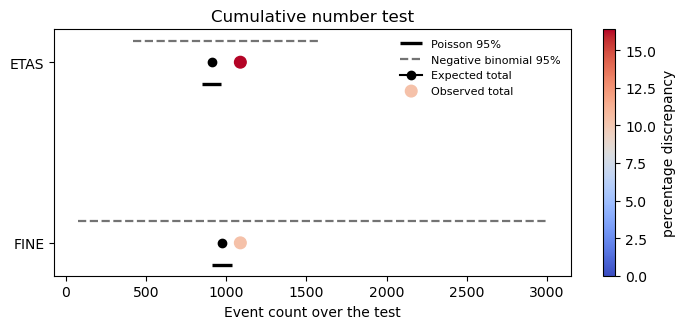

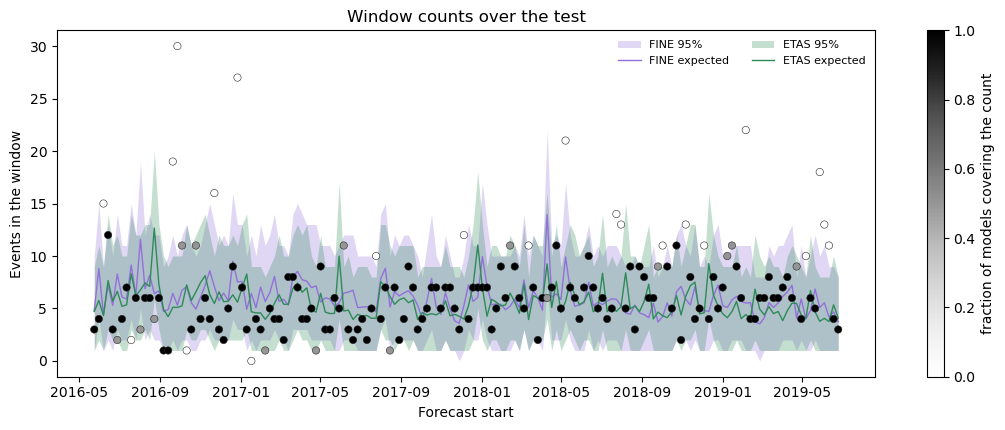

In [6]:
observed_total = float(
    horizon_scores.drop_duplicates("step_index")["n_observed"].sum()
)
cumulative_rows = []
for method in METHODS:
    group = horizon_scores.loc[horizon_scores["method"] == method]
    n_forecast = float(group["n_forecast"].sum())
    catalog_sizes = np.array([
        len(store.event_frame(method, seed)) for seed in SEEDS
    ], dtype=float)
    variance = float(np.var(catalog_sizes, ddof=1))
    poisson_low, poisson_high = bayona_evaluations.fmd_poisson_intervals(
        np.array([n_forecast]),
    )
    nbd = bayona_evaluations.negative_binomial_interval(n_forecast, variance)
    cumulative_rows.append({
        "label": METHOD_LABELS.get(method, method),
        "n_forecast": n_forecast,
        "n_observed": observed_total,
        "delta_percent": bayona_evaluations.count_discrepancy(n_forecast, observed_total),
        "poisson_low": float(poisson_low[0]),
        "poisson_high": float(poisson_high[0]),
        "nbd_low": np.nan if nbd is None else nbd[0],
        "nbd_high": np.nan if nbd is None else nbd[1],
        "catalog_variance": variance,
    })
cumulative_number = pd.DataFrame(cumulative_rows)
display(cumulative_number)
show_fig(bayona_evaluations.plot_cumulative_number_intervals(cumulative_number))

window_counts = horizon_scores[
    ["step_index", "forecast_start", "method", "n_forecast", "n_observed", "poisson_low", "poisson_high"]
].copy()
window_counts["forecast_start"] = pd.to_datetime(window_counts["forecast_start"])
show_fig(bayona_evaluations.plot_window_count_coverage(
    window_counts, colors=METHOD_COLORS, labels=METHOD_LABELS,
))


## Negative-binomial number test and binary conditional likelihood

One row per method per window, from the cached intensity. The number test is PyCSEP `negative_binomial_number_test`: `delta1` is the probability of at least the observed count and `delta2` is the probability of at most that count. The variance is the spread of the saved catalog sizes in that window. A window is inside the 95% test when both tails are at least 0.025. Windows whose catalogs are not overdispersed have no negative-binomial result.

The binary conditional likelihood test is PyCSEP `binary_conditional_likelihood_test` on that window's space–magnitude rate grid. The plotted value is the quantile of the observed binary log-likelihood among the simulated catalogs. Both tests are written by `cache_rolling_analysis.py` / `update_cache` into `analysis_cache/window_tests.csv`. This cell only loads that file (or fills it if intensity changed since the last cache run).

Each panel is a scatter of one per-window metric against the forecast start. The number-test panels show \(\delta_2\), the probability of at most the observed count, for the Poisson test in `horizon_scores` and the negative-binomial test in `window_tests`. The grey lines are 0.025 and 0.975. The binary conditional-likelihood panel is the quantile from `window_tests`. The bottom panel is observed magnitude versus time on that same date axis.


window tests cached: 162 steps, 2 methods, 200 binary likelihood simulations


,n_windows,nbd_scored,nbd_consistent,binary_cl_consistent
method,,,,
FINE,162,162,156,102
etas,162,162,156,118


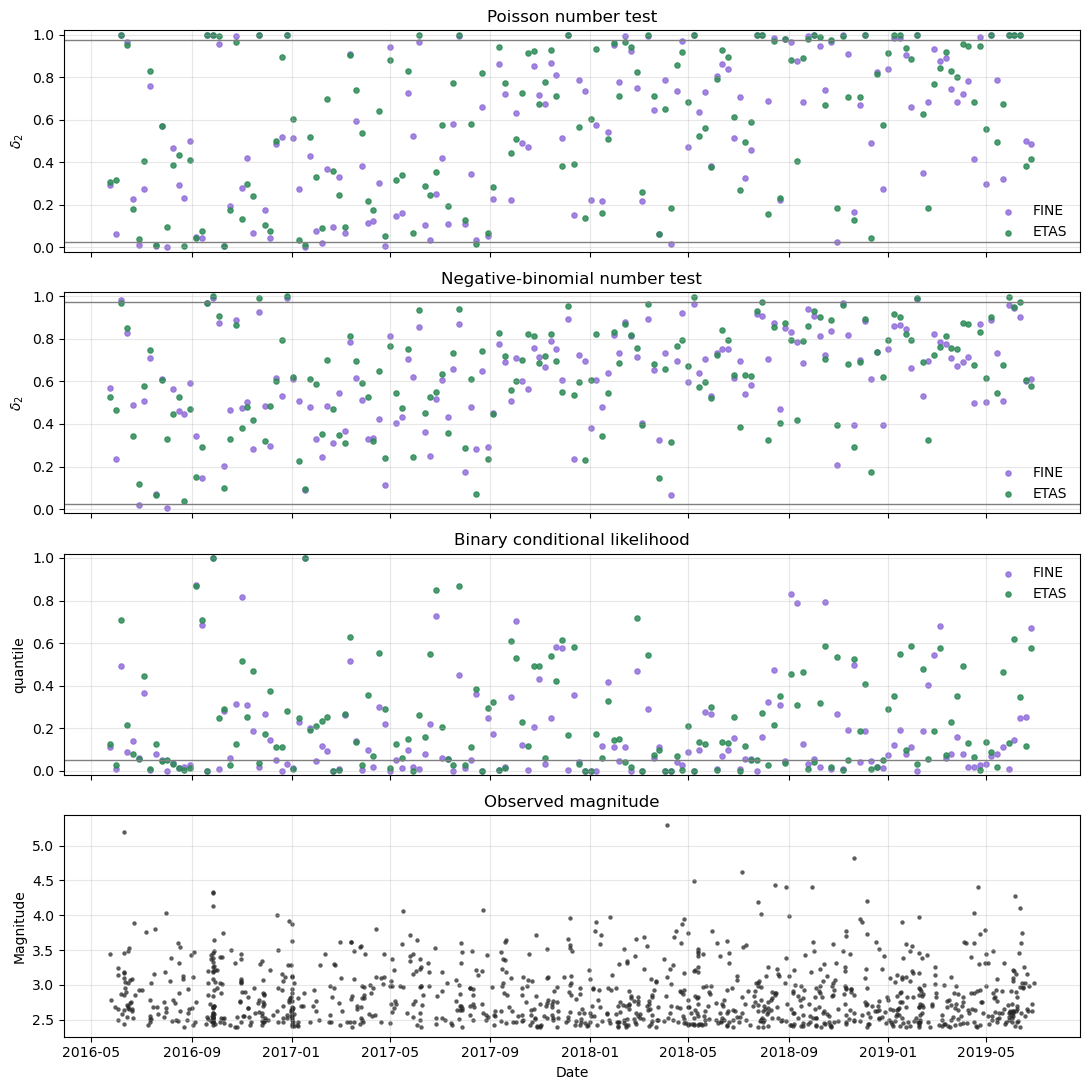

In [7]:
window_tests = rolling_analysis.window_distribution_tests(
    store, num_simulations=BAYONA_N_SIM, progress=print,
)
window_tests["nbd_consistent_95"] = (
    (window_tests["nbd_delta1"] >= 0.025) & (window_tests["nbd_delta2"] >= 0.025)
)
window_tests["binary_cl_consistent_95"] = window_tests["binary_cl_quantile"] >= 0.05
summary = window_tests.groupby("method").agg(
    n_windows=("step_index", "size"),
    nbd_scored=("nbd_delta1", "count"),
    nbd_consistent=("nbd_consistent_95", "sum"),
    binary_cl_consistent=("binary_cl_consistent_95", "sum"),
)
display(summary)

poisson_tails = horizon_scores.copy()
poisson_tails["forecast_start"] = pd.to_datetime(poisson_tails["forecast_start"])
nbd_tails = window_tests.loc[window_tests["nbd_status"] == "normal"].copy()
nbd_tails["forecast_start"] = pd.to_datetime(nbd_tails["forecast_start"])
binary_tails = window_tests.copy()
binary_tails["forecast_start"] = pd.to_datetime(binary_tails["forecast_start"])

observed_events = store.observed_frame()
observed_time = pd.Timestamp("1970-01-01") + pd.to_timedelta(
    observed_events["time_days"], unit="D",
)

tail_panels = (
    (poisson_tails, "poisson_delta2", (0.025, 0.975), "Poisson number test", r"$\delta_2$"),
    (nbd_tails, "nbd_delta2", (0.025, 0.975), "Negative-binomial number test", r"$\delta_2$"),
    (binary_tails, "binary_cl_quantile", (0.05,), "Binary conditional likelihood", "quantile"),
)
fig, axes = plt.subplots(len(tail_panels) + 1, 1, figsize=(11, 11), sharex=True)
for ax, (frame, column, thresholds, title, ylabel) in zip(axes[:-1], tail_panels):
    for method, group in frame.groupby("method", sort=False):
        scored = group.dropna(subset=[column])
        ax.scatter(
            scored["forecast_start"], scored[column],
            s=14, color=METHOD_COLORS.get(method),
            label=METHOD_LABELS.get(method, method), alpha=0.85,
        )
    for threshold in thresholds:
        ax.axhline(threshold, color="0.5", lw=1.0)
    ax.set_ylim(-0.02, 1.02)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(frameon=False)
    ax.grid(True, alpha=0.3)

axes[-1].scatter(
    observed_time, observed_events["magnitude"],
    s=10, c="0.15", alpha=0.75, linewidths=0,
)
axes[-1].set_ylabel("Magnitude")
axes[-1].set_xlabel("Date")
axes[-1].set_title("Observed magnitude")
axes[-1].grid(True, alpha=0.3)
fig.tight_layout()
show_fig(fig)




## N-test sample, one row per realization

Each row is one saved catalog in one forecast window. `n_events` is that realization's event count. `n_forecast` is that realization's expected count: background plus its own triggered field, summed over the forecast grid. `n_observed` and the delta columns are window values, so they repeat across the seeds of a window. The table is also written to `analysis_cache/window_realization_counts.csv`.

In [8]:
origin = pd.Timestamp("1970-01-01")
window_bounds = {
    int(row.step_index): (row.forecast_start, row.forecast_end)
    for row in store.windows().itertuples(index=False)
}
realization_rows = []
for method in METHODS:
    for seed in SEEDS:
        days = store.event_frame(method, seed)["time_days"].to_numpy(dtype=float)
        for step_index, (start, end) in window_bounds.items():
            start_days = float((start - origin) / pd.Timedelta("1D"))
            end_days = float((end - origin) / pd.Timedelta("1D"))
            realization_rows.append({
                "step_index": step_index,
                "forecast_start": start,
                "forecast_end": end,
                "method": method,
                "seed": int(seed),
                "n_events": int(np.count_nonzero((days > start_days) & (days <= end_days))),
            })
n_test_realizations = pd.DataFrame(realization_rows)

magnitude_edges = np.asarray(np.load(store.cache_dir / "grid.npz")["magnitude_edges"], dtype=float)
forecast_rows = []
for meta_path in sorted((store.cache_dir / "steps").glob("step_*.json")):
    meta = json.loads(meta_path.read_text(encoding="utf-8"))
    arrays = np.load(meta_path.with_suffix(".npz"))
    probabilities = csep_utils.gr_magnitude_probabilities(
        magnitude_edges, float(meta["beta"]), float(meta["mc"]),
    )
    magnitude_mass = float(np.sum(probabilities))
    background_sum = float(np.sum(arrays["background"]))
    step_index = int(meta["step_index"])
    for method in METHODS:
        for seed in SEEDS:
            name = f"{method}__{int(seed)}"
            if name not in arrays.files:
                continue
            triggered_sum = float(np.sum(arrays[name]))
            forecast_rows.append({
                "step_index": step_index,
                "method": method,
                "seed": int(seed),
                "n_forecast": (background_sum + triggered_sum) * magnitude_mass,
            })
n_test_realizations = n_test_realizations.merge(
    pd.DataFrame(forecast_rows),
    on=["step_index", "method", "seed"],
    how="left",
)
n_test_realizations = n_test_realizations.merge(
    window_tests[["step_index", "method", "n_observed", "nbd_delta1", "nbd_delta2"]],
    on=["step_index", "method"],
    how="left",
)
n_test_realizations = n_test_realizations.merge(
    horizon_scores[["step_index", "method", "poisson_delta1", "poisson_delta2"]],
    on=["step_index", "method"],
    how="left",
)
n_test_realizations = n_test_realizations.sort_values(
    ["step_index", "method", "seed"],
).reset_index(drop=True)
realization_path = store.cache_dir / "window_realization_counts.csv"
n_test_realizations.to_csv(realization_path, index=False)
display(Markdown(
    f"**{len(n_test_realizations)}** rows "
    f"({n_test_realizations['step_index'].nunique()} windows, "
    f"{n_test_realizations['seed'].nunique()} seeds). `{realization_path}`"
))
n_test_realizations.head()


**9720** rows (162 windows, 30 seeds). `/home/neriberman/Repos/etas/outputs/rolling_continuation_hauksson_pre_ridgecrest/horizon_7d/analysis_cache/window_realization_counts.csv`

,step_index,forecast_start,forecast_end,method,seed,n_events,n_forecast,n_observed,nbd_delta1,nbd_delta2,poisson_delta1,poisson_delta2
0,0,2016-05-23 23:05:46,2016-05-30 23:05:46,FINE,10,16,4.699777,3.0,0.518454,0.566966,0.858297,0.29289
1,0,2016-05-23 23:05:46,2016-05-30 23:05:46,FINE,11,5,3.647495,3.0,0.518454,0.566966,0.858297,0.29289
2,0,2016-05-23 23:05:46,2016-05-30 23:05:46,FINE,12,2,3.625605,3.0,0.518454,0.566966,0.858297,0.29289
3,0,2016-05-23 23:05:46,2016-05-30 23:05:46,FINE,13,5,3.591120,3.0,0.518454,0.566966,0.858297,0.29289
4,0,2016-05-23 23:05:46,2016-05-30 23:05:46,FINE,14,18,6.821034,3.0,0.518454,0.566966,0.858297,0.29289


In [9]:
selected_step_index = 110
selected_method = "etas"
sample_statistics = n_test_realizations.query("step_index == @selected_step_index and method == @selected_method")


In [10]:
from csep.core.forecasts import CatalogForecast
from csep.utils.calc import _compute_likelihood
from csep.utils.stats import cumulative_square_diff

region, study_poly, fit = store.forecast_region()
m_ref = float(fit["m_ref"])
window = sample_statistics.iloc[0]
start = pd.Timestamp(window.forecast_start)
end = pd.Timestamp(window.forecast_end)
origin = pd.Timestamp("1970-01-01")
start_days = float((start - origin) / pd.Timedelta("1D"))
end_days = float((end - origin) / pd.Timedelta("1D"))


def _window_catalog(frame, catalog_id):
    chosen = frame.loc[
        (frame["time_days"] > start_days) & (frame["time_days"] <= end_days)
    ].copy()
    if not chosen.empty:
        chosen["time"] = origin + pd.to_timedelta(chosen["time_days"], unit="D")
        chosen = csep_utils.filter_to_csep_region(
            chosen, region=region, m_ref=m_ref, study_poly=study_poly,
        )
    return csep_utils.dataframe_to_csep_catalog(chosen, catalog_id=catalog_id, region=region)


observed_catalog = _window_catalog(store.observed_frame(), 0)
simulated_catalogs = [
    _window_catalog(store.event_frame(selected_method, int(seed)), index)
    for index, seed in enumerate(SEEDS)
]
forecast = CatalogForecast(
    catalogs=simulated_catalogs,
    region=region,
    name=f"{selected_method}_step_{selected_step_index}",
    start_time=start.to_pydatetime(),
    end_time=end.to_pydatetime(),
    n_cat=len(simulated_catalogs),
    filter_spatial=True,
    apply_filters=True,
)
forecast.get_expected_rates()

union_histogram = np.asarray(forecast.expected_rates.magnitude_counts(), dtype=float)
n_union = float(np.sum(union_histogram))
observed_magnitudes = np.asarray(observed_catalog.magnitude_counts(), dtype=float)
n_observed_magnitudes = float(np.sum(observed_magnitudes))
if n_observed_magnitudes == 0.0 or n_union == 0.0:
    scaled_union = None
    m_observed = np.nan
else:
    scaled_union = union_histogram * (n_observed_magnitudes / n_union)
    m_observed = float(cumulative_square_diff(
        np.log10(observed_magnitudes + 1.0),
        np.log10(scaled_union + 1.0),
    ))

expected_count = float(forecast.expected_rates.sum())
mean_spatial = np.asarray(forecast.expected_rates.spatial_counts(), dtype=float)
observed_spatial = np.asarray(observed_catalog.spatial_counts(), dtype=float)
n_observed_spatial = float(np.sum(observed_spatial))
_, s_observed = _compute_likelihood(
    observed_spatial, mean_spatial, expected_count, n_observed_spatial,
)
if s_observed == -np.inf:
    # Same fallback as catalog_evaluations.spatial_test: drop cells the
    # simulations never occupy, then recompute the observed statistic.
    covered = mean_spatial != 0.0
    _, s_observed = _compute_likelihood(
        observed_spatial[covered],
        mean_spatial[covered],
        expected_count,
        n_observed_spatial,
    )
if not np.isfinite(s_observed):
    s_observed = np.nan

m_by_seed = {}
s_by_seed = {}
for seed, catalog in zip(SEEDS, forecast):
    magnitude_counts = np.asarray(catalog.magnitude_counts(), dtype=float)
    n_events = float(np.sum(magnitude_counts))
    # A catalog with no events is left out of the M-test histogram.
    if scaled_union is None or n_events == 0.0:
        m_by_seed[int(seed)] = np.nan
    else:
        scaled_catalog = magnitude_counts * (n_observed_magnitudes / n_events)
        m_by_seed[int(seed)] = float(cumulative_square_diff(
            np.log10(scaled_catalog + 1.0),
            np.log10(scaled_union + 1.0),
        ))
    gridded = np.asarray(catalog.spatial_counts(), dtype=float)
    _, s_value = _compute_likelihood(gridded, mean_spatial, expected_count, n_observed_spatial)
    s_by_seed[int(seed)] = float(s_value) if np.isfinite(s_value) else np.nan

identity = [
    "step_index", "forecast_start", "forecast_end", "method", "seed",
    "n_events", "n_observed",
]
m_sample_statistics = sample_statistics[identity].copy()
m_sample_statistics["m_statistic"] = m_sample_statistics["seed"].map(m_by_seed)
m_sample_statistics["m_observed"] = m_observed

s_sample_statistics = sample_statistics[identity].copy()
s_sample_statistics["s_statistic"] = s_sample_statistics["seed"].map(s_by_seed)
s_sample_statistics["s_observed"] = s_observed

display(m_sample_statistics)
display(s_sample_statistics)


,step_index,forecast_start,forecast_end,method,seed,n_events,n_observed,m_statistic,m_observed
6630,110,2018-07-02 23:05:46,2018-07-09 23:05:46,etas,10,4,6.0,0.244726,0.433962
6631,110,2018-07-02 23:05:46,2018-07-09 23:05:46,etas,11,5,6.0,0.265560,0.433962
6632,110,2018-07-02 23:05:46,2018-07-09 23:05:46,etas,12,4,6.0,0.593754,0.433962
6633,110,2018-07-02 23:05:46,2018-07-09 23:05:46,etas,13,14,6.0,0.155640,0.433962
6634,110,2018-07-02 23:05:46,2018-07-09 23:05:46,etas,14,8,6.0,0.303548,0.433962
6635,110,2018-07-02 23:05:46,2018-07-09 23:05:46,etas,15,7,6.0,0.212937,0.433962
6636,110,2018-07-02 23:05:46,2018-07-09 23:05:46,etas,16,1,6.0,0.719092,0.433962
6637,110,2018-07-02 23:05:46,2018-07-09 23:05:46,etas,17,2,6.0,0.567661,0.433962
6638,110,2018-07-02 23:05:46,2018-07-09 23:05:46,etas,18,6,6.0,0.462522,0.433962
6639,110,2018-07-02 23:05:46,2018-07-09 23:05:46,etas,19,4,6.0,0.380925,0.433962


,step_index,forecast_start,forecast_end,method,seed,n_events,n_observed,s_statistic,s_observed
6630,110,2018-07-02 23:05:46,2018-07-09 23:05:46,etas,10,4,6.0,-4.644101,-5.46806
6631,110,2018-07-02 23:05:46,2018-07-09 23:05:46,etas,11,5,6.0,-4.913542,-5.46806
6632,110,2018-07-02 23:05:46,2018-07-09 23:05:46,etas,12,4,6.0,-4.348726,-5.46806
6633,110,2018-07-02 23:05:46,2018-07-09 23:05:46,etas,13,14,6.0,-4.597420,-5.46806
6634,110,2018-07-02 23:05:46,2018-07-09 23:05:46,etas,14,8,6.0,-4.681614,-5.46806
6635,110,2018-07-02 23:05:46,2018-07-09 23:05:46,etas,15,7,6.0,-4.842056,-5.46806
6636,110,2018-07-02 23:05:46,2018-07-09 23:05:46,etas,16,1,6.0,-4.774913,-5.46806
6637,110,2018-07-02 23:05:46,2018-07-09 23:05:46,etas,17,2,6.0,-4.774913,-5.46806
6638,110,2018-07-02 23:05:46,2018-07-09 23:05:46,etas,18,6,6.0,-5.101856,-5.46806
6639,110,2018-07-02 23:05:46,2018-07-09 23:05:46,etas,19,4,6.0,-4.892414,-5.46806


In [11]:
from csep.utils.calc import _compute_likelihood, bin1d_vec
from csep.utils.stats import cumulative_square_diff

region, study_poly, fit = store.forecast_region()
m_ref = float(fit["m_ref"])
magnitude_bins = np.asarray(region.magnitudes, dtype=float)
n_magnitude_bins = len(magnitude_bins)
n_spatial_bins = int(region.num_nodes)
origin = pd.Timestamp("1970-01-01")


def _indexed_catalog(frame):
    empty_days = np.empty(0, dtype=float)
    empty_index = np.empty(0, dtype=np.int32)
    if frame.empty:
        return empty_days, empty_index, empty_index
    work = frame.copy()
    work["time"] = origin + pd.to_timedelta(work["time_days"], unit="D")
    work = csep_utils.filter_to_csep_region(
        work, region=region, m_ref=m_ref, study_poly=study_poly,
    )
    if work.empty:
        return empty_days, empty_index, empty_index
    latitude, longitude, magnitude = csep_utils.catalog_lat_lon_mag(work)
    spatial = region.get_index_of(longitude.to_numpy(), latitude.to_numpy())
    magnitude_index = bin1d_vec(
        magnitude.to_numpy(), magnitude_bins, right_continuous=True,
    )
    return (
        work["time_days"].to_numpy(dtype=float),
        spatial.astype(np.int32),
        magnitude_index.astype(np.int32),
    )


def _window_counts(packed, start_days, end_days):
    days, spatial, magnitude_index = packed
    if days.size == 0:
        return np.zeros(n_spatial_bins), np.zeros(n_magnitude_bins)
    inside = (days > start_days) & (days <= end_days)
    spatial_counts = np.bincount(spatial[inside], minlength=n_spatial_bins).astype(float)
    kept = magnitude_index[inside]
    kept = kept[kept >= 0]
    if kept.size == 0:
        magnitude_counts = np.zeros(n_magnitude_bins)
    else:
        magnitude_counts = np.bincount(kept, minlength=n_magnitude_bins).astype(float)
    return spatial_counts, magnitude_counts


def _spatial_observed(observed_counts, mean_counts, expected_count, n_observed):
    """Normalized spatial log-likelihood, with the undersampled-cell fallback."""
    _, value = _compute_likelihood(
        observed_counts, mean_counts, expected_count, n_observed,
    )
    if value == -np.inf:
        covered = mean_counts != 0.0
        _, value = _compute_likelihood(
            observed_counts[covered], mean_counts[covered], expected_count, n_observed,
        )
    if not np.isfinite(value):
        return np.nan
    return float(value)


def quantile_score(simulated, observed):
    """Fraction of simulated statistics at most the observed statistic.

    Zechar et al. (2010) equation 19 for the M-test (κ) and equation 23
    for the S-test (ζ).
    """
    values = np.asarray(simulated, dtype=float)
    values = values[np.isfinite(values)]
    observed = float(observed)
    if values.size == 0 or not np.isfinite(observed):
        return np.nan
    return float(np.count_nonzero(values <= observed) / values.size)


observed_index = _indexed_catalog(store.observed_frame())
catalog_index = {
    (method, int(seed)): _indexed_catalog(store.event_frame(method, int(seed)))
    for method in METHODS
    for seed in SEEDS
}

m_rows = []
s_rows = []
for window in store.windows().itertuples(index=False):
    start_days = float((pd.Timestamp(window.forecast_start) - origin) / pd.Timedelta("1D"))
    end_days = float((pd.Timestamp(window.forecast_end) - origin) / pd.Timedelta("1D"))
    observed_spatial, observed_magnitude = _window_counts(
        observed_index, start_days, end_days,
    )
    n_observed = float(observed_magnitude.sum())
    for method in METHODS:
        spatial_by_seed = []
        magnitude_by_seed = []
        events_by_seed = []
        for seed in SEEDS:
            spatial_counts, magnitude_counts = _window_counts(
                catalog_index[(method, int(seed))], start_days, end_days,
            )
            spatial_by_seed.append(spatial_counts)
            magnitude_by_seed.append(magnitude_counts)
            events_by_seed.append(float(magnitude_counts.sum()))
        spatial_by_seed = np.stack(spatial_by_seed)
        magnitude_by_seed = np.stack(magnitude_by_seed)
        mean_spatial = spatial_by_seed.mean(axis=0)
        mean_magnitude = magnitude_by_seed.mean(axis=0)
        n_union = float(mean_magnitude.sum())
        if n_observed == 0.0 or n_union == 0.0:
            scaled_union = None
            m_observed = np.nan
        else:
            scaled_union = mean_magnitude * (n_observed / n_union)
            m_observed = float(cumulative_square_diff(
                np.log10(observed_magnitude + 1.0),
                np.log10(scaled_union + 1.0),
            ))
        expected_count = float(mean_spatial.sum())
        s_observed = _spatial_observed(
            observed_spatial, mean_spatial, expected_count, n_observed,
        )
        for index, seed in enumerate(SEEDS):
            n_events = events_by_seed[index]
            if scaled_union is None or n_events == 0.0:
                m_statistic = np.nan
            else:
                scaled_catalog = magnitude_by_seed[index] * (n_observed / n_events)
                m_statistic = float(cumulative_square_diff(
                    np.log10(scaled_catalog + 1.0),
                    np.log10(scaled_union + 1.0),
                ))
            _, s_value = _compute_likelihood(
                spatial_by_seed[index], mean_spatial, expected_count, n_observed,
            )
            s_statistic = float(s_value) if np.isfinite(s_value) else np.nan
            shared = {
                "step_index": int(window.step_index),
                "forecast_start": window.forecast_start,
                "forecast_end": window.forecast_end,
                "method": method,
                "seed": int(seed),
                "n_events": n_events,
                "n_observed": n_observed,
            }
            m_rows.append({**shared, "m_statistic": m_statistic, "m_observed": m_observed})
            s_rows.append({**shared, "s_statistic": s_statistic, "s_observed": s_observed})

m_test_realizations = pd.DataFrame(m_rows)
s_test_realizations = pd.DataFrame(s_rows)


def window_quantile(realizations, statistic, observed_column, score_name):
    """One quantile per forecast window, parallel to ``n_test_deltas``."""
    rows = []
    for (step_index, method), group in realizations.groupby(
        ["step_index", "method"], sort=False,
    ):
        rows.append({
            "step_index": int(step_index),
            "forecast_start": group["forecast_start"].iloc[0],
            "method": method,
            "n_observed": float(group["n_observed"].iloc[0]),
            observed_column: float(group[observed_column].iloc[0]),
            score_name: quantile_score(group[statistic], group[observed_column].iloc[0]),
        })
    return pd.DataFrame(rows)


m_test_deltas = window_quantile(
    m_test_realizations, "m_statistic", "m_observed", "kappa",
)
s_test_deltas = window_quantile(
    s_test_realizations, "s_statistic", "s_observed", "zeta",
)
# Bayona et al. (2026) binary spatial quantile: fraction of simulated
# activated-cell catalogs whose jBILL is at most the observed jBILL.
binary_zeta = horizon_scores[["step_index", "method", "zeta"]].rename(
    columns={"zeta": "binary_zeta"},
)
s_test_deltas = s_test_deltas.merge(binary_zeta, on=["step_index", "method"], how="left")

display(m_test_deltas.query(
    "step_index == @selected_step_index and method == @selected_method"
))
display(s_test_deltas.query(
    "step_index == @selected_step_index and method == @selected_method"
))


,step_index,forecast_start,method,n_observed,m_observed,kappa
220,110,2018-07-02 23:05:46,etas,6.0,0.433962,0.766667


,step_index,forecast_start,method,n_observed,s_observed,zeta,binary_zeta
220,110,2018-07-02 23:05:46,etas,6.0,-5.46806,0.066667,0.0


In [12]:
sample_statistics


,step_index,forecast_start,forecast_end,method,seed,n_events,n_forecast,n_observed,nbd_delta1,nbd_delta2,poisson_delta1,poisson_delta2
6630,110,2018-07-02 23:05:46,2018-07-09 23:05:46,etas,10,4,3.586479,6.0,0.707687,0.387035,0.839718,0.27119
6631,110,2018-07-02 23:05:46,2018-07-09 23:05:46,etas,11,5,114.506630,6.0,0.707687,0.387035,0.839718,0.27119
6632,110,2018-07-02 23:05:46,2018-07-09 23:05:46,etas,12,4,3.730375,6.0,0.707687,0.387035,0.839718,0.27119
6633,110,2018-07-02 23:05:46,2018-07-09 23:05:46,etas,13,14,4.007105,6.0,0.707687,0.387035,0.839718,0.27119
6634,110,2018-07-02 23:05:46,2018-07-09 23:05:46,etas,14,8,4.780020,6.0,0.707687,0.387035,0.839718,0.27119
6635,110,2018-07-02 23:05:46,2018-07-09 23:05:46,etas,15,7,5.305389,6.0,0.707687,0.387035,0.839718,0.27119
6636,110,2018-07-02 23:05:46,2018-07-09 23:05:46,etas,16,1,3.502591,6.0,0.707687,0.387035,0.839718,0.27119
6637,110,2018-07-02 23:05:46,2018-07-09 23:05:46,etas,17,2,3.538879,6.0,0.707687,0.387035,0.839718,0.27119
6638,110,2018-07-02 23:05:46,2018-07-09 23:05:46,etas,18,6,4.075954,6.0,0.707687,0.387035,0.839718,0.27119
6639,110,2018-07-02 23:05:46,2018-07-09 23:05:46,etas,19,4,3.640871,6.0,0.707687,0.387035,0.839718,0.27119


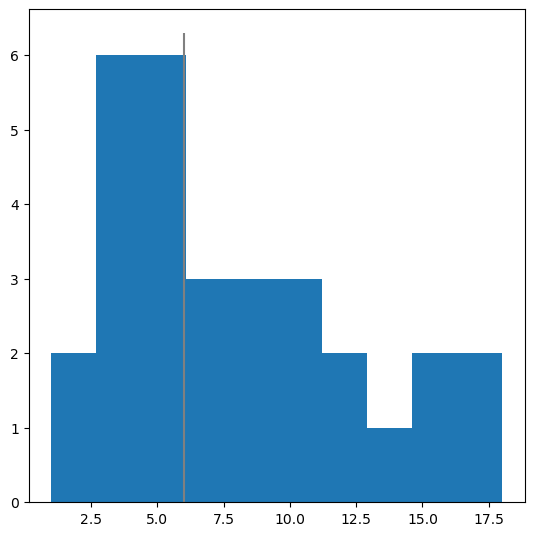

In [13]:
f, ax = plt.subplots(figsize=(6.4, 6.4))
ax.hist(
    sample_statistics.n_events.values,
    )
ax.vlines(
    sample_statistics.n_observed.values[0],
    0,
    ax.get_ylim()[1],
    color="0.5",
    )
show_fig(f)


In [14]:
from scipy import stats as scipy_stats


def delta(n_observed, n_forecast):
    """Zechar et al. (2010) equation 7.

    δ = F(N_obs | N_fore), the right-continuous Poisson cumulative
    distribution with expectation N_fore, evaluated at N_obs. This is the
    probability of observing at most N_obs earthquakes.
    """
    observed = float(n_observed)
    expected = float(n_forecast)
    if not np.isfinite(observed) or not np.isfinite(expected) or expected < 0.0:
        return np.nan
    if observed < 0.0:
        return 0.0
    return float(scipy_stats.poisson.cdf(observed, expected))


delta(
    sample_statistics["n_observed"].iloc[0],
    sample_statistics["n_forecast"].mean(),
)


0.2711904795630517

In [15]:
def window_deltas(realizations: pd.DataFrame) -> pd.DataFrame:
    """One Zechar δ per forecast window.

    N_fore is the mean of the per-seed expected counts in that window.
    """
    rows = []
    for (step_index, method), group in realizations.groupby(
        ["step_index", "method"], sort=False,
    ):
        n_observed = float(group["n_observed"].iloc[0])
        n_forecast = float(group["n_forecast"].mean())
        rows.append({
            "step_index": int(step_index),
            "forecast_start": group["forecast_start"].iloc[0],
            "method": method,
            "n_observed": n_observed,
            "n_forecast": n_forecast,
            "delta": delta(n_observed, n_forecast),
        })
    return pd.DataFrame(rows)


n_test_deltas = window_deltas(n_test_realizations)
n_test_deltas.query(
    "step_index == @selected_step_index and method == @selected_method"
)


,step_index,forecast_start,method,n_observed,n_forecast,delta
221,110,2018-07-02 23:05:46,etas,6.0,8.361946,0.27119


In [16]:
by_method = n_test_deltas.groupby("method")
etas_df = by_method.get_group("etas")
fine_df = by_method.get_group("FINE")


In [17]:
etas_df


,step_index,forecast_start,method,n_observed,n_forecast,delta
1,0,2016-05-23 23:05:46,etas,3.0,4.710346,0.308058
3,1,2016-05-30 23:05:46,etas,4.0,5.761094,0.318306
5,2,2016-06-06 23:05:46,etas,15.0,4.329230,0.999987
7,3,2016-06-13 23:05:46,etas,12.0,7.661544,0.951136
9,4,2016-06-20 23:05:46,etas,3.0,5.708874,0.179134
...,...,...,...,...,...,...
315,157,2019-05-27 23:05:46,etas,18.0,3.778143,1.000000
317,158,2019-06-03 23:05:46,etas,13.0,4.065114,0.999910
319,159,2019-06-10 23:05:46,etas,11.0,3.758841,0.999461
321,160,2019-06-17 23:05:46,etas,4.0,5.347231,0.381812


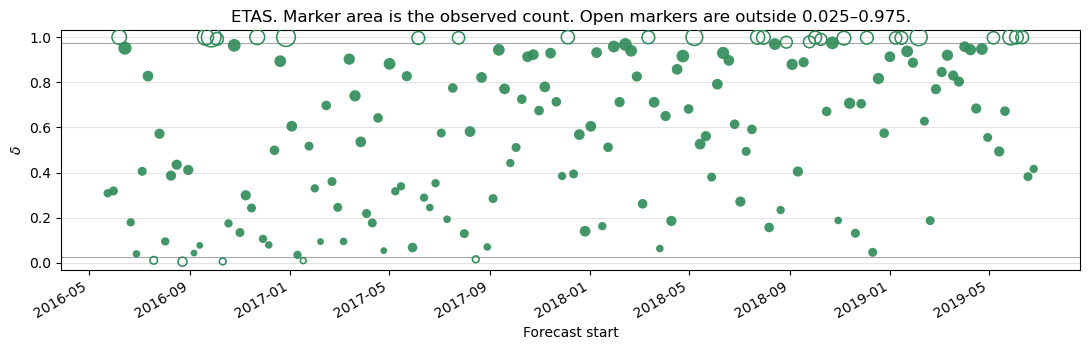

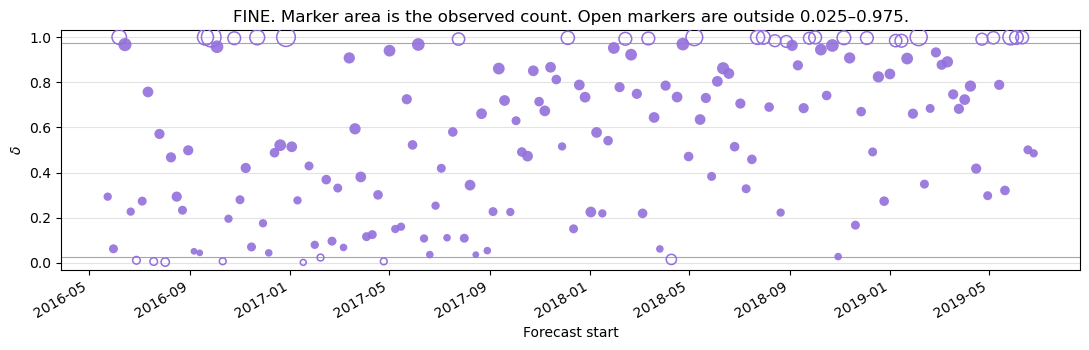

In [18]:
def _delta_time_figure(frame, method):
    frame = frame.sort_values("forecast_start")
    counts = frame["n_observed"].to_numpy(dtype=float)
    sizes = 18.0 + 6.0 * np.maximum(counts, 0.0)
    failed = ((frame["delta"] < 0.025) | (frame["delta"] > 0.975)).to_numpy()
    color = METHOD_COLORS.get(method, "C0")
    label = METHOD_LABELS.get(method, method)

    fig, ax = plt.subplots(figsize=(11, 3.6))
    ax.axhline(0.025, color="0.65", lw=0.8, zorder=0)
    ax.axhline(0.975, color="0.65", lw=0.8, zorder=0)
    ax.scatter(
        frame.loc[~failed, "forecast_start"],
        frame.loc[~failed, "delta"],
        s=sizes[~failed],
        c=color,
        alpha=0.9,
        linewidths=0,
        zorder=2,
    )
    if failed.any():
        ax.scatter(
            frame.loc[failed, "forecast_start"],
            frame.loc[failed, "delta"],
            s=sizes[failed],
            facecolors="none",
            edgecolors=color,
            linewidths=1.1,
            zorder=3,
        )
    ax.set_ylim(-0.03, 1.03)
    ax.set_ylabel(r"$\delta$")
    ax.set_xlabel("Forecast start")
    ax.set_title(f"{label}. Marker area is the observed count. Open markers are outside 0.025–0.975.")
    ax.grid(True, axis="y", alpha=0.35)
    fig.autofmt_xdate()
    fig.tight_layout()
    return fig


for method, frame in (("etas", etas_df), ("FINE", fine_df)):
    show_fig(_delta_time_figure(frame, method))


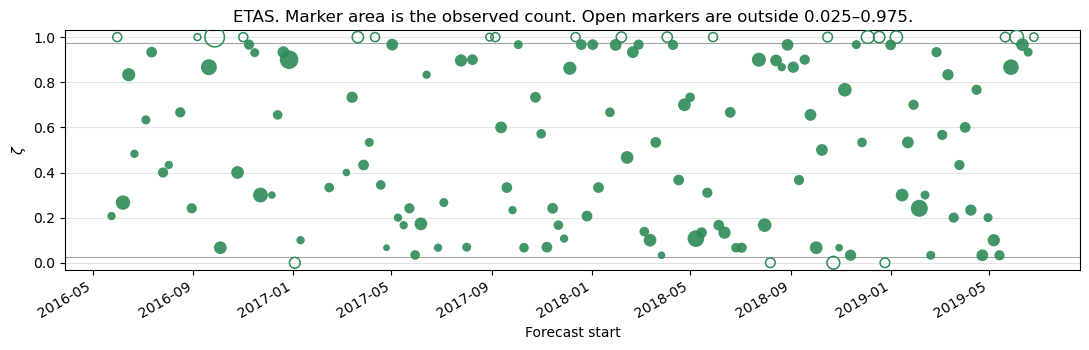

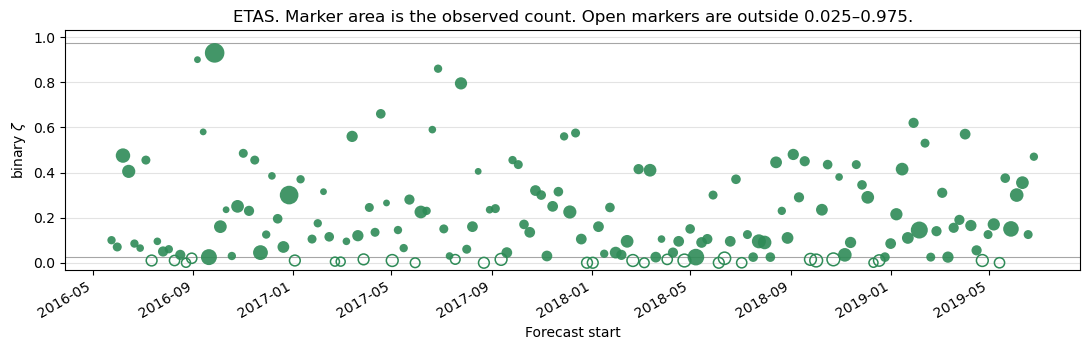

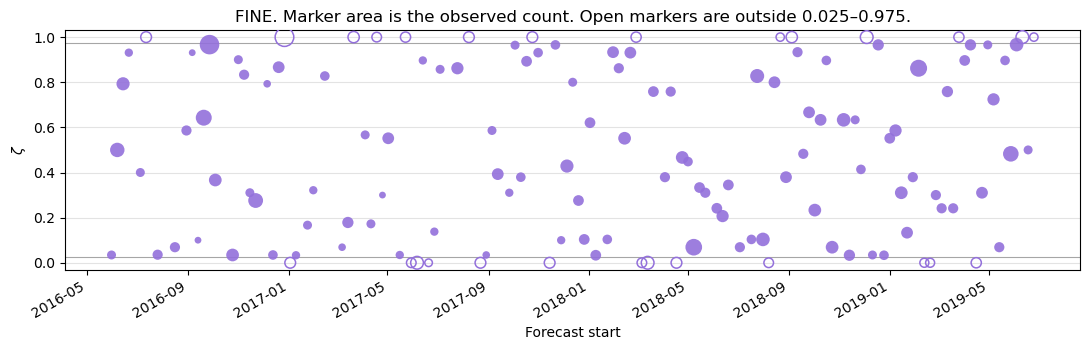

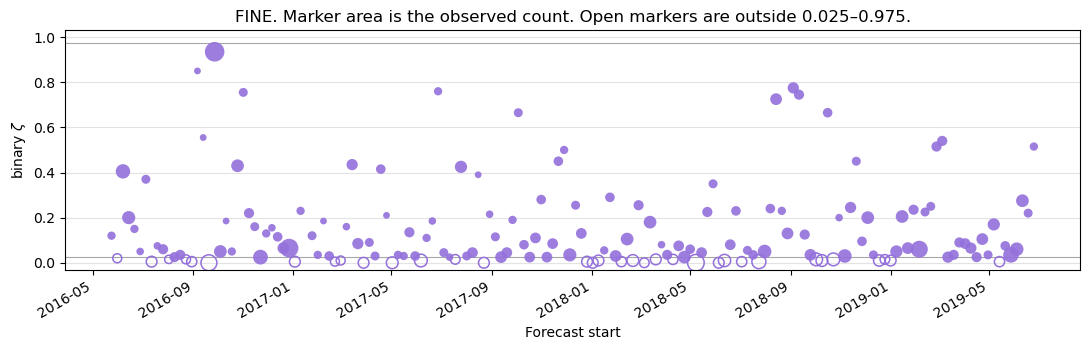

In [19]:
def _quantile_time_figure(frame, method, column, ylabel):
    frame = frame.dropna(subset=[column]).sort_values("forecast_start")
    counts = frame["n_observed"].to_numpy(dtype=float)
    sizes = 18.0 + 6.0 * np.maximum(counts, 0.0)
    values = frame[column].to_numpy(dtype=float)
    failed = (values < 0.025) | (values > 0.975)
    time = frame["forecast_start"].to_numpy()
    color = METHOD_COLORS.get(method, "C0")
    label = METHOD_LABELS.get(method, method)

    fig, ax = plt.subplots(figsize=(11, 3.6))
    ax.axhline(0.025, color="0.65", lw=0.8, zorder=0)
    ax.axhline(0.975, color="0.65", lw=0.8, zorder=0)
    ax.scatter(
        time[~failed], values[~failed],
        s=sizes[~failed], c=color, alpha=0.9, linewidths=0, zorder=2,
    )
    if failed.any():
        ax.scatter(
            time[failed], values[failed],
            s=sizes[failed], facecolors="none", edgecolors=color,
            linewidths=1.1, zorder=3,
        )
    ax.set_ylim(-0.03, 1.03)
    ax.set_ylabel(ylabel)
    ax.set_xlabel("Forecast start")
    ax.set_title(
        f"{label}. Marker area is the observed count. Open markers are outside 0.025–0.975."
    )
    ax.grid(True, axis="y", alpha=0.35)
    fig.autofmt_xdate()
    fig.tight_layout()
    return fig


for method in ("etas", "FINE"):
    frame = s_test_deltas.loc[s_test_deltas["method"] == method]
    show_fig(_quantile_time_figure(frame, method, "zeta", r"$\zeta$"))
    show_fig(_quantile_time_figure(frame, method, "binary_zeta", r"binary $\zeta$"))


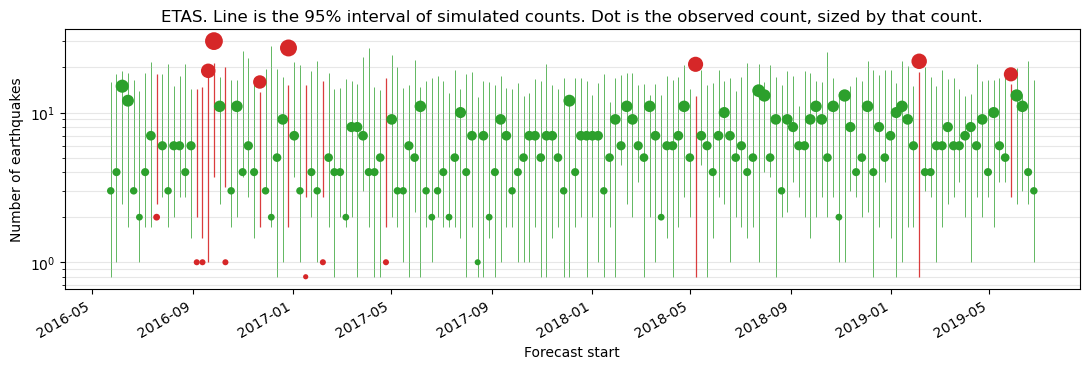

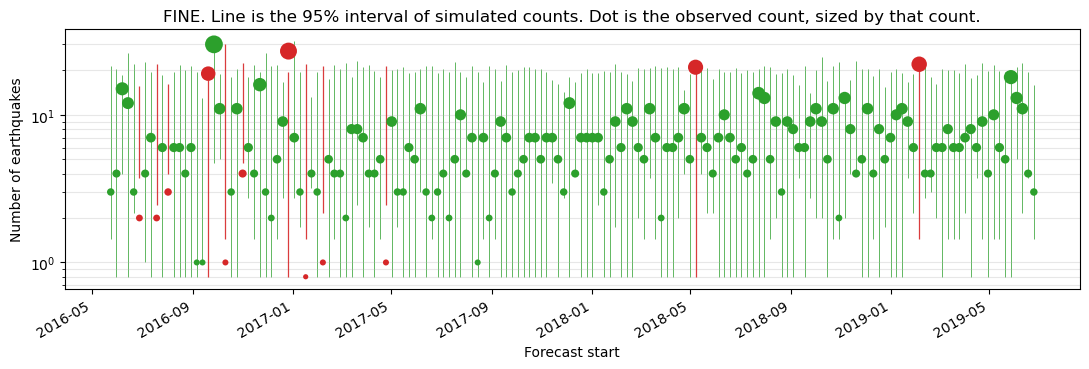

In [20]:
def _forecast_interval_figure(realizations, method):
    """One vertical 95% interval of simulated counts per window."""
    rows = []
    subset = realizations.loc[realizations["method"] == method]
    for step_index, group in subset.groupby("step_index", sort=True):
        counts = group["n_events"].to_numpy(dtype=float)
        low, high = np.quantile(counts, [0.025, 0.975])
        rows.append({
            "forecast_start": group["forecast_start"].iloc[0],
            "n_observed": float(group["n_observed"].iloc[0]),
            "low": float(low),
            "high": float(high),
        })
    frame = pd.DataFrame(rows).sort_values("forecast_start")
    observed = frame["n_observed"].to_numpy(dtype=float)
    low = frame["low"].to_numpy(dtype=float)
    high = frame["high"].to_numpy(dtype=float)
    inside = (observed >= low) & (observed <= high)
    # Log axis cannot show 0. Intervals that reach 0 are drawn from the floor.
    floor = 0.8
    draw_low = np.maximum(low, floor)
    draw_high = np.maximum(high, draw_low)
    draw_observed = np.maximum(observed, floor)
    sizes = 14.0 + 5.0 * np.maximum(observed, 0.0)
    label = METHOD_LABELS.get(method, method)

    fig, ax = plt.subplots(figsize=(11, 3.8))
    ax.vlines(
        frame.loc[inside, "forecast_start"], draw_low[inside], draw_high[inside],
        colors="#2ca02c", lw=0.7, alpha=0.75, zorder=1,
    )
    ax.vlines(
        frame.loc[~inside, "forecast_start"], draw_low[~inside], draw_high[~inside],
        colors="#d62728", lw=0.9, alpha=0.9, zorder=2,
    )
    ax.scatter(
        frame.loc[inside, "forecast_start"], draw_observed[inside],
        s=sizes[inside], c="#2ca02c", linewidths=0, zorder=3,
    )
    ax.scatter(
        frame.loc[~inside, "forecast_start"], draw_observed[~inside],
        s=sizes[~inside], c="#d62728", linewidths=0, zorder=4,
    )
    ax.set_yscale("log")
    ax.set_ylabel("Number of earthquakes")
    ax.set_xlabel("Forecast start")
    ax.set_title(
        f"{label}. Line is the 95% interval of simulated counts. "
        "Dot is the observed count, sized by that count."
    )
    ax.grid(True, axis="y", which="both", alpha=0.3)
    fig.autofmt_xdate()
    fig.tight_layout()
    return fig


for method in ("etas", "FINE"):
    show_fig(_forecast_interval_figure(n_test_realizations, method))


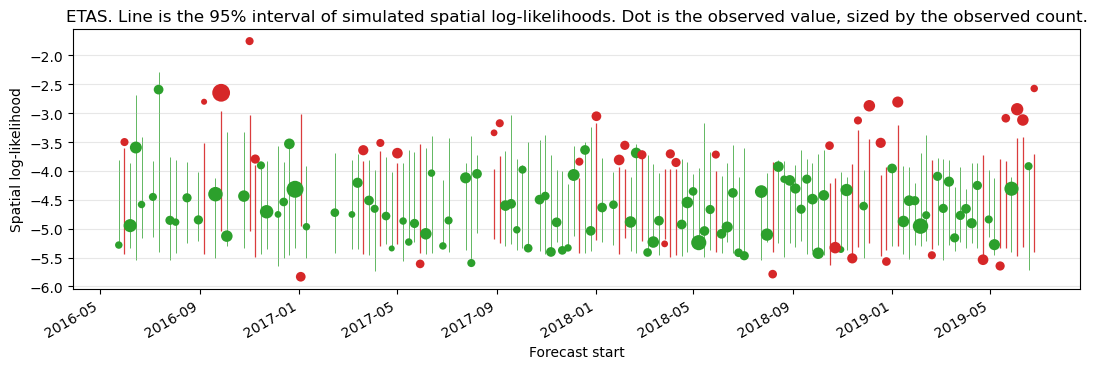

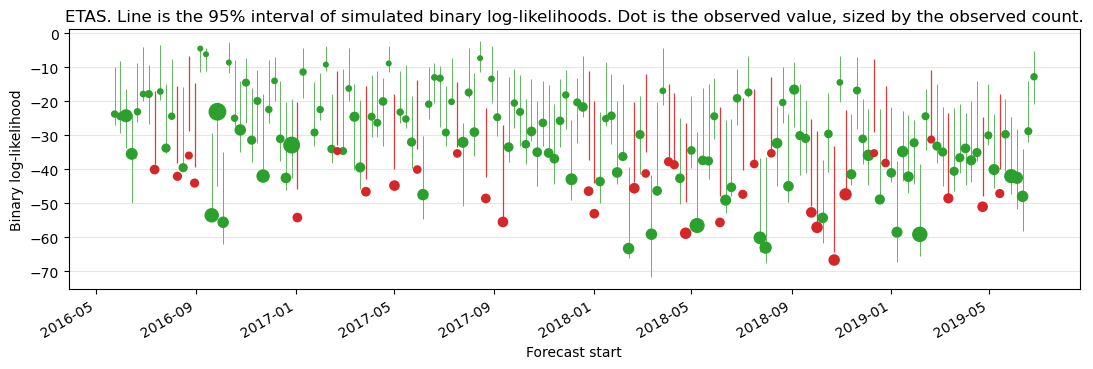

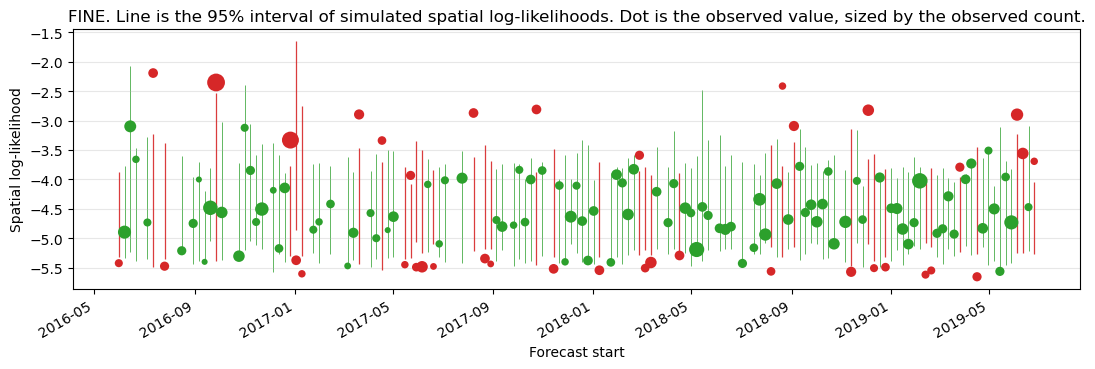

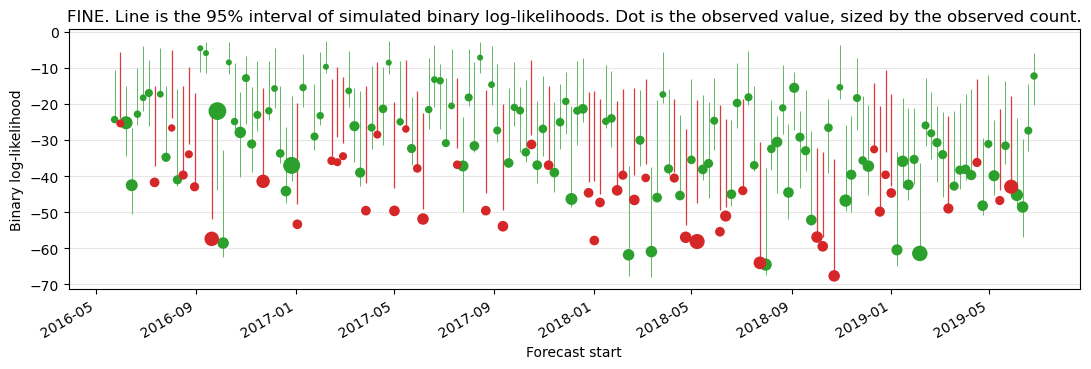

In [21]:
def _statistic_interval_figure(frame, method, ylabel, description):
    """Vertical 95% interval of a simulated statistic, with the observation marked."""
    frame = frame.dropna(subset=["low", "high", "observed"]).sort_values("forecast_start")
    observed = frame["observed"].to_numpy(dtype=float)
    low = frame["low"].to_numpy(dtype=float)
    high = frame["high"].to_numpy(dtype=float)
    inside = (observed >= low) & (observed <= high)
    sizes = 14.0 + 5.0 * np.maximum(frame["n_observed"].to_numpy(dtype=float), 0.0)
    time = frame["forecast_start"].to_numpy()
    label = METHOD_LABELS.get(method, method)

    fig, ax = plt.subplots(figsize=(11, 3.8))
    ax.vlines(time[inside], low[inside], high[inside], colors="#2ca02c", lw=0.7, alpha=0.75, zorder=1)
    ax.vlines(time[~inside], low[~inside], high[~inside], colors="#d62728", lw=0.9, alpha=0.9, zorder=2)
    ax.scatter(time[inside], observed[inside], s=sizes[inside], c="#2ca02c", linewidths=0, zorder=3)
    ax.scatter(time[~inside], observed[~inside], s=sizes[~inside], c="#d62728", linewidths=0, zorder=4)
    ax.set_ylabel(ylabel)
    ax.set_xlabel("Forecast start")
    ax.set_title(
        f"{label}. Line is the 95% interval of {description}. "
        "Dot is the observed value, sized by the observed count."
    )
    ax.grid(True, axis="y", alpha=0.3)
    fig.autofmt_xdate()
    fig.tight_layout()
    return fig


def _zeta_interval_frame(realizations, method):
    rows = []
    subset = realizations.loc[realizations["method"] == method]
    for _, group in subset.groupby("step_index", sort=True):
        values = group["s_statistic"].to_numpy(dtype=float)
        values = values[np.isfinite(values)]
        observed = float(group["s_observed"].iloc[0])
        if values.size < 2 or not np.isfinite(observed):
            continue
        low, high = np.quantile(values, [0.025, 0.975])
        rows.append({
            "forecast_start": group["forecast_start"].iloc[0],
            "n_observed": float(group["n_observed"].iloc[0]),
            "low": float(low),
            "high": float(high),
            "observed": observed,
        })
    return pd.DataFrame(rows)


def _binary_log_likelihood(rates, active_index):
    return float(
        -rates.sum()
        + np.sum(np.log(1.0 - np.exp(-rates[active_index])) + rates[active_index])
    )


def _binary_interval_frame(method):
    """95% interval of Bayona binary log-likelihood simulations for one method."""
    rows = []
    for window in store.windows().itertuples(index=False):
        step_index = int(window.step_index)
        start_days = float((pd.Timestamp(window.forecast_start) - origin) / pd.Timedelta("1D"))
        end_days = float((pd.Timestamp(window.forecast_end) - origin) / pd.Timedelta("1D"))
        inside = (observed_days > start_days) & (observed_days <= end_days)
        observed_counts = np.bincount(
            observed_spatial[inside], minlength=n_spatial_bins,
        ).astype(float)
        active = np.flatnonzero(observed_counts > 0)
        n_active = int(active.size)
        if n_active == 0:
            continue
        path = store.cache_dir / "steps" / f"step_{step_index:03d}.npz"
        arrays = np.load(path)
        names = [name for name in arrays.files if name.startswith(f"{method}__")]
        if not names or "background" not in arrays.files:
            continue
        spatial_rate = np.asarray(arrays["background"], dtype=float) + np.mean(
            [np.asarray(arrays[name], dtype=float) for name in names], axis=0,
        )
        if float(spatial_rate.sum()) <= 0.0:
            continue
        rates = spatial_rate * (n_active / float(spatial_rate.sum()))
        if np.any(rates[active] <= 0.0):
            continue
        positive = rates > 0.0
        rates = rates[positive]
        position = np.full(positive.size, -1, dtype=int)
        position[np.flatnonzero(positive)] = np.arange(int(positive.sum()))
        observed_likelihood = _binary_log_likelihood(rates, position[active])
        weights = rates / rates.sum()
        simulated = np.empty(BAYONA_N_SIM, dtype=float)
        generator = np.random.default_rng(step_index)
        for draw in range(BAYONA_N_SIM):
            chosen = generator.choice(rates.size, size=n_active, replace=False, p=weights)
            simulated[draw] = _binary_log_likelihood(rates, chosen)
        low, high = np.quantile(simulated, [0.025, 0.975])
        rows.append({
            "forecast_start": window.forecast_start,
            "n_observed": float(observed_counts.sum()),
            "low": float(low),
            "high": float(high),
            "observed": observed_likelihood,
        })
    return pd.DataFrame(rows)


origin = pd.Timestamp("1970-01-01")
region, study_poly, fit = store.forecast_region()
m_ref = float(fit["m_ref"])
n_spatial_bins = int(region.num_nodes)
observed_events_indexed = store.observed_frame().copy()
observed_events_indexed["time"] = origin + pd.to_timedelta(
    observed_events_indexed["time_days"], unit="D",
)
observed_events_indexed = csep_utils.filter_to_csep_region(
    observed_events_indexed, region=region, m_ref=m_ref, study_poly=study_poly,
)
observed_latitude, observed_longitude, _ = csep_utils.catalog_lat_lon_mag(
    observed_events_indexed,
)
observed_spatial = region.get_index_of(
    observed_longitude.to_numpy(), observed_latitude.to_numpy(),
).astype(np.int32)
observed_days = observed_events_indexed["time_days"].to_numpy(dtype=float)

for method in ("etas", "FINE"):
    show_fig(_statistic_interval_figure(
        _zeta_interval_frame(s_test_realizations, method),
        method,
        "Spatial log-likelihood",
        "simulated spatial log-likelihoods",
    ))
    show_fig(_statistic_interval_figure(
        _binary_interval_frame(method),
        method,
        "Binary log-likelihood",
        "simulated binary log-likelihoods",
    ))


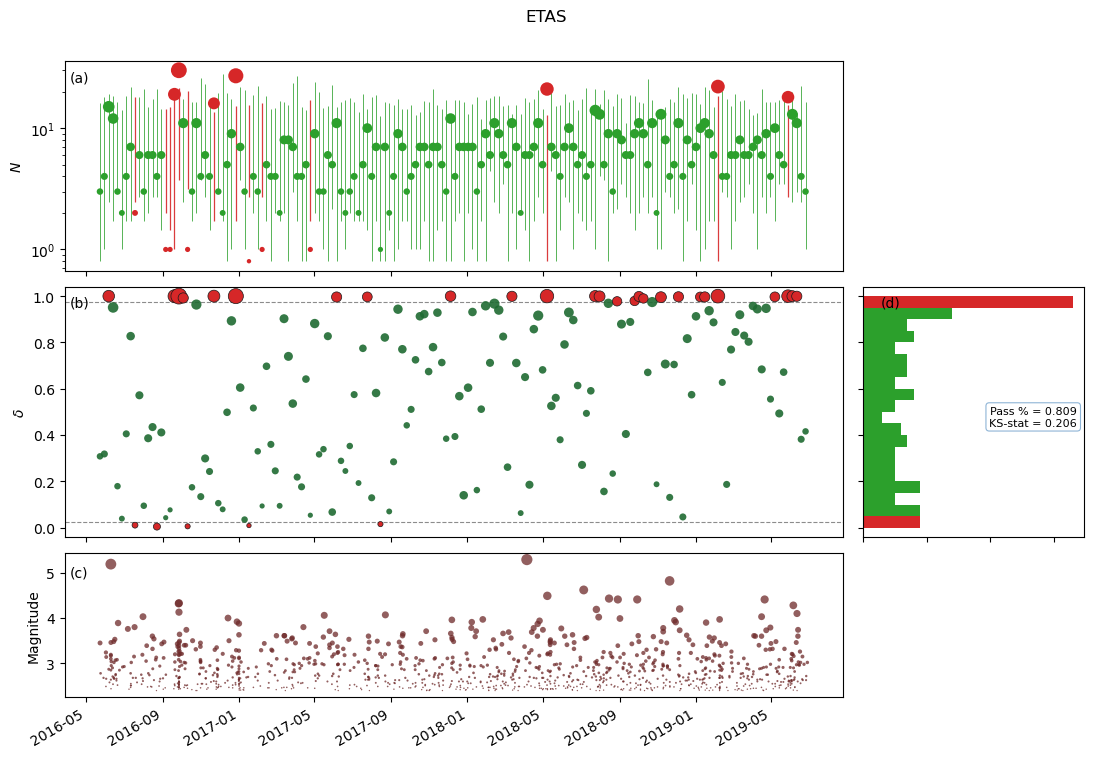

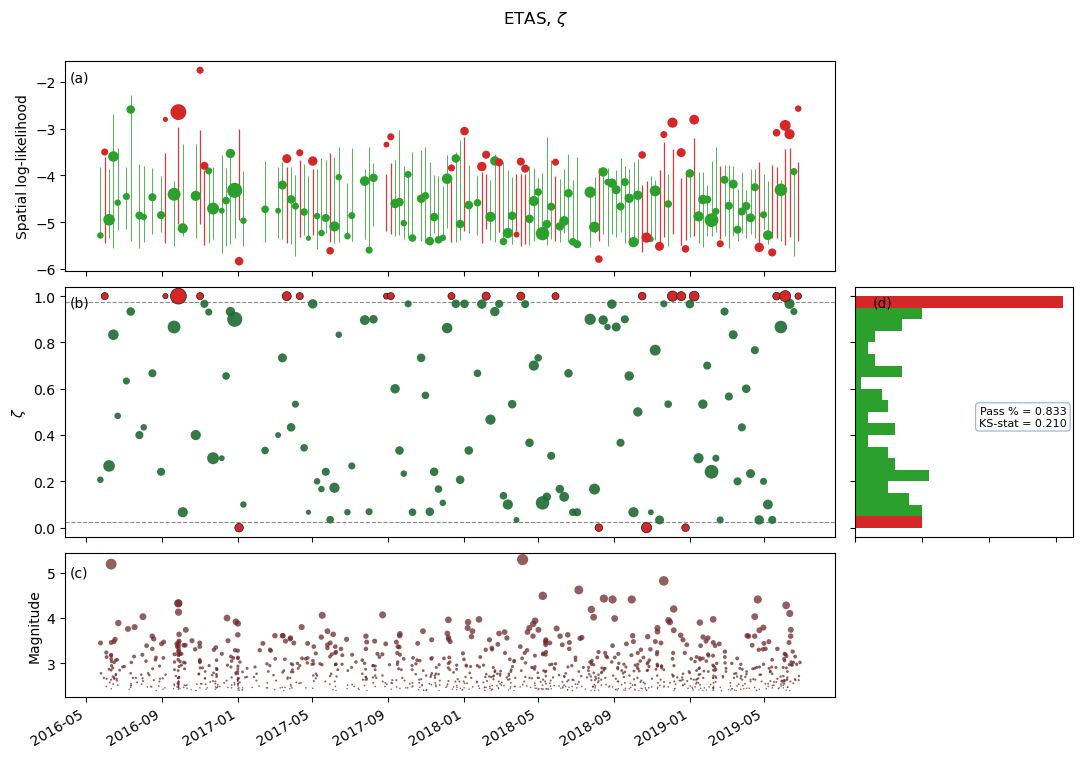

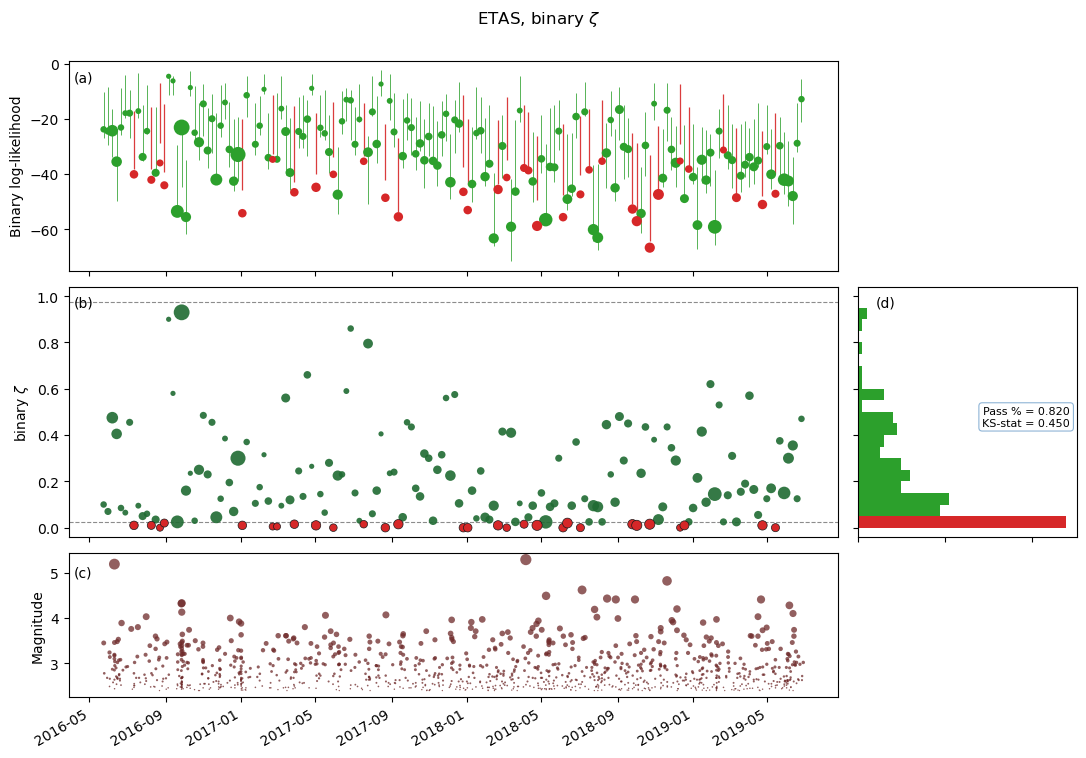

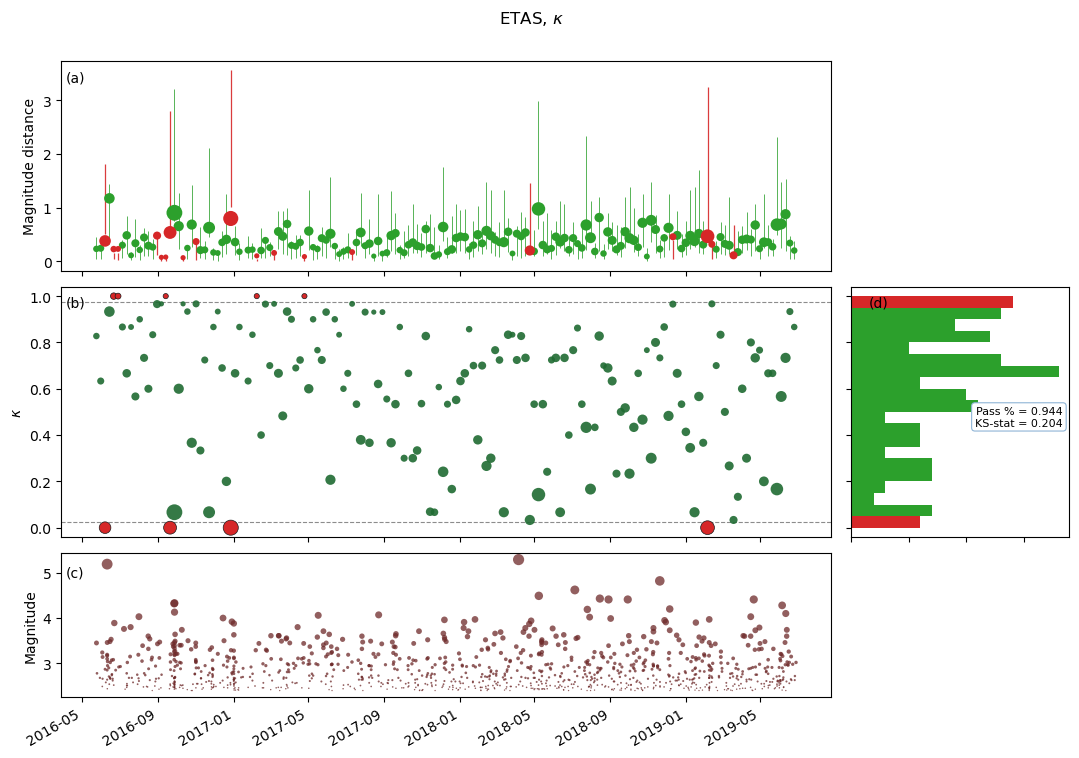

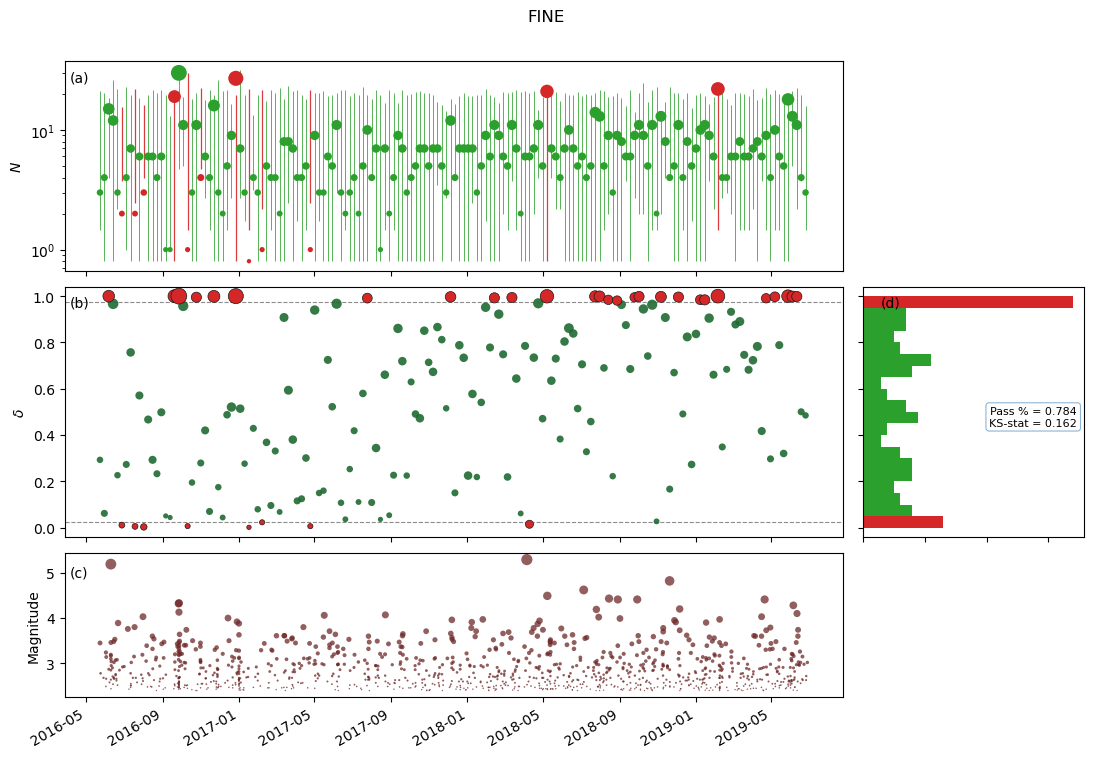

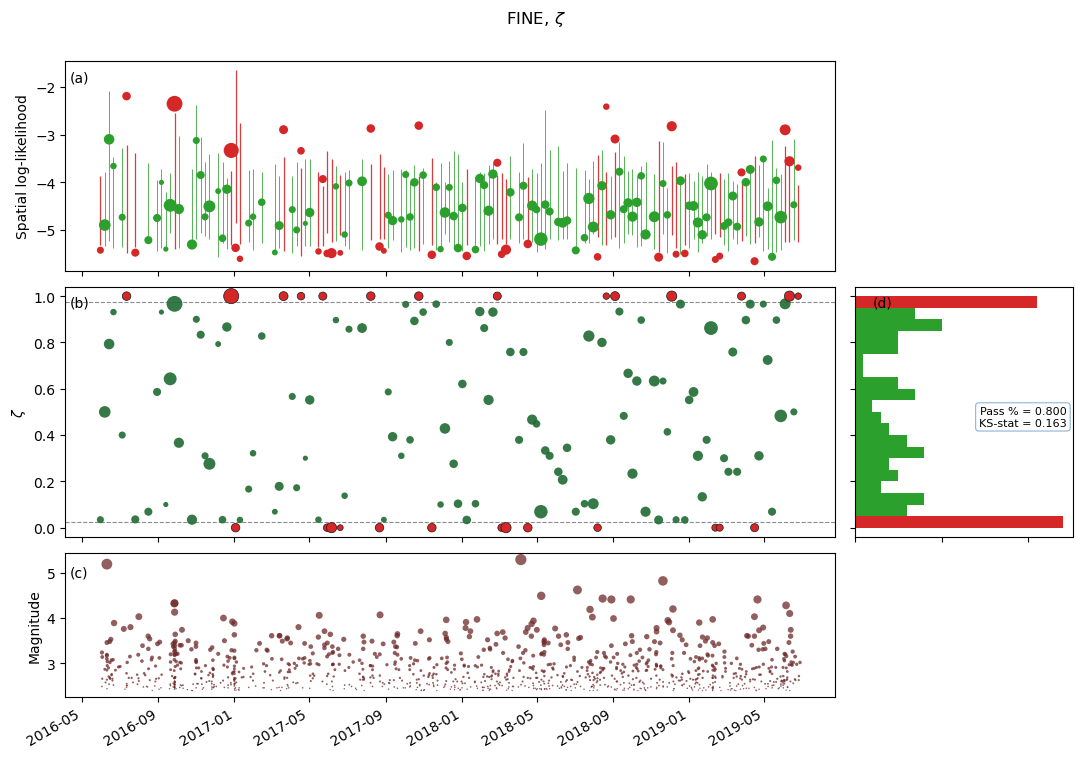

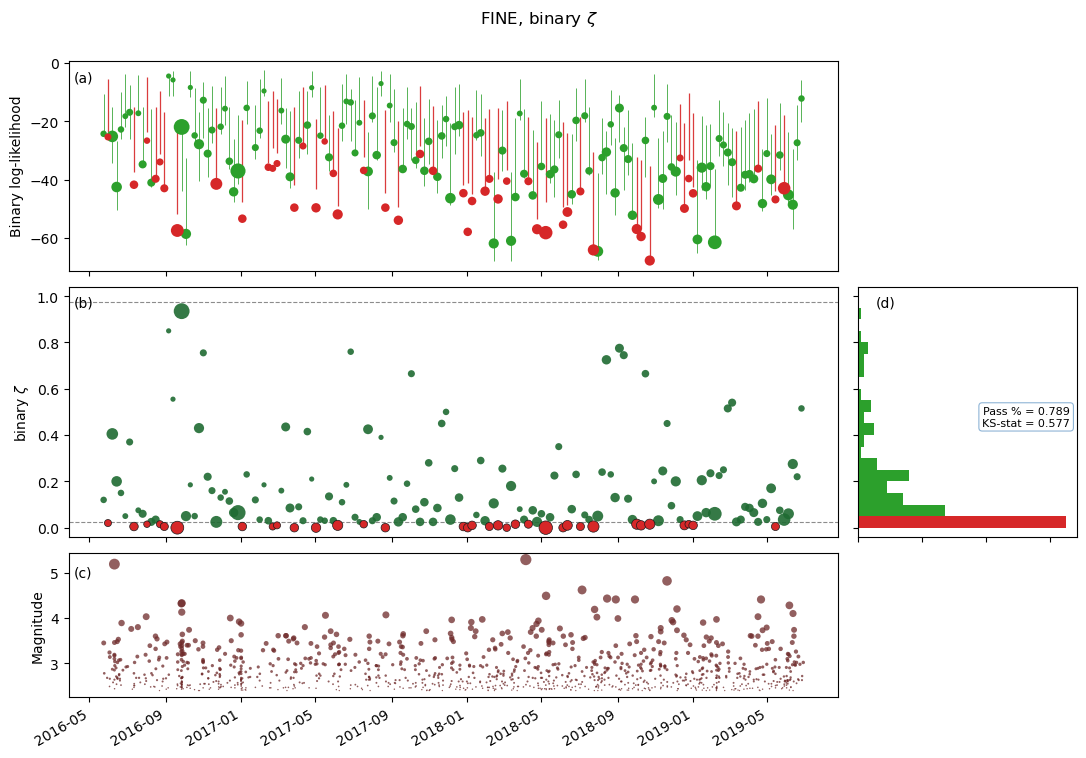

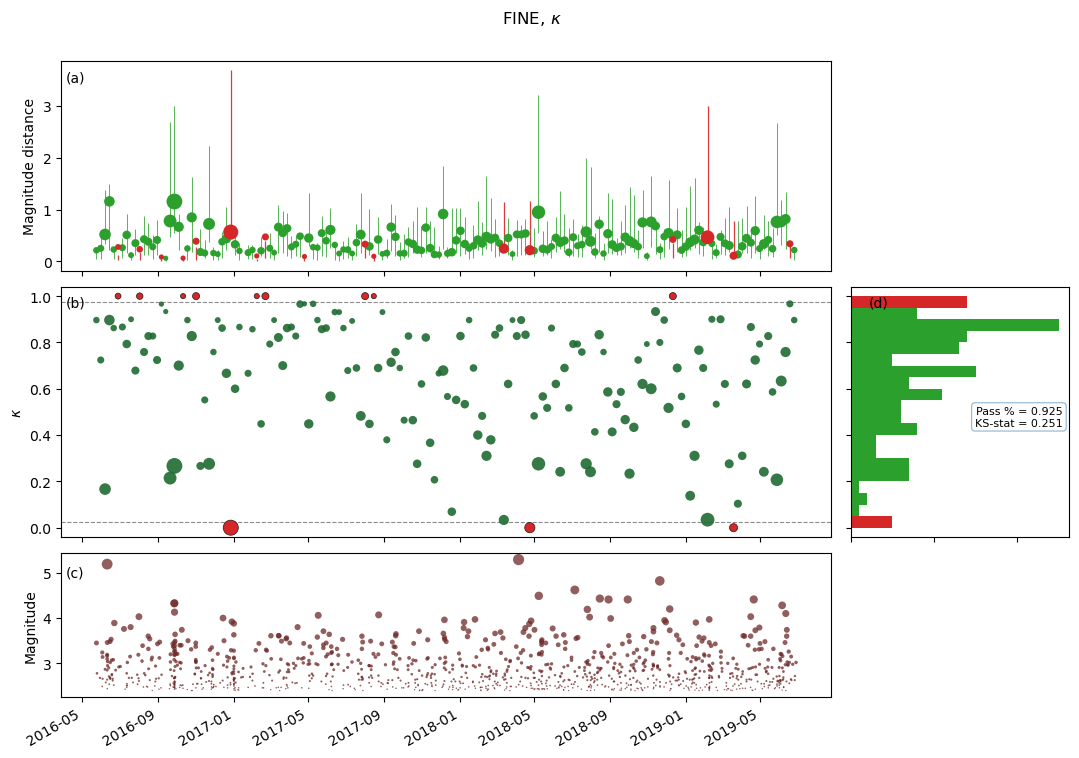

In [22]:
LOW_QUANTILE = 0.025
HIGH_QUANTILE = 0.975
PASS_COLOR = "#2ca02c"
FAIL_COLOR = "#d62728"


def _figure_15(realizations, deltas, method):
    """Stockman et al. Figure 15 for one method.

    (a) 95% interval of simulated counts. (b) Zechar δ, marker area equal to
    the observed count. (c) Observed magnitude. (d) Histogram of δ.
    """
    subset = realizations.loc[realizations["method"] == method]
    frame = deltas.loc[deltas["method"] == method].sort_values("forecast_start")
    label = METHOD_LABELS.get(method, method)

    interval_rows = []
    for _, group in subset.groupby("step_index", sort=True):
        counts = group["n_events"].to_numpy(dtype=float)
        low, high = np.quantile(counts, [LOW_QUANTILE, HIGH_QUANTILE])
        interval_rows.append({
            "forecast_start": group["forecast_start"].iloc[0],
            "n_observed": float(group["n_observed"].iloc[0]),
            "low": float(low),
            "high": float(high),
        })
    intervals = pd.DataFrame(interval_rows).sort_values("forecast_start")
    observed = intervals["n_observed"].to_numpy(dtype=float)
    low = intervals["low"].to_numpy(dtype=float)
    high = intervals["high"].to_numpy(dtype=float)
    inside = (observed >= low) & (observed <= high)
    floor = 0.8
    draw_low = np.maximum(low, floor)
    draw_high = np.maximum(high, draw_low)
    draw_observed = np.maximum(observed, floor)
    count_sizes = np.clip(10.0 + 4.0 * np.maximum(observed, 0.0), 10.0, 320.0)
    interval_time = intervals["forecast_start"].to_numpy()

    delta = frame["delta"].to_numpy(dtype=float)
    delta_time = frame["forecast_start"].to_numpy()
    delta_sizes = np.clip(
        10.0 + 4.0 * np.maximum(frame["n_observed"].to_numpy(dtype=float), 0.0),
        10.0, 320.0,
    )
    passed = np.isfinite(delta) & (delta >= LOW_QUANTILE) & (delta <= HIGH_QUANTILE)
    failed = np.isfinite(delta) & ~passed
    finite = np.isfinite(delta)
    pass_rate = float(passed[finite].mean()) if finite.any() else np.nan
    ks_stat = (
        float(scipy_stats.kstest(delta[finite], "uniform").statistic)
        if finite.any() else np.nan
    )

    span_start = pd.to_datetime(subset["forecast_start"]).min()
    span_end = pd.to_datetime(subset["forecast_end"]).max()
    events = observed_events.copy()
    events["time"] = pd.to_datetime(observed_time)
    events = events.loc[(events["time"] >= span_start) & (events["time"] <= span_end)]
    magnitudes = events["magnitude"].to_numpy(dtype=float)
    magnitude_sizes = 6.0 * np.square(np.maximum(magnitudes - 2.0, 0.35))

    fig = plt.figure(figsize=(11.2, 8.6))
    grid = fig.add_gridspec(
        3, 2,
        height_ratios=[1.05, 1.25, 0.72],
        width_ratios=[4.4, 1.25],
        hspace=0.08,
        wspace=0.04,
    )
    ax_counts = fig.add_subplot(grid[0, 0])
    ax_delta = fig.add_subplot(grid[1, 0], sharex=ax_counts)
    ax_hist = fig.add_subplot(grid[1, 1], sharey=ax_delta)
    ax_magnitude = fig.add_subplot(grid[2, 0], sharex=ax_counts)

    ax_counts.vlines(
        interval_time[inside], draw_low[inside], draw_high[inside],
        colors=PASS_COLOR, lw=0.7, alpha=0.8, zorder=1,
    )
    ax_counts.vlines(
        interval_time[~inside], draw_low[~inside], draw_high[~inside],
        colors=FAIL_COLOR, lw=0.9, alpha=0.9, zorder=2,
    )
    ax_counts.scatter(
        interval_time[inside], draw_observed[inside],
        s=count_sizes[inside], c=PASS_COLOR, linewidths=0, zorder=3,
    )
    ax_counts.scatter(
        interval_time[~inside], draw_observed[~inside],
        s=count_sizes[~inside], c=FAIL_COLOR, linewidths=0, zorder=4,
    )
    ax_counts.set_yscale("log")
    ax_counts.set_ylabel(r"$N$")
    ax_counts.text(0.006, 0.90, "(a)", transform=ax_counts.transAxes)

    ax_delta.axhline(LOW_QUANTILE, color="0.55", lw=0.8, ls="--", zorder=0)
    ax_delta.axhline(HIGH_QUANTILE, color="0.55", lw=0.8, ls="--", zorder=0)
    ax_delta.scatter(
        delta_time[passed], delta[passed],
        s=delta_sizes[passed], c="#1f6b32", linewidths=0, alpha=0.9, zorder=2,
    )
    if failed.any():
        ax_delta.scatter(
            delta_time[failed], delta[failed],
            s=delta_sizes[failed], c=FAIL_COLOR,
            edgecolors="0.1", linewidths=0.5, zorder=3,
        )
    ax_delta.set_ylim(-0.04, 1.04)
    ax_delta.set_ylabel(r"$\delta$")
    ax_delta.text(0.006, 0.92, "(b)", transform=ax_delta.transAxes)

    bins = np.linspace(0.0, 1.0, 21)
    hist_counts, edges = np.histogram(delta[finite], bins=bins)
    bar_colors = [
        FAIL_COLOR if (right <= 0.05 or left >= 0.95) else PASS_COLOR
        for left, right in zip(edges[:-1], edges[1:])
    ]
    ax_hist.barh(
        edges[:-1], hist_counts, height=np.diff(edges),
        align="edge", color=bar_colors, linewidth=0,
    )
    ax_hist.set_xlabel("Frequency")
    ax_hist.tick_params(labelleft=False)
    ax_hist.text(0.08, 0.92, "(d)", transform=ax_hist.transAxes)
    ax_hist.text(
        0.97, 0.48,
        f"Pass % = {pass_rate:.3f}\nKS-stat = {ks_stat:.3f}",
        transform=ax_hist.transAxes, ha="right", va="center", fontsize=8,
        bbox={"boxstyle": "round", "facecolor": "white", "edgecolor": "#8eb4d6", "linewidth": 0.8},
    )

    ax_magnitude.scatter(
        events["time"], magnitudes,
        s=magnitude_sizes, c="#6e2a2a", alpha=0.75, linewidths=0,
    )
    ax_magnitude.set_ylabel("Magnitude")
    ax_magnitude.text(0.006, 0.84, "(c)", transform=ax_magnitude.transAxes)

    plt.setp(ax_counts.get_xticklabels(), visible=False)
    plt.setp(ax_delta.get_xticklabels(), visible=False)
    fig.autofmt_xdate()
    fig.suptitle(label, y=1.0)
    fig.subplots_adjust(top=0.94, left=0.07, right=0.98)
    return fig


def _figure_15_score(intervals, quantiles, method, score_column, score_label, likelihood_label):
    """Figure 15 layout for one method and one quantile.

    (a) 95% interval of the simulated statistic. (b) The quantile, marker
    area equal to the observed count. (c) Observed magnitude. (d) Histogram
    of the quantile.
    """
    intervals = intervals.dropna(subset=["low", "high", "observed"]).sort_values("forecast_start")
    quantiles = quantiles.dropna(subset=[score_column]).sort_values("forecast_start")
    label = METHOD_LABELS.get(method, method)

    likelihood = intervals["observed"].to_numpy(dtype=float)
    low = intervals["low"].to_numpy(dtype=float)
    high = intervals["high"].to_numpy(dtype=float)
    inside = (likelihood >= low) & (likelihood <= high)
    interval_time = intervals["forecast_start"].to_numpy()
    interval_sizes = np.clip(
        10.0 + 4.0 * np.maximum(intervals["n_observed"].to_numpy(dtype=float), 0.0),
        10.0, 320.0,
    )

    score = quantiles[score_column].to_numpy(dtype=float)
    score_time = quantiles["forecast_start"].to_numpy()
    score_sizes = np.clip(
        10.0 + 4.0 * np.maximum(quantiles["n_observed"].to_numpy(dtype=float), 0.0),
        10.0, 320.0,
    )
    passed = np.isfinite(score) & (score >= LOW_QUANTILE) & (score <= HIGH_QUANTILE)
    failed = np.isfinite(score) & ~passed
    finite = np.isfinite(score)
    pass_rate = float(passed[finite].mean()) if finite.any() else np.nan
    ks_stat = (
        float(scipy_stats.kstest(score[finite], "uniform").statistic)
        if finite.any() else np.nan
    )

    span_start = pd.to_datetime(quantiles["forecast_start"]).min()
    window_end = m_test_realizations if score_column == "kappa" else s_test_realizations
    span_end = pd.to_datetime(
        window_end.loc[window_end["method"] == method, "forecast_end"]
    ).max()
    events = observed_events.copy()
    events["time"] = pd.to_datetime(observed_time)
    events = events.loc[(events["time"] >= span_start) & (events["time"] <= span_end)]
    magnitudes = events["magnitude"].to_numpy(dtype=float)
    magnitude_sizes = 6.0 * np.square(np.maximum(magnitudes - 2.0, 0.35))

    fig = plt.figure(figsize=(11.2, 8.6))
    grid = fig.add_gridspec(
        3, 2,
        height_ratios=[1.05, 1.25, 0.72],
        width_ratios=[4.4, 1.25],
        hspace=0.08,
        wspace=0.04,
    )
    ax_likelihood = fig.add_subplot(grid[0, 0])
    ax_score = fig.add_subplot(grid[1, 0], sharex=ax_likelihood)
    ax_hist = fig.add_subplot(grid[1, 1], sharey=ax_score)
    ax_magnitude = fig.add_subplot(grid[2, 0], sharex=ax_likelihood)

    ax_likelihood.vlines(
        interval_time[inside], low[inside], high[inside],
        colors=PASS_COLOR, lw=0.7, alpha=0.8, zorder=1,
    )
    ax_likelihood.vlines(
        interval_time[~inside], low[~inside], high[~inside],
        colors=FAIL_COLOR, lw=0.9, alpha=0.9, zorder=2,
    )
    ax_likelihood.scatter(
        interval_time[inside], likelihood[inside],
        s=interval_sizes[inside], c=PASS_COLOR, linewidths=0, zorder=3,
    )
    ax_likelihood.scatter(
        interval_time[~inside], likelihood[~inside],
        s=interval_sizes[~inside], c=FAIL_COLOR, linewidths=0, zorder=4,
    )
    ax_likelihood.set_ylabel(likelihood_label)
    ax_likelihood.text(0.006, 0.90, "(a)", transform=ax_likelihood.transAxes)

    ax_score.axhline(LOW_QUANTILE, color="0.55", lw=0.8, ls="--", zorder=0)
    ax_score.axhline(HIGH_QUANTILE, color="0.55", lw=0.8, ls="--", zorder=0)
    ax_score.scatter(
        score_time[passed], score[passed],
        s=score_sizes[passed], c="#1f6b32", linewidths=0, alpha=0.9, zorder=2,
    )
    if failed.any():
        ax_score.scatter(
            score_time[failed], score[failed],
            s=score_sizes[failed], c=FAIL_COLOR,
            edgecolors="0.1", linewidths=0.5, zorder=3,
        )
    ax_score.set_ylim(-0.04, 1.04)
    ax_score.set_ylabel(score_label)
    ax_score.text(0.006, 0.92, "(b)", transform=ax_score.transAxes)

    bins = np.linspace(0.0, 1.0, 21)
    hist_counts, edges = np.histogram(score[finite], bins=bins)
    bar_colors = [
        FAIL_COLOR if (right <= 0.05 or left >= 0.95) else PASS_COLOR
        for left, right in zip(edges[:-1], edges[1:])
    ]
    ax_hist.barh(
        edges[:-1], hist_counts, height=np.diff(edges),
        align="edge", color=bar_colors, linewidth=0,
    )
    ax_hist.set_xlabel("Frequency")
    ax_hist.tick_params(labelleft=False)
    ax_hist.text(0.08, 0.92, "(d)", transform=ax_hist.transAxes)
    ax_hist.text(
        0.97, 0.48,
        f"Pass % = {pass_rate:.3f}\nKS-stat = {ks_stat:.3f}",
        transform=ax_hist.transAxes, ha="right", va="center", fontsize=8,
        bbox={"boxstyle": "round", "facecolor": "white", "edgecolor": "#8eb4d6", "linewidth": 0.8},
    )

    ax_magnitude.scatter(
        events["time"], magnitudes,
        s=magnitude_sizes, c="#6e2a2a", alpha=0.75, linewidths=0,
    )
    ax_magnitude.set_ylabel("Magnitude")
    ax_magnitude.text(0.006, 0.84, "(c)", transform=ax_magnitude.transAxes)

    plt.setp(ax_likelihood.get_xticklabels(), visible=False)
    plt.setp(ax_score.get_xticklabels(), visible=False)
    fig.autofmt_xdate()
    fig.suptitle(f"{label}, {score_label}", y=1.0)
    fig.subplots_adjust(top=0.94, left=0.08, right=0.98)
    return fig


def _m_interval_frame(realizations, method):
    rows = []
    subset = realizations.loc[realizations["method"] == method]
    for _, group in subset.groupby("step_index", sort=True):
        values = group["m_statistic"].to_numpy(dtype=float)
        values = values[np.isfinite(values)]
        observed = float(group["m_observed"].iloc[0])
        if values.size < 2 or not np.isfinite(observed):
            continue
        low, high = np.quantile(values, [0.025, 0.975])
        rows.append({
            "forecast_start": group["forecast_start"].iloc[0],
            "n_observed": float(group["n_observed"].iloc[0]),
            "low": float(low),
            "high": float(high),
            "observed": observed,
        })
    return pd.DataFrame(rows)


for method in ("etas", "FINE"):
    show_fig(_figure_15(n_test_realizations, n_test_deltas, method))
    quantiles = s_test_deltas.loc[s_test_deltas["method"] == method]
    show_fig(_figure_15_score(
        _zeta_interval_frame(s_test_realizations, method),
        quantiles,
        method,
        "zeta",
        r"$\zeta$",
        "Spatial log-likelihood",
    ))
    show_fig(_figure_15_score(
        _binary_interval_frame(method),
        quantiles,
        method,
        "binary_zeta",
        r"binary $\zeta$",
        "Binary log-likelihood",
    ))
    show_fig(_figure_15_score(
        _m_interval_frame(m_test_realizations, method),
        m_test_deltas.loc[m_test_deltas["method"] == method],
        method,
        "kappa",
        r"$\kappa$",
        "Magnitude distance",
    ))


In [23]:
n_test_realizations.iloc[900:1000]


,step_index,forecast_start,forecast_end,method,seed,n_events,n_forecast,n_observed,nbd_delta1,nbd_delta2,poisson_delta1,poisson_delta2
900,15,2016-09-05 23:05:46,2016-09-12 23:05:46,FINE,10,9,4.468915,1.0,0.803589,0.341869,0.991131,0.050778
901,15,2016-09-05 23:05:46,2016-09-12 23:05:46,FINE,11,4,3.808396,1.0,0.803589,0.341869,0.991131,0.050778
902,15,2016-09-05 23:05:46,2016-09-12 23:05:46,FINE,12,3,3.899556,1.0,0.803589,0.341869,0.991131,0.050778
903,15,2016-09-05 23:05:46,2016-09-12 23:05:46,FINE,13,3,3.764937,1.0,0.803589,0.341869,0.991131,0.050778
904,15,2016-09-05 23:05:46,2016-09-12 23:05:46,FINE,14,17,5.543222,1.0,0.803589,0.341869,0.991131,0.050778
...,...,...,...,...,...,...,...,...,...,...,...,...
995,16,2016-09-12 23:05:46,2016-09-19 23:05:46,etas,15,7,4.222634,1.0,0.859342,0.290546,0.985252,0.076937
996,16,2016-09-12 23:05:46,2016-09-19 23:05:46,etas,16,11,3.854801,1.0,0.859342,0.290546,0.985252,0.076937
997,16,2016-09-12 23:05:46,2016-09-19 23:05:46,etas,17,6,4.022540,1.0,0.859342,0.290546,0.985252,0.076937
998,16,2016-09-12 23:05:46,2016-09-19 23:05:46,etas,18,5,4.236242,1.0,0.859342,0.290546,0.985252,0.076937


## Forecast counts against observed count

Each x-value is an observed count \(N_{\mathrm{obs}}\). The sample behind that point is every forecast catalog from every window with that count: one event count \(N_{\mathrm{for}}\) per saved realization. The marker is the mean of that sample and the bar is its standard deviation. ETAS and FINE are separate samples. Both axes are logarithmic, with a linear range from 0 to 1 so empty windows stay on the plot. The dashed line is equality.

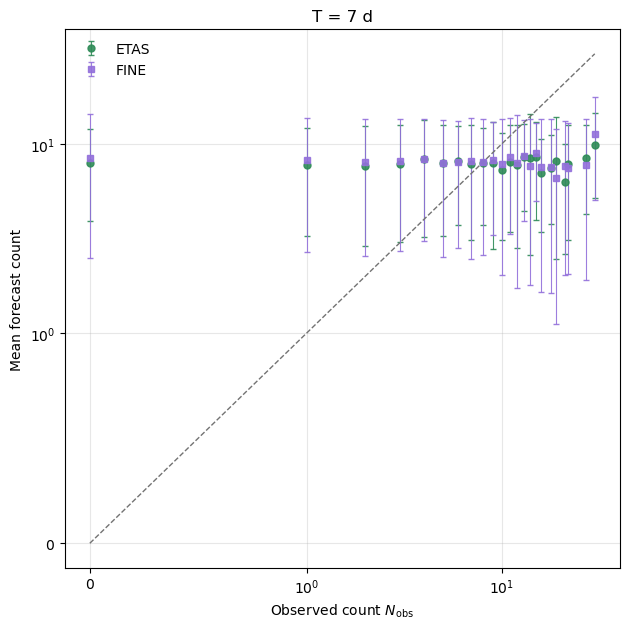

In [24]:
origin = pd.Timestamp("1970-01-01")
window_bounds = {
    int(row.step_index): (
        float((row.forecast_start - origin) / pd.Timedelta("1D")),
        float((row.forecast_end - origin) / pd.Timedelta("1D")),
    )
    for row in store.windows().itertuples(index=False)
}
catalog_counts = []
for method in METHODS:
    seed_days = [
        store.event_frame(method, seed)["time_days"].to_numpy(dtype=float)
        for seed in SEEDS
    ]
    method_rows = window_tests.loc[window_tests["method"] == method]
    for row in method_rows.itertuples(index=False):
        start, end = window_bounds[int(row.step_index)]
        n_for = np.array([
            np.count_nonzero((days > start) & (days <= end))
            for days in seed_days
        ], dtype=float)
        catalog_counts.append({
            "method": method,
            "n_observed": int(round(float(row.n_observed))),
            "n_for": n_for,
        })

summary_rows = []
for (method, n_obs), group in pd.DataFrame(catalog_counts).groupby(
    ["method", "n_observed"], sort=False,
):
    pooled = np.concatenate(group["n_for"].to_list())
    summary_rows.append({
        "method": method,
        "n_observed": int(n_obs),
        "n_mean": float(np.mean(pooled)),
        "n_std": float(np.std(pooled, ddof=1)) if pooled.size >= 2 else 0.0,
    })
count_compare = pd.DataFrame(summary_rows)

fig, ax = plt.subplots(figsize=(6.4, 6.4))
markers = {"etas": "o", "FINE": "s"}
for method, group in count_compare.groupby("method", sort=False):
    ax.errorbar(
        group["n_observed"], group["n_mean"], yerr=group["n_std"],
        fmt=markers.get(method, "o"), ms=5, lw=0.8, capsize=2, elinewidth=0.8,
        color=METHOD_COLORS.get(method),
        label=METHOD_LABELS.get(method, method),
        alpha=0.9,
    )
hi = float(np.nanmax(np.column_stack([
    count_compare["n_observed"],
    count_compare["n_mean"] + count_compare["n_std"],
])))
hi = max(hi, 1.0)
ax.plot([0.0, hi], [0.0, hi], ls="--", color="0.45", lw=1.0)
ax.set_xscale("symlog", linthresh=1)
ax.set_yscale("symlog", linthresh=1)
ax.set_xlabel(r"Observed count $N_{\mathrm{obs}}$")
ax.set_ylabel(r"Mean forecast count")
ax.set_title(f"T = {HORIZON_DAYS:g} d")
ax.legend(frameon=False)
ax.grid(True, which="both", alpha=0.3)
fig.tight_layout()
show_fig(fig)


## Walk-forward path

Same two panels as the main rolling notebook. Count error is the mean catalog size minus the observed count, divided by the observed count. The magnitude panel is the Wasserstein distance between the forecast magnitudes and the earthquakes in that window.


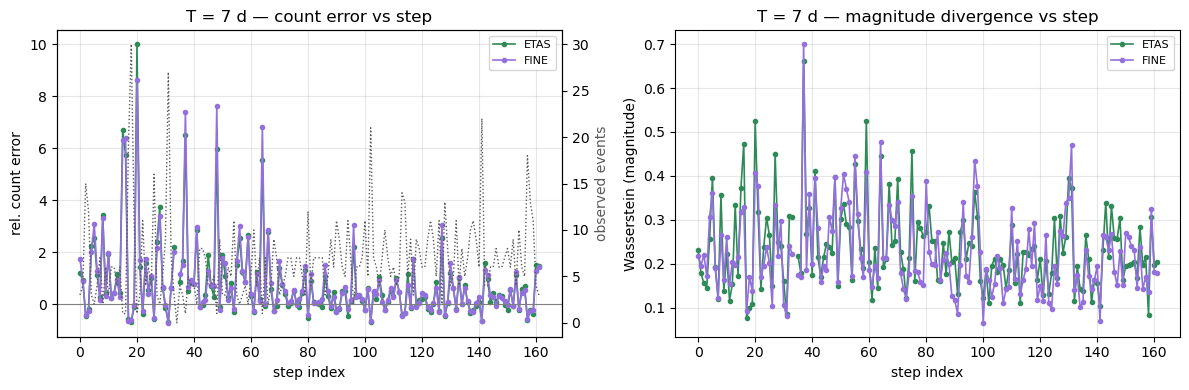

In [25]:
import etas.utility_functions as utility_functions
from scipy import stats as scipy_stats

cfg = json.loads(ROLLING_CONFIG_PATH.read_text(encoding="utf-8"))
origin = pd.to_datetime(cfg["timewindow_end"])
origin_days = float((origin - pd.Timestamp("1970-01-01")) / pd.Timedelta("1D"))
windows = store.windows()
observed = store.observed_frame()
observed_days = observed["time_days"].to_numpy(dtype=float) - origin_days
seed_frames = {
    method: {seed: store.event_frame(method, seed) for seed in SEEDS}
    for method in METHODS
}

path_rows = []
for window in windows.itertuples(index=False):
    start_days = float((window.forecast_start - origin) / pd.Timedelta("1D"))
    end_days = float((window.forecast_end - origin) / pd.Timedelta("1D"))
    obs_mag = observed.loc[
        (observed_days > start_days) & (observed_days <= end_days), "magnitude"
    ].to_numpy(dtype=float)
    row = {
        "step_index": int(window.step_index),
        "observed_n_events": int(obs_mag.size),
    }
    for method in METHODS:
        counts = []
        magnitudes = []
        for frame in seed_frames[method].values():
            dt = frame["time_days"].to_numpy(dtype=float) - origin_days
            chosen = frame.loc[(dt > start_days) & (dt <= end_days), "magnitude"].to_numpy(dtype=float)
            counts.append(chosen.size)
            if chosen.size:
                magnitudes.append(chosen)
        mean_count = float(np.mean(counts)) if counts else 0.0
        n_obs = int(obs_mag.size)
        if n_obs > 0:
            row[f"{method}_rel_count_error"] = (mean_count - n_obs) / n_obs
        else:
            row[f"{method}_rel_count_error"] = 0.0 if mean_count == 0.0 else np.inf
        if n_obs > 0 and magnitudes:
            row[f"{method}_wasserstein_mag"] = float(scipy_stats.wasserstein_distance(
                np.concatenate(magnitudes), obs_mag,
            ))
        else:
            row[f"{method}_wasserstein_mag"] = np.nan
    path_rows.append(row)
path_metrics = pd.DataFrame(path_rows).sort_values("step_index")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
x = path_metrics["step_index"].to_numpy()
for method in METHODS:
    color = METHOD_COLORS.get(method)
    label = METHOD_LABELS.get(method, method)
    axes[0].plot(x, path_metrics[f"{method}_rel_count_error"], marker="o", ms=3, lw=1.2, label=label, color=color)
    axes[1].plot(x, path_metrics[f"{method}_wasserstein_mag"], marker="o", ms=3, lw=1.2, label=label, color=color)
ax0_t = axes[0].twinx()
ax0_t.plot(x, path_metrics["observed_n_events"], color="0.35", ls=":", lw=1.0)
ax0_t.set_ylabel("observed events", color="0.35")
axes[0].axhline(0, color="0.5", lw=0.8)
axes[0].set_xlabel("step index")
axes[0].set_ylabel("rel. count error")
axes[0].set_title(f"T = {HORIZON_DAYS:g} d — count error vs step")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)
axes[1].set_xlabel("step index")
axes[1].set_ylabel("Wasserstein (magnitude)")
axes[1].set_title(f"T = {HORIZON_DAYS:g} d — magnitude divergence vs step")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)
fig.tight_layout()
show_fig(fig)


## Concatenated forecast trajectory

Cumulative counts are an interactive Plotly figure: drag to zoom, double-click to reset. Training is the dashed line before day 0. The test catalog and each seed start again at zero on day 0. The 30-day rate panel underneath is static.


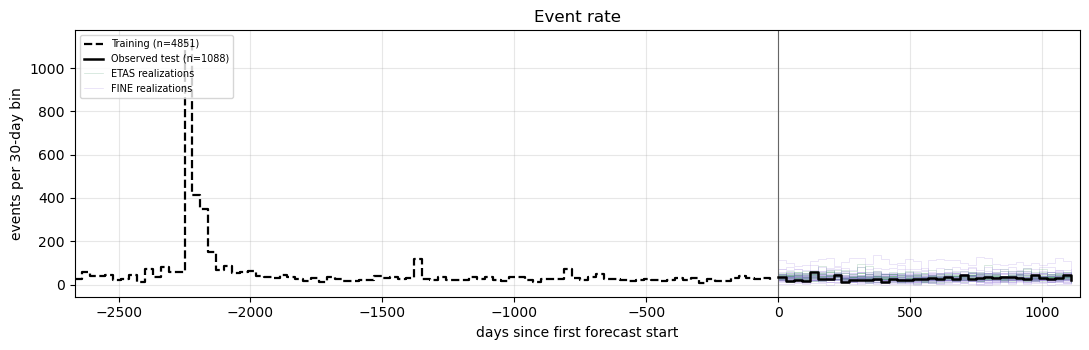

In [26]:
import plotly.graph_objects as go
from IPython.display import HTML

train = store.training_frame()
train_days = train["time_days"].to_numpy(dtype=float) - origin_days
forecast_end_days = float((windows["forecast_end"].max() - origin) / pd.Timedelta("1D"))
train_span = float(-np.min(train_days)) if train_days.size else 0.0
t_grid = np.linspace(-train_span, forecast_end_days, max(400, int(forecast_end_days) + 80))
forecast_mask = t_grid >= 0.0
train_mask = t_grid <= 0.0

negative_edges = -np.arange(0.0, train_span + 30.0, 30.0)[::-1]
negative_edges = negative_edges[negative_edges >= -train_span]
if negative_edges.size == 0 or negative_edges[0] > -train_span:
    negative_edges = np.insert(negative_edges, 0, -train_span)
positive_edges = np.arange(0.0, forecast_end_days + 30.0, 30.0)
if positive_edges.size == 0 or positive_edges[-1] < forecast_end_days:
    positive_edges = np.append(positive_edges, forecast_end_days)
bin_edges = np.unique(np.concatenate((negative_edges, positive_edges)))
pos = bin_edges[:-1] >= 0.0
neg = bin_edges[1:] <= 0.0


def _days(frame: pd.DataFrame) -> np.ndarray:
    return frame["time_days"].to_numpy(dtype=float) - origin_days


date_labels = (origin + pd.to_timedelta(t_grid, unit="D")).strftime("%Y-%m-%d %H:%M")
train_dates = date_labels[train_mask]
forecast_dates = date_labels[forecast_mask]
hover_coords = "t=%{x:.1f} d<br>date=%{customdata}<br>N=%{y:.0f}<extra></extra>"

fig_cum = go.Figure()
if train_days.size:
    train_curve = utility_functions.cumulative_on_grid(train_days, t_grid)
    fig_cum.add_trace(go.Scatter(
        x=t_grid[train_mask], y=train_curve[train_mask],
        mode="lines", name=f"Training (n={train_days.size})",
        line=dict(color="black", width=2, dash="dash"),
        customdata=train_dates,
        hovertemplate=f"Training<br>{hover_coords}",
    ))
if observed_days.size:
    obs_curve = utility_functions.cumulative_on_grid(observed_days, t_grid)
    fig_cum.add_trace(go.Scatter(
        x=t_grid[forecast_mask], y=obs_curve[forecast_mask],
        mode="lines", name=f"Observed test (n={observed_days.size})",
        line=dict(color="black", width=2.4),
        customdata=forecast_dates,
        hovertemplate=f"Observed test<br>{hover_coords}",
    ))

for method in METHODS:
    color = METHOD_COLORS.get(method, "gray")
    label = METHOD_LABELS.get(method, method)
    curves = [
        utility_functions.cumulative_on_grid(_days(frame), t_grid)
        for frame in seed_frames[method].values()
    ]
    stacked = np.vstack(curves)
    for index, (seed, curve) in enumerate(zip(SEEDS, stacked)):
        fig_cum.add_trace(go.Scatter(
            x=t_grid[forecast_mask], y=curve[forecast_mask],
            mode="lines",
            name=f"{label} realizations",
            legendgroup=f"{method}-real",
            showlegend=(index == 0),
            line=dict(color=color, width=0.8),
            opacity=0.45,
            customdata=forecast_dates,
            hovertemplate=f"{label} seed {seed}<br>{hover_coords}",
        ))
    fig_cum.add_trace(go.Scatter(
        x=t_grid[forecast_mask], y=np.mean(stacked, axis=0)[forecast_mask],
        mode="lines", name=f"{label} mean", legendgroup=method,
        line=dict(color=color, width=2.6),
        customdata=forecast_dates,
        hovertemplate=f"{label} mean<br>{hover_coords}",
    ))
    fig_cum.add_trace(go.Scatter(
        x=t_grid[forecast_mask], y=np.median(stacked, axis=0)[forecast_mask],
        mode="lines", name=f"{label} median", legendgroup=method,
        line=dict(color=color, width=2, dash="dot"),
        customdata=forecast_dates,
        hovertemplate=f"{label} median<br>{hover_coords}",
    ))

shapes = [dict(
    type="line", x0=0.0, x1=0.0, y0=0, y1=1, yref="paper",
    line=dict(color="gray", width=1, dash="dot"),
)]
for boundary in windows["forecast_start"].iloc[1:]:
    x_b = float((boundary - origin) / pd.Timedelta("1D"))
    shapes.append(dict(
        type="line", x0=x_b, x1=x_b, y0=0, y1=1, yref="paper",
        line=dict(color="rgba(160,160,160,0.45)", width=0.6),
    ))
fig_cum.update_layout(
    title=f"Cumulative event count — T = {HORIZON_DAYS:g} d walk-forward",
    xaxis_title="days since first forecast start",
    yaxis_title="cumulative number of events N(t)",
    height=520,
    template="plotly_white",
    legend=dict(x=0.01, y=0.99, xanchor="left", yanchor="top"),
    shapes=shapes,
    margin=dict(t=60),
)
fig_cum.update_xaxes(range=[-train_span, forecast_end_days * 1.01])
display(HTML(fig_cum.to_html(include_plotlyjs="cdn", full_html=False)))

fig_rate, ax_rate = plt.subplots(figsize=(11, 3.6))
if train_days.size:
    train_bins = utility_functions.events_per_time_bin(train_days, bin_edges)
    ax_rate.step(
        bin_edges[:-1][neg], train_bins[neg], where="post",
        color="black", lw=1.6, ls="--", label=f"Training (n={train_days.size})", zorder=3,
    )
if observed_days.size:
    obs_bins = utility_functions.events_per_time_bin(observed_days, bin_edges)
    ax_rate.step(
        bin_edges[:-1][pos], obs_bins[pos], where="post",
        color="black", lw=1.8, label=f"Observed test (n={observed_days.size})", zorder=4,
    )
for method in METHODS:
    color = METHOD_COLORS.get(method)
    label = METHOD_LABELS.get(method, method)
    for index, frame in enumerate(seed_frames[method].values()):
        counts = utility_functions.events_per_time_bin(_days(frame), bin_edges)
        ax_rate.step(
            bin_edges[:-1][pos], counts[pos], where="post",
            color=color, lw=0.5, alpha=0.25,
            label=f"{label} realizations" if index == 0 else None,
        )
ax_rate.axvline(0.0, color="0.4", lw=0.8)
ax_rate.set_xlim(-train_span, forecast_end_days * 1.01)
ax_rate.set_xlabel("days since first forecast start")
ax_rate.set_ylabel("events per 30-day bin")
ax_rate.set_title("Event rate")
ax_rate.legend(fontsize=7, loc="upper left")
ax_rate.grid(True, alpha=0.3)
fig_rate.tight_layout()
show_fig(fig_rate)


## Background probability μ / λ(t)

For each forecast event, the soft probability that it is background is the instantaneous background share of the ETAS intensity at its location and time: \(P_0 = \mu / \lambda(x,y,t)\), with \(\lambda\) built from the fitted parameters of that rolling window and the history available at the window start (observed catalog up to the forecast start), plus earlier simulated events in the same window. Pale lines are individual seeds; the solid line is the seed-mean step function on the common time grid (same visual language as the cumulative count figure). Observed test events use the same formula with observed-only history and are drawn in black. The next code cell plots only the observed series and each method's seed-mean, smoothed with a centered rolling window of `P0_SMOOTH_DAYS` (edit that constant and re-run that cell).


In [27]:
import etas.rate_simulation as rate_simulation
import etas.utility_functions as utility_functions

# --- helpers -----------------------------------------------------------------

def _params_from_fit(fit: dict) -> dict:
    params = utility_functions.expand_theta_log10(dict(fit["theta"]))
    params["m_c"] = float(fit["mc"])
    return params


def _instantaneous_rates(
    lat: np.ndarray,
    lon: np.ndarray,
    t_days: np.ndarray,
    hist_lat: np.ndarray,
    hist_lon: np.ndarray,
    hist_mag: np.ndarray,
    hist_t: np.ndarray,
    params: dict,
    *,
    batch_size: int = 64,
) -> np.ndarray:
    """ETAS intensity density λ(x, y, t) at each target event."""
    lat = np.asarray(lat, dtype=np.float64).ravel()
    lon = np.asarray(lon, dtype=np.float64).ravel()
    t_days = np.asarray(t_days, dtype=np.float64).ravel()
    n = lat.size
    rates = np.full(n, float(params["mu"]), dtype=np.float64)
    if n == 0 or hist_t.size == 0:
        return rates

    hlat = np.radians(np.asarray(hist_lat, dtype=np.float64).ravel())
    hlon = np.radians(np.asarray(hist_lon, dtype=np.float64).ravel())
    hm = np.asarray(hist_mag, dtype=np.float64).ravel()
    ht = np.asarray(hist_t, dtype=np.float64).ravel()
    tlat = np.radians(lat)
    tlon = np.radians(lon)

    k0 = float(params["k0"])
    a = float(params["a"])
    d = float(params["d"])
    gamma = float(params["gamma"])
    rho = float(params["rho"])
    c = float(params["c"])
    tau = float(params["tau"])
    omega = float(params["omega"])
    mc = float(params["m_c"])
    mu = float(params["mu"])
    mag_gap = hm - mc
    amplitude = k0 * np.exp(a * mag_gap)
    core = d * np.exp(gamma * mag_gap)

    for start in range(0, n, int(batch_size)):
        stop = min(start + int(batch_size), n)
        dt = t_days[start:stop, None] - ht[None, :]
        past = dt > 0.0
        if not np.any(past):
            rates[start:stop] = mu
            continue
        dist_sq = np.square(utility_functions.haversine_km(
            hlat[None, :], tlat[start:stop, None],
            hlon[None, :], tlon[start:stop, None],
        ))
        spatial = amplitude[None, :] / (dist_sq + core[None, :]) ** (1.0 + rho)
        g_vals = np.exp(-dt / tau) / (dt + c) ** (1.0 + omega)
        triggered = np.sum(np.where(past, spatial * g_vals, 0.0), axis=1)
        rates[start:stop] = mu + triggered
    return rates


def _background_probability(rates: np.ndarray, mu: float) -> np.ndarray:
    rates = np.asarray(rates, dtype=np.float64)
    out = np.full(rates.shape, np.nan, dtype=np.float64)
    ok = np.isfinite(rates) & (rates > 0.0)
    out[ok] = float(mu) / rates[ok]
    return np.clip(out, 0.0, 1.0)


def _step_on_grid(event_t: np.ndarray, event_p: np.ndarray, grid: np.ndarray) -> np.ndarray:
    """Forward-fill each event's P0 onto ``grid`` (NaN before the first event)."""
    out = np.full(grid.shape, np.nan, dtype=np.float64)
    if event_t.size == 0:
        return out
    order = np.argsort(event_t)
    event_t = event_t[order]
    event_p = event_p[order]
    idx = np.searchsorted(event_t, grid, side="right") - 1
    valid = idx >= 0
    out[valid] = event_p[idx[valid]]
    return out


def _window_fit_map(horizon_dir: Path) -> dict[int, dict]:
    """Map step_index → linearized ETAS params for that window."""
    out: dict[int, dict] = {}
    for step_index, step_dir in discover_step_dirs(horizon_dir):
        fit = rolling_analysis._theta_from_step_dir(step_dir)
        if fit is None:
            continue
        out[int(step_index)] = _params_from_fit(fit)
    return out


def _events_in_window(
    frame: pd.DataFrame,
    start_days: float,
    end_days: float,
    origin_days: float,
) -> pd.DataFrame:
    t = frame["time_days"].to_numpy(dtype=float) - origin_days
    chosen = frame.loc[(t > start_days) & (t <= end_days)].copy()
    chosen["t_rel"] = chosen["time_days"].to_numpy(dtype=float) - origin_days
    return chosen.sort_values("time_days")


# Observed history used as the base for every window (training + test).
observed_history = pd.concat(
    [store.training_frame(), store.observed_frame()],
    ignore_index=True,
).sort_values("time_days")
observed_history_t = observed_history["time_days"].to_numpy(dtype=float)
window_params = _window_fit_map(horizon_dir)
if not window_params:
    raise RuntimeError("No inversion parameters found under the horizon steps")

# Fallback params when a step is missing a fit file.
_default_params = next(iter(window_params.values()))


def _p0_for_frame(frame: pd.DataFrame, method_seeds: bool = True) -> tuple[np.ndarray, np.ndarray]:
    """Return (t_rel_days, P0) for every forecast event in ``frame`` across windows."""
    times: list[float] = []
    probs: list[float] = []
    for window in windows.itertuples(index=False):
        start_days = float((window.forecast_start - origin) / pd.Timedelta("1D"))
        end_days = float((window.forecast_end - origin) / pd.Timedelta("1D"))
        start_abs = float((window.forecast_start - pd.Timestamp("1970-01-01")) / pd.Timedelta("1D"))
        params = window_params.get(int(window.step_index), _default_params)
        mu = float(params["mu"])
        base = observed_history.loc[observed_history_t <= start_abs]
        hist_lat = base["latitude"].to_numpy(dtype=float)
        hist_lon = base["longitude"].to_numpy(dtype=float)
        hist_mag = base["magnitude"].to_numpy(dtype=float)
        hist_t = base["time_days"].to_numpy(dtype=float)
        chosen = _events_in_window(frame, start_days, end_days, origin_days)
        if chosen.empty:
            continue
        # Grow history with earlier events in this same window (cascading).
        for row in chosen.itertuples(index=False):
            rates = _instantaneous_rates(
                np.array([row.latitude]), np.array([row.longitude]), np.array([row.time_days]),
                hist_lat, hist_lon, hist_mag, hist_t, params,
            )
            times.append(float(row.t_rel))
            probs.append(float(_background_probability(rates, mu)[0]))
            hist_lat = np.append(hist_lat, row.latitude)
            hist_lon = np.append(hist_lon, row.longitude)
            hist_mag = np.append(hist_mag, row.magnitude)
            hist_t = np.append(hist_t, row.time_days)
    return np.asarray(times, dtype=float), np.asarray(probs, dtype=float)


# Observed test events (black reference).
obs_times: list[float] = []
obs_probs: list[float] = []
for window in windows.itertuples(index=False):
    start_days = float((window.forecast_start - origin) / pd.Timedelta("1D"))
    end_days = float((window.forecast_end - origin) / pd.Timedelta("1D"))
    start_abs = float((window.forecast_start - pd.Timestamp("1970-01-01")) / pd.Timedelta("1D"))
    params = window_params.get(int(window.step_index), _default_params)
    mu = float(params["mu"])
    base = observed_history.loc[observed_history_t <= start_abs]
    chosen = _events_in_window(observed, start_days, end_days, origin_days)
    if chosen.empty:
        continue
    hist_lat = base["latitude"].to_numpy(dtype=float)
    hist_lon = base["longitude"].to_numpy(dtype=float)
    hist_mag = base["magnitude"].to_numpy(dtype=float)
    hist_t = base["time_days"].to_numpy(dtype=float)
    for row in chosen.itertuples(index=False):
        rates = _instantaneous_rates(
            np.array([row.latitude]), np.array([row.longitude]), np.array([row.time_days]),
            hist_lat, hist_lon, hist_mag, hist_t, params,
        )
        obs_times.append(float(row.t_rel))
        obs_probs.append(float(_background_probability(rates, mu)[0]))
        hist_lat = np.append(hist_lat, row.latitude)
        hist_lon = np.append(hist_lon, row.longitude)
        hist_mag = np.append(hist_mag, row.magnitude)
        hist_t = np.append(hist_t, row.time_days)
obs_times_arr = np.asarray(obs_times, dtype=float)
obs_probs_arr = np.asarray(obs_probs, dtype=float)

p0_by_method: dict[str, dict[int, tuple[np.ndarray, np.ndarray]]] = {}
for method in METHODS:
    p0_by_method[method] = {}
    for seed in SEEDS:
        p0_by_method[method][seed] = _p0_for_frame(seed_frames[method][seed])

# Shared forecast time grid (reuse cumulative figure span).
t_grid_bg = t_grid[forecast_mask]
date_labels_bg = (origin + pd.to_timedelta(t_grid_bg, unit="D")).strftime("%Y-%m-%d %H:%M")
hover_bg = "t=%{x:.1f} d<br>date=%{customdata}<br>P0=%{y:.3f}<extra></extra>"

fig_bg = go.Figure()
if obs_times_arr.size:
    order = np.argsort(obs_times_arr)
    fig_bg.add_trace(go.Scatter(
        x=obs_times_arr[order], y=obs_probs_arr[order],
        mode="lines+markers",
        name=f"Observed test (n={obs_times_arr.size})",
        line=dict(color="black", width=2.4),
        marker=dict(size=4, color="black"),
        customdata=(origin + pd.to_timedelta(obs_times_arr[order], unit="D")).strftime("%Y-%m-%d %H:%M"),
        hovertemplate=f"Observed test<br>{hover_bg}",
    ))

mean_curves_bg: dict[str, np.ndarray] = {}
for method in METHODS:
    color = METHOD_COLORS.get(method, "gray")
    label = METHOD_LABELS.get(method, method)
    stepped = []
    for index, seed in enumerate(SEEDS):
        times_s, probs_s = p0_by_method[method][seed]
        if times_s.size == 0:
            stepped.append(np.full(t_grid_bg.shape, np.nan))
            continue
        order = np.argsort(times_s)
        times_s, probs_s = times_s[order], probs_s[order]
        fig_bg.add_trace(go.Scatter(
            x=times_s, y=probs_s,
            mode="lines+markers",
            name=f"{label} realizations",
            legendgroup=f"{method}-real-bg",
            showlegend=(index == 0),
            line=dict(color=color, width=0.8),
            marker=dict(size=3, color=color),
            opacity=0.45,
            customdata=(origin + pd.to_timedelta(times_s, unit="D")).strftime("%Y-%m-%d %H:%M"),
            hovertemplate=f"{label} seed {seed}<br>{hover_bg}",
        ))
        stepped.append(_step_on_grid(times_s, probs_s, t_grid_bg))
    stacked = np.vstack(stepped)
    with np.errstate(all="ignore"):
        mean_curve = np.nanmean(stacked, axis=0)
        median_curve = np.nanmedian(stacked, axis=0)
    mean_curves_bg[method] = mean_curve
    fig_bg.add_trace(go.Scatter(
        x=t_grid_bg, y=mean_curve,
        mode="lines", name=f"{label} mean", legendgroup=f"{method}-bg",
        line=dict(color=color, width=2.6),
        customdata=date_labels_bg,
        hovertemplate=f"{label} mean<br>{hover_bg}",
    ))
    fig_bg.add_trace(go.Scatter(
        x=t_grid_bg, y=median_curve,
        mode="lines", name=f"{label} median", legendgroup=f"{method}-bg",
        line=dict(color=color, width=2, dash="dot"),
        customdata=date_labels_bg,
        hovertemplate=f"{label} median<br>{hover_bg}",
    ))

shapes_bg = [dict(
    type="line", x0=0.0, x1=0.0, y0=0, y1=1, yref="paper",
    line=dict(color="gray", width=1, dash="dot"),
)]
for boundary in windows["forecast_start"].iloc[1:]:
    x_b = float((boundary - origin) / pd.Timedelta("1D"))
    shapes_bg.append(dict(
        type="line", x0=x_b, x1=x_b, y0=0, y1=1, yref="paper",
        line=dict(color="rgba(160,160,160,0.45)", width=0.6),
    ))
fig_bg.update_layout(
    title=f"Background probability μ/λ — T = {HORIZON_DAYS:g} d walk-forward",
    xaxis_title="days since first forecast start",
    yaxis_title="P(background) = μ / λ(x, y, t)",
    yaxis=dict(range=[-0.02, 1.05]),
    height=520,
    template="plotly_white",
    legend=dict(x=0.01, y=0.99, xanchor="left", yanchor="top"),
    shapes=shapes_bg,
    margin=dict(t=60),
)
fig_bg.update_xaxes(range=[0.0, forecast_end_days * 1.01])
display(HTML(fig_bg.to_html(include_plotlyjs="cdn", full_html=False)))

# Summary: mean P0 over events
summary_rows = []
if obs_probs_arr.size:
    summary_rows.append({
        "catalog": "observed",
        "n_events": int(obs_probs_arr.size),
        "mean_P0": float(np.mean(obs_probs_arr)),
        "median_P0": float(np.median(obs_probs_arr)),
    })
for method in METHODS:
    for seed in SEEDS:
        _t, _p = p0_by_method[method][seed]
        if _p.size == 0:
            continue
        summary_rows.append({
            "catalog": f"{METHOD_LABELS.get(method, method)} seed {seed}",
            "n_events": int(_p.size),
            "mean_P0": float(np.mean(_p)),
            "median_P0": float(np.median(_p)),
        })
display(pd.DataFrame(summary_rows))


,catalog,n_events,mean_P0,median_P0
0,observed,1088,0.146923,0.004889
1,ETAS seed 10,1179,0.156748,0.000885
2,ETAS seed 11,1110,0.047787,0.000358
3,ETAS seed 12,975,0.044953,0.000214
4,ETAS seed 13,1394,0.156630,0.000313
...,...,...,...,...
56,FINE seed 35,1807,0.088164,0.000724
57,FINE seed 36,1433,0.262937,0.008273
58,FINE seed 37,724,0.446234,0.086535
59,FINE seed 38,616,0.070786,0.001460


In [28]:
# Smoothed background probability (re-run after changing P0_SMOOTH_DAYS).
# Requires the previous cell: obs_times_arr, obs_probs_arr, mean_curves_bg,
# t_grid_bg, shapes_bg, forecast_end_days.
P0_SMOOTH_DAYS = int(HORIZON_DAYS*4)


def _smooth_p0_on_days(
    times_days: np.ndarray,
    values: np.ndarray,
    window_days: float,
) -> pd.Series:
    """Centered rolling mean over ``window_days`` calendar days."""
    times_days = np.asarray(times_days, dtype=float)
    values = np.asarray(values, dtype=float)
    ok = np.isfinite(times_days) & np.isfinite(values)
    if not np.any(ok):
        return pd.Series(dtype=float)
    stamps = origin + pd.to_timedelta(times_days[ok], unit="D")
    series = pd.Series(values[ok], index=pd.to_datetime(stamps)).sort_index()
    series = series[~series.index.duplicated(keep="last")]
    return series.rolling(
        pd.Timedelta(days=float(window_days)), center=True, min_periods=1,
    ).mean()


if "obs_times_arr" not in globals() or "mean_curves_bg" not in globals():
    raise RuntimeError("Run the previous background-probability cell first.")

_hover_smooth = (
    "t=%{x:.1f} d<br>date=%{customdata}<br>"
    f"P0=%{{y:.3f}} ({P0_SMOOTH_DAYS:g}-day smooth)<extra></extra>"
)
fig_bg_smooth = go.Figure()
if obs_times_arr.size:
    obs_smooth = _smooth_p0_on_days(obs_times_arr, obs_probs_arr, P0_SMOOTH_DAYS)
    if len(obs_smooth):
        obs_t = (obs_smooth.index - origin) / pd.Timedelta("1D")
        fig_bg_smooth.add_trace(go.Scatter(
            x=obs_t.to_numpy(dtype=float),
            y=obs_smooth.to_numpy(dtype=float),
            mode="lines",
            name=f"Observed ({P0_SMOOTH_DAYS:g}-day smooth)",
            line=dict(color="black", width=2.6),
            customdata=obs_smooth.index.strftime("%Y-%m-%d %H:%M"),
            hovertemplate="Observed<br>" + _hover_smooth,
        ))

for method in METHODS:
    color = METHOD_COLORS.get(method, "gray")
    label = METHOD_LABELS.get(method, method)
    mean_curve = mean_curves_bg.get(method)
    if mean_curve is None or not np.any(np.isfinite(mean_curve)):
        continue
    method_smooth = _smooth_p0_on_days(t_grid_bg, mean_curve, P0_SMOOTH_DAYS)
    if not len(method_smooth):
        continue
    method_t = (method_smooth.index - origin) / pd.Timedelta("1D")
    fig_bg_smooth.add_trace(go.Scatter(
        x=method_t.to_numpy(dtype=float),
        y=method_smooth.to_numpy(dtype=float),
        mode="lines",
        name=f"{label} mean ({P0_SMOOTH_DAYS:g}-day smooth)",
        line=dict(color=color, width=2.6),
        customdata=method_smooth.index.strftime("%Y-%m-%d %H:%M"),
        hovertemplate=f"{label} mean<br>" + _hover_smooth,
    ))

fig_bg_smooth.update_layout(
    title=(
        f"Background probability μ/λ — {P0_SMOOTH_DAYS:g}-day smooth "
        f"(T = {HORIZON_DAYS:g} d)"
    ),
    xaxis_title="days since first forecast start",
    yaxis_title=f"P(background), {P0_SMOOTH_DAYS:g}-day rolling mean",
    yaxis=dict(range=[-0.02, 1.05]),
    height=420,
    template="plotly_white",
    legend=dict(x=0.01, y=0.99, xanchor="left", yanchor="top"),
    shapes=shapes_bg,
    margin=dict(t=60),
)
fig_bg_smooth.update_xaxes(range=[0.0, forecast_end_days * 1.01])
# plotly.js already loaded by the previous cell's figure
display(HTML(fig_bg_smooth.to_html(include_plotlyjs=False, full_html=False)))


## Interevent time and magnitude

Top row: one histogram per realization. Bottom row: all realizations pooled. The black step is the observed test catalog.


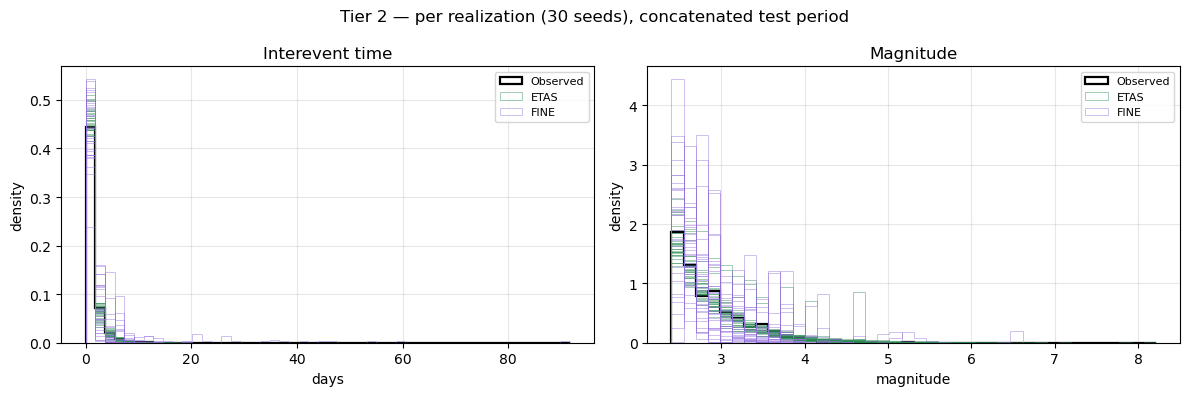

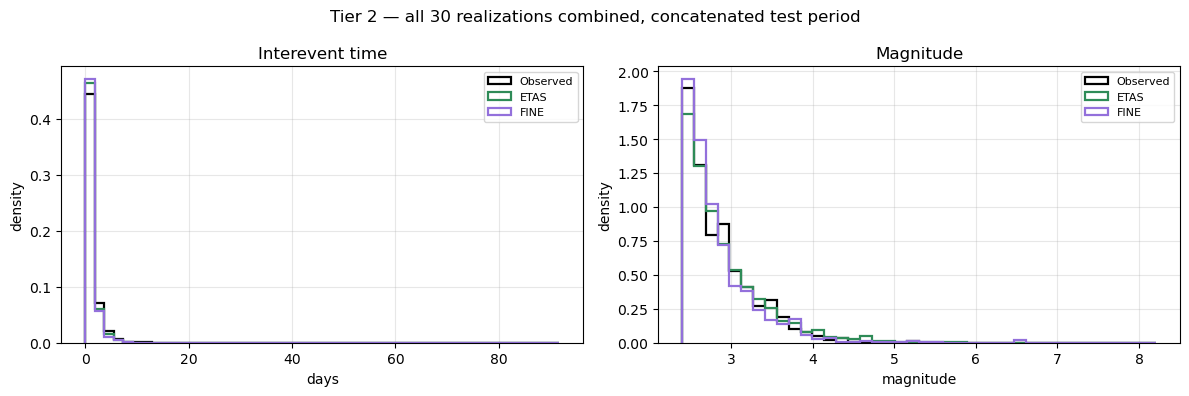

In [29]:
test_iet = utility_functions.interevent_times(observed_days)
test_mag = observed["magnitude"].to_numpy(dtype=float)
iet_by_method = {}
mag_by_method = {}
for method in METHODS:
    iets = []
    mags = []
    for frame in seed_frames[method].values():
        days = frame["time_days"].to_numpy(dtype=float) - origin_days
        iet = utility_functions.interevent_times(days)
        mag = frame["magnitude"].to_numpy(dtype=float)
        if iet.size:
            iets.append(iet)
        if mag.size:
            mags.append(mag)
    iet_by_method[method] = iets
    mag_by_method[method] = mags


def _edges(groups, observed_values, n_bins):
    parts = [observed_values, *[np.concatenate(group) for group in groups if group]]
    values = np.concatenate([part for part in parts if np.size(part)])
    return np.histogram_bin_edges(values[np.isfinite(values)], bins=n_bins)


iet_edges = _edges(iet_by_method.values(), test_iet, 50)
mag_edges = _edges(mag_by_method.values(), test_mag, 40)


def _hist_pair(pooled: bool, suptitle: str) -> None:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    pairs = (
        (axes[0], iet_by_method, test_iet, iet_edges, "Interevent time", "days"),
        (axes[1], mag_by_method, test_mag, mag_edges, "Magnitude", "magnitude"),
    )
    for ax, by_method, observed_values, edges, title, xlabel in pairs:
        if observed_values.size:
            ax.hist(
                observed_values, bins=edges, density=True, histtype="step",
                color="black", lw=1.6, label="Observed",
            )
        for method in METHODS:
            color = METHOD_COLORS.get(method)
            label = METHOD_LABELS.get(method, method)
            series = by_method[method]
            if not series:
                continue
            if pooled:
                ax.hist(
                    np.concatenate(series), bins=edges, density=True, histtype="step",
                    color=color, lw=1.6, label=label,
                )
            else:
                for index, values in enumerate(series):
                    ax.hist(
                        values, bins=edges, density=True, histtype="step",
                        color=color, lw=0.7, alpha=0.45, label=label if index == 0 else None,
                    )
        ax.set_title(title)
        ax.set_xlabel(xlabel)
        ax.set_ylabel("density")
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
    fig.suptitle(suptitle, fontsize=12)
    fig.tight_layout()
    show_fig(fig)


_hist_pair(False, f"Tier 2 — per realization ({len(SEEDS)} seeds), concatenated test period")
_hist_pair(True, f"Tier 2 — all {len(SEEDS)} realizations combined, concatenated test period")


## Spatial distribution

Same maps as the main rolling comparison, drawn from the cached event coordinates. The left column is one realization. The right column is the histogram of epicenters pooled over every seed. These are event locations, not the intensity.


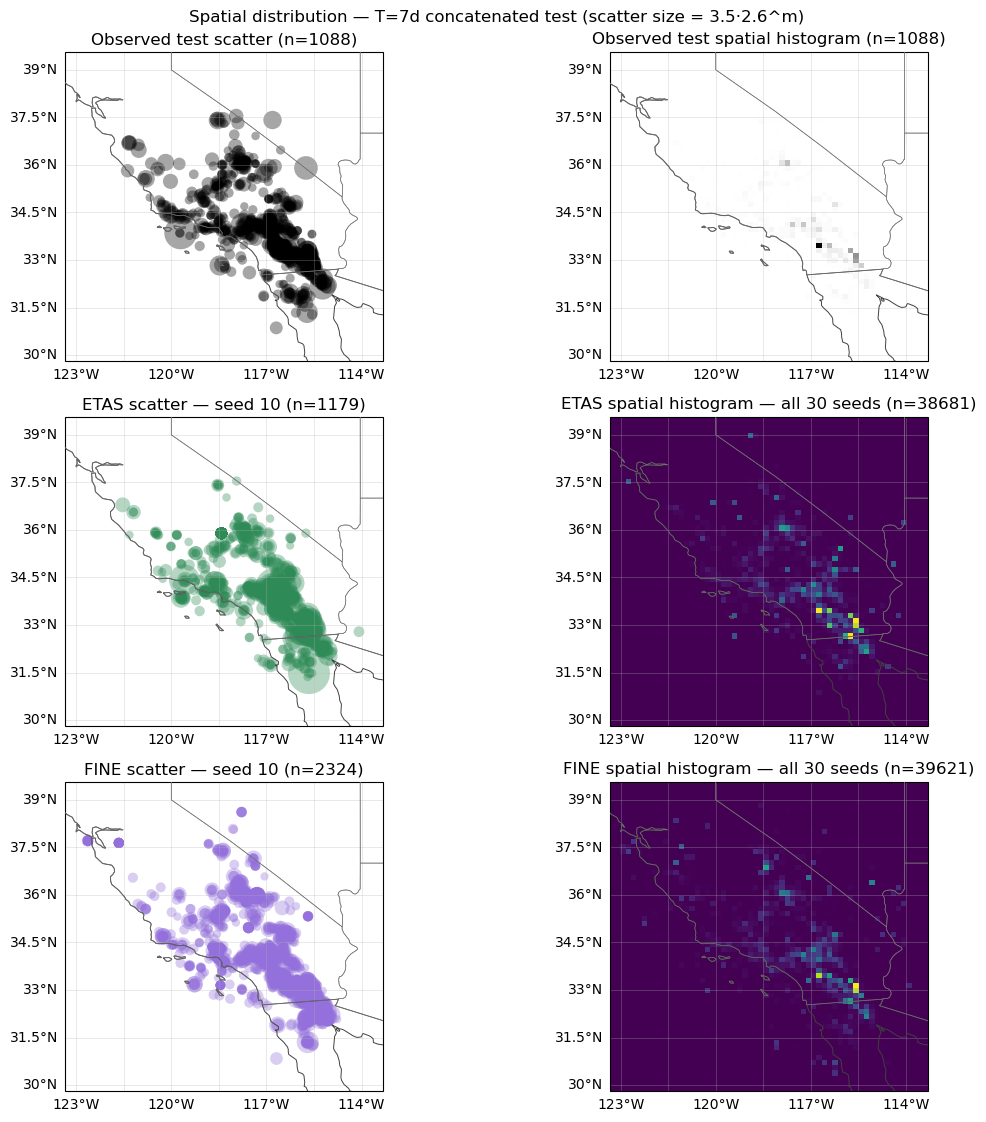

Map seed: **10**; pooled seeds: [10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39]

In [30]:
_SPATIAL_BINS = 60
_MAG_SIZE_BASE = 2.6
_MAG_SIZE_SCALE = 3.5

try:
    from cartopy import crs as ccrs
    import cartopy.feature as cfeature
    _HAS_CARTOPY = True
except ImportError as exc:
    _HAS_CARTOPY = False
    display(Markdown(f"_Cartopy unavailable ({exc}); spatial maps without borders._"))


def _scatter_sizes(mags: np.ndarray) -> np.ndarray:
    return _MAG_SIZE_SCALE * (_MAG_SIZE_BASE ** np.asarray(mags, dtype=float))


def _add_map_borders(ax) -> None:
    if not _HAS_CARTOPY:
        return
    ax.add_feature(cfeature.COASTLINE.with_scale("50m"), linewidth=0.7, edgecolor="0.25", zorder=3)
    ax.add_feature(cfeature.BORDERS.with_scale("50m"), linewidth=0.65, edgecolor="0.3", zorder=3)
    ax.add_feature(cfeature.STATES.with_scale("50m"), linewidth=0.45, edgecolor="0.45", zorder=3)


def _plot_spatial_hist(ax, lon, lat, *, cmap: str, hist_range) -> None:
    H, xedges, yedges = np.histogram2d(
        lon, lat, bins=_SPATIAL_BINS, range=hist_range, density=True,
    )
    if _HAS_CARTOPY:
        ax.pcolormesh(
            xedges, yedges, H.T, cmap=cmap, shading="auto",
            transform=ccrs.PlateCarree(), zorder=1,
        )
    else:
        ax.pcolormesh(xedges, yedges, H.T, cmap=cmap, shading="auto", zorder=1)


obs_lon, obs_lat, obs_mag = store.observed_events()
method_seed_xyz = {method: store.events(method, MAP_SEED) for method in METHODS}
method_pool_xy = {}
for method in METHODS:
    lon_p, lat_p, _mag_p = store.pooled_events(method, SEEDS)
    method_pool_xy[method] = (lon_p, lat_p)

all_lon = [obs_lon] + [method_pool_xy[method][0] for method in METHODS]
all_lat = [obs_lat] + [method_pool_xy[method][1] for method in METHODS]
lon_cat = np.concatenate([a for a in all_lon if a.size]) if any(a.size for a in all_lon) else np.array([])
lat_cat = np.concatenate([a for a in all_lat if a.size]) if any(a.size for a in all_lat) else np.array([])
if lon_cat.size == 0:
    display(Markdown("_No lon/lat coordinates in the cache._"))
else:
    lon_pad = 0.05 * max(float(lon_cat.max() - lon_cat.min()), 0.5)
    lat_pad = 0.05 * max(float(lat_cat.max() - lat_cat.min()), 0.5)
    lon_range = (float(lon_cat.min()) - lon_pad, float(lon_cat.max()) + lon_pad)
    lat_range = (float(lat_cat.min()) - lat_pad, float(lat_cat.max()) + lat_pad)
    hist_range = [lon_range, lat_range]
    scatter_kw = {"transform": ccrs.PlateCarree()} if _HAS_CARTOPY else {}
    subplot_kw = {"projection": ccrs.PlateCarree()} if _HAS_CARTOPY else {}
    fig, axes = plt.subplots(
        1 + len(METHODS), 2, figsize=(12, 3.8 * (1 + len(METHODS))),
        squeeze=False, subplot_kw=subplot_kw,
    )
    ax_s, ax_h = axes[0, 0], axes[0, 1]
    if obs_lon.size:
        ax_s.scatter(
            obs_lon, obs_lat, s=_scatter_sizes(obs_mag),
            c="black", alpha=0.35, linewidths=0, rasterized=True, zorder=2, **scatter_kw,
        )
        _plot_spatial_hist(ax_h, obs_lon, obs_lat, cmap="Greys", hist_range=hist_range)
    ax_s.set_title(f"Observed test scatter (n={obs_lon.size})")
    ax_h.set_title(f"Observed test spatial histogram (n={obs_lon.size})")
    for row_i, method in enumerate(METHODS, start=1):
        label = METHOD_LABELS.get(method, method)
        color = METHOD_COLORS.get(method) or f"C{row_i}"
        ax_s, ax_h = axes[row_i, 0], axes[row_i, 1]
        lon_s, lat_s, mag_s = method_seed_xyz[method]
        if lon_s.size:
            ax_s.scatter(
                lon_s, lat_s, s=_scatter_sizes(mag_s),
                c=color, alpha=0.35, linewidths=0, rasterized=True, zorder=2, **scatter_kw,
            )
        ax_s.set_title(f"{label} scatter — seed {MAP_SEED} (n={lon_s.size})")
        lon_p, lat_p = method_pool_xy[method]
        if lon_p.size:
            _plot_spatial_hist(ax_h, lon_p, lat_p, cmap="viridis", hist_range=hist_range)
        ax_h.set_title(f"{label} spatial histogram — all {len(SEEDS)} seeds (n={lon_p.size})")
    for ax in axes.ravel():
        _add_map_borders(ax)
        if _HAS_CARTOPY:
            ax.set_extent(
                [lon_range[0], lon_range[1], lat_range[0], lat_range[1]],
                crs=ccrs.PlateCarree(),
            )
            gl = ax.gridlines(draw_labels=True, linewidth=0.4, color="0.7", alpha=0.5)
            gl.top_labels = False
            gl.right_labels = False
        else:
            ax.set_xlim(*lon_range)
            ax.set_ylim(*lat_range)
            ax.set_aspect("equal", adjustable="box")
            ax.grid(True, alpha=0.25)
        ax.set_xlabel("longitude")
        ax.set_ylabel("latitude")
    fig.suptitle(
        f"Spatial distribution — T={HORIZON_DAYS:g}d concatenated test "
        f"(scatter size = {_MAG_SIZE_SCALE}·{_MAG_SIZE_BASE}^m)",
        fontsize=12,
    )
    fig.tight_layout()
    show_fig(fig)
    display(Markdown(f"Map seed: **{MAP_SEED}**; pooled seeds: {SEEDS}"))


## Rate maps

One figure, five panels, one log color scale. Observed is the catalog count in each cell. The mean is the seed-averaged intensity added across the forecast windows. The realization is that integral for `MAP_SEED`. The number under each title is the sum over all cells: events in the catalog, or expected events for a rate map.


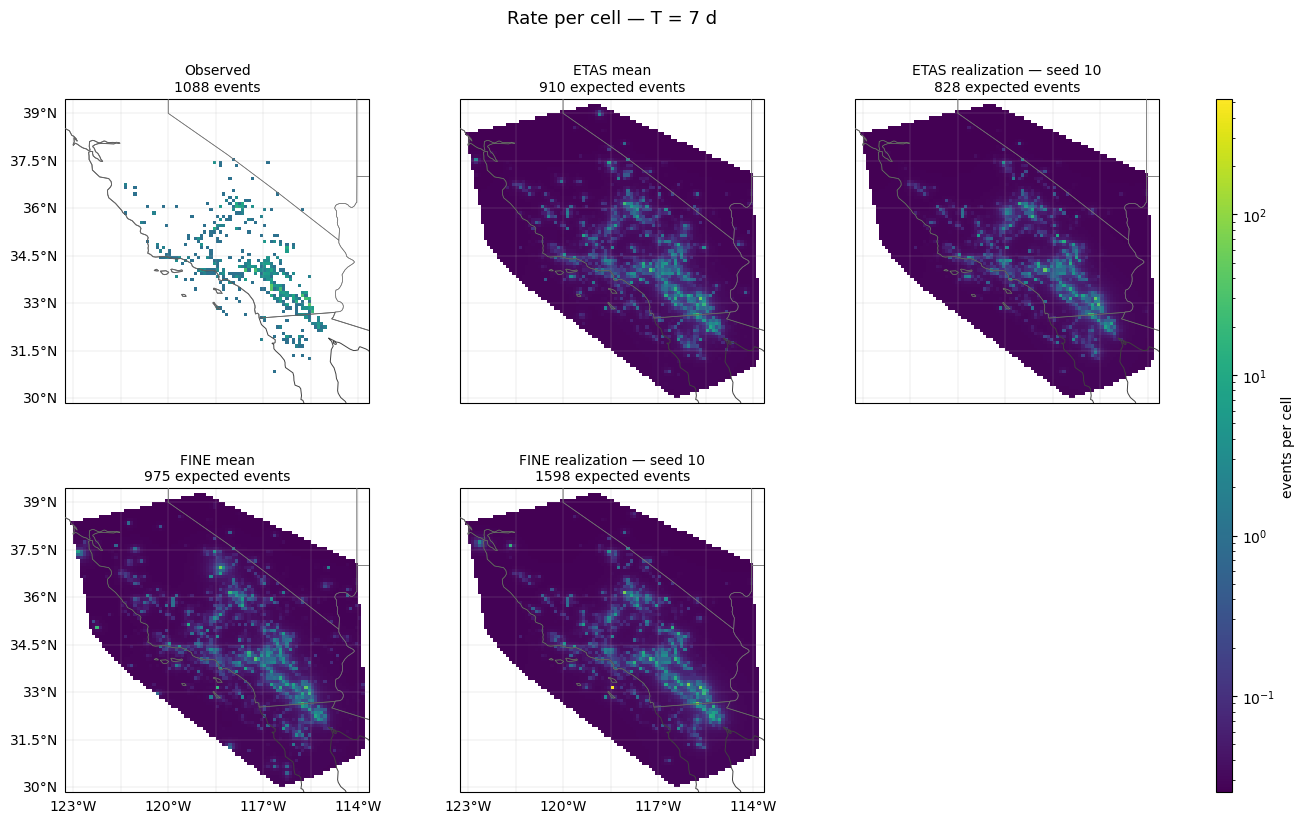

In [31]:
from matplotlib.colors import LogNorm

origins = store.origins
dh = store.dh
pad = 0.15
lon_edges = np.arange(origins[:, 0].min(), origins[:, 0].max() + dh * 1.01, dh)
lat_edges = np.arange(origins[:, 1].min(), origins[:, 1].max() + dh * 1.01, dh)
ix = np.rint((origins[:, 0] - lon_edges[0]) / dh).astype(int)
iy = np.rint((origins[:, 1] - lat_edges[0]) / dh).astype(int)
extent = [
    float(lon_edges[0]) - pad, float(lon_edges[-1]) + pad,
    float(lat_edges[0]) - pad, float(lat_edges[-1]) + pad,
]


def _cell_image(values: np.ndarray) -> np.ndarray:
    image = np.full((lat_edges.size - 1, lon_edges.size - 1), np.nan)
    image[iy, ix] = np.asarray(values, dtype=float)
    return np.ma.masked_where(~np.isfinite(image) | (image <= 0), image)


rate_panels = [
    ("Observed", store.observed_counts, "events"),
    (f"{METHOD_LABELS.get('etas', 'etas')} mean", store.mean_spatial("etas"), "expected events"),
    (f"{METHOD_LABELS.get('etas', 'etas')} realization — seed {MAP_SEED}", store.seed_spatial("etas", MAP_SEED), "expected events"),
    (f"{METHOD_LABELS.get('FINE', 'FINE')} mean", store.mean_spatial("FINE"), "expected events"),
    (f"{METHOD_LABELS.get('FINE', 'FINE')} realization — seed {MAP_SEED}", store.seed_spatial("FINE", MAP_SEED), "expected events"),
]
positive = np.concatenate([
    values[np.isfinite(values) & (values > 0)] for _title, values, _kind in rate_panels
])
shared = LogNorm(vmin=float(positive.min()), vmax=float(positive.max()))
fig = plt.figure(figsize=(15.5, 9.0))
grid = fig.add_gridspec(2, 4, width_ratios=[1, 1, 1, 0.045], wspace=0.08, hspace=0.28)
flat = []
for panel in range(5):
    row, col = divmod(panel, 3)
    if _HAS_CARTOPY:
        flat.append(fig.add_subplot(grid[row, col], projection=ccrs.PlateCarree()))
    else:
        flat.append(fig.add_subplot(grid[row, col]))
cax = fig.add_subplot(grid[:, 3])
mesh = None
for panel, (title, values, kind) in enumerate(rate_panels):
    ax = flat[panel]
    row, col = divmod(panel, 3)
    image = _cell_image(values)
    if _HAS_CARTOPY:
        mesh = ax.pcolormesh(
            lon_edges, lat_edges, image, cmap="viridis", norm=shared, shading="flat",
            transform=ccrs.PlateCarree(), zorder=1,
        )
        _add_map_borders(ax)
        ax.set_extent(extent, crs=ccrs.PlateCarree())
        gl = ax.gridlines(draw_labels=True, linewidth=0.3, color="0.7", alpha=0.5)
        gl.top_labels = False
        gl.right_labels = False
        gl.left_labels = col == 0
        gl.bottom_labels = row == 1
    else:
        mesh = ax.pcolormesh(lon_edges, lat_edges, image, cmap="viridis", norm=shared, shading="flat")
        ax.set_aspect("equal", adjustable="box")
    total = float(np.nansum(values))
    ax.set_title(f"{title}\n{total:.0f} {kind}", fontsize=10)
fig.colorbar(mesh, cax=cax, label="events per cell")
fig.suptitle(f"Rate per cell — T = {HORIZON_DAYS:g} d", fontsize=13, y=0.98)
show_fig(fig)


## CSEP catalog tests — concatenated trajectory

The first set scores the simulated catalogs. The second set keeps those catalogs for the number test and scores L, M, S, and the Poisson L-test on the summed intensity grid.


Found -inf as the observed likelihood score. Assuming event(s) occurred in undersampled region of forecast.
Recomputing with 1087.0 events after removing 1.0 events.
Found -inf as the observed likelihood score. Assuming event(s) occurred in undersampled region of forecast.
Recomputing with 1087.0 events after removing 1.0 events.
Found -inf as the observed likelihood score. Assuming event(s) occurred in undersampled region of forecast.
Recomputing with 1087.0 events after removing 1.0 events.
Found -inf as the observed likelihood score. Assuming event(s) occurred in undersampled region of forecast.
Recomputing with 1087.0 events after removing 1.0 events.


### Concatenated catalogs

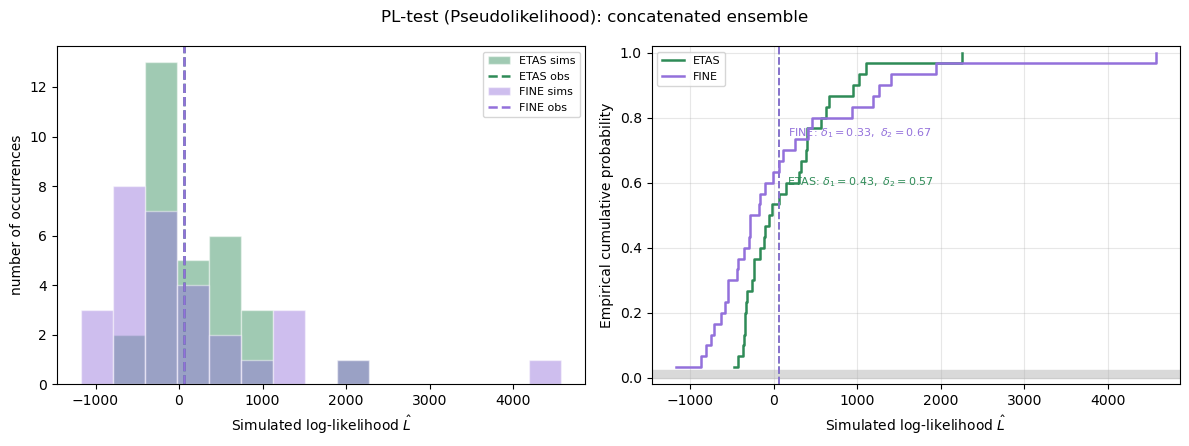

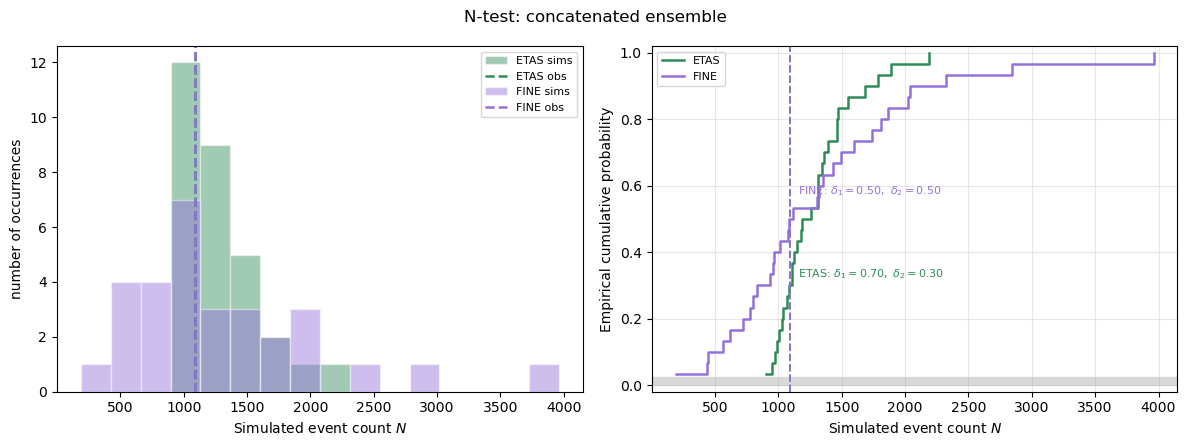

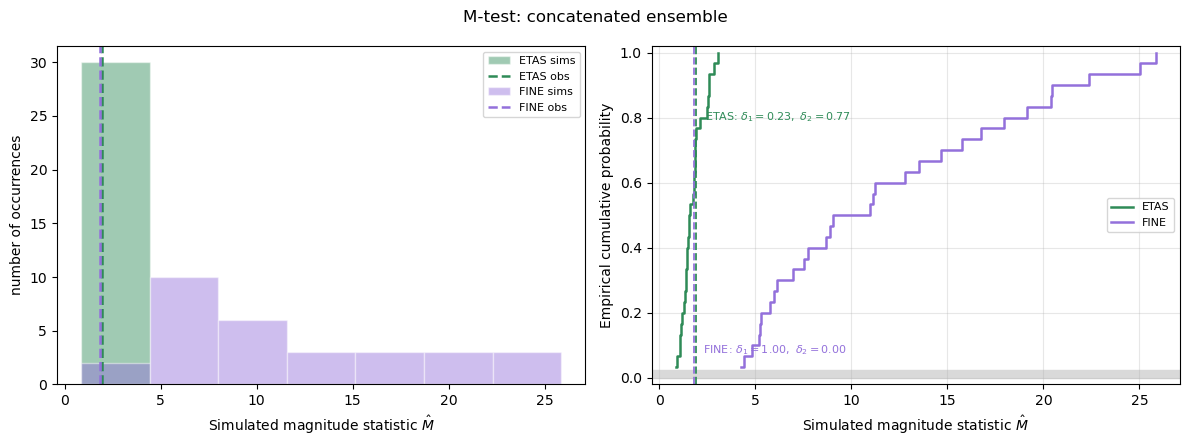

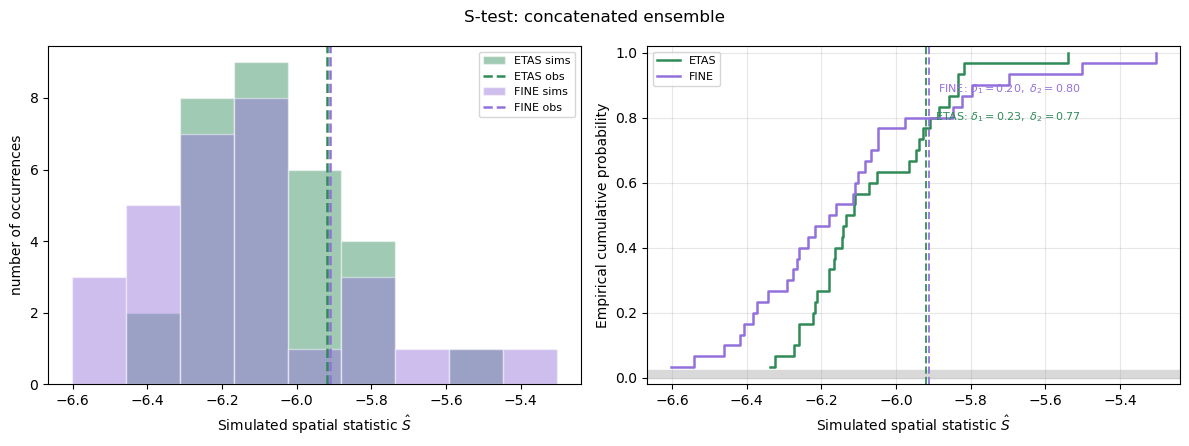

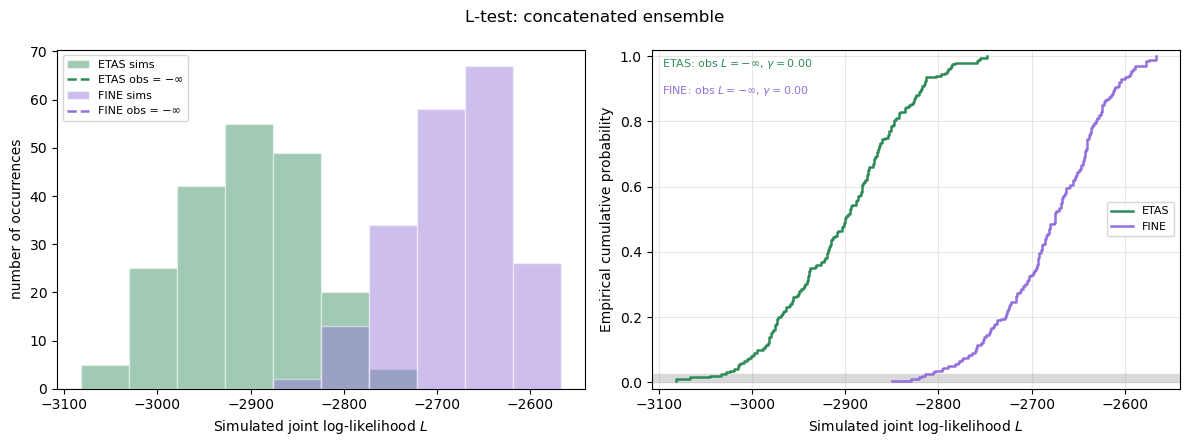

,method,ASS,area_below_diagonal,n_bins,n_target_bins
0,ETAS,0.950908,0.450908,5881,362.0
1,FINE,0.949146,0.449146,5881,362.0


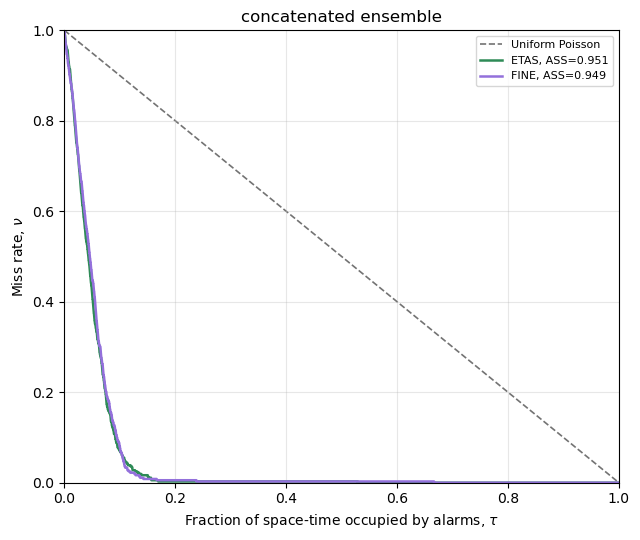

### Averaged intensity

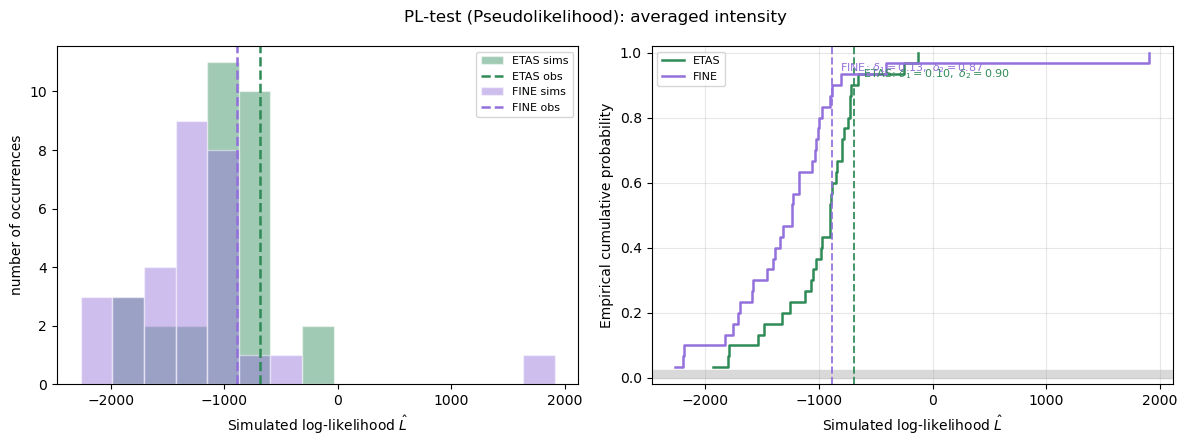

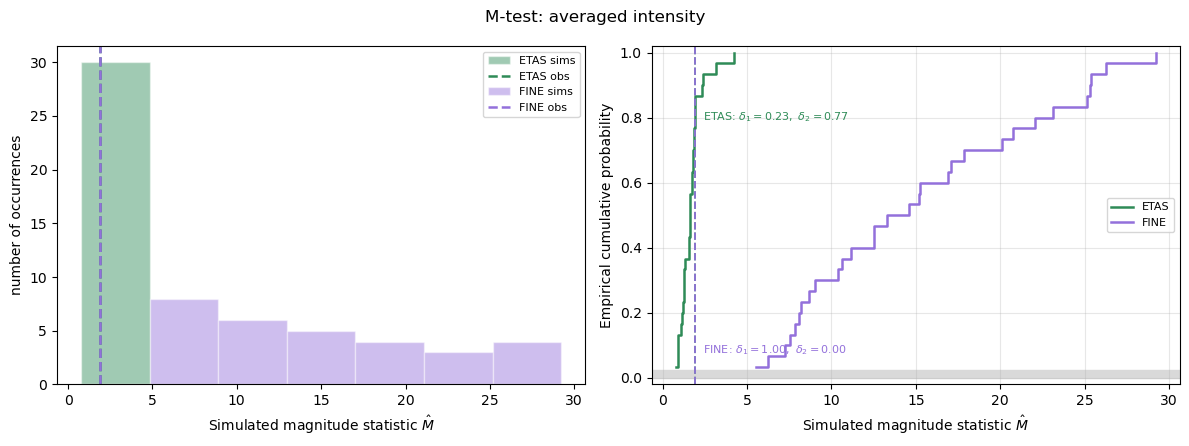

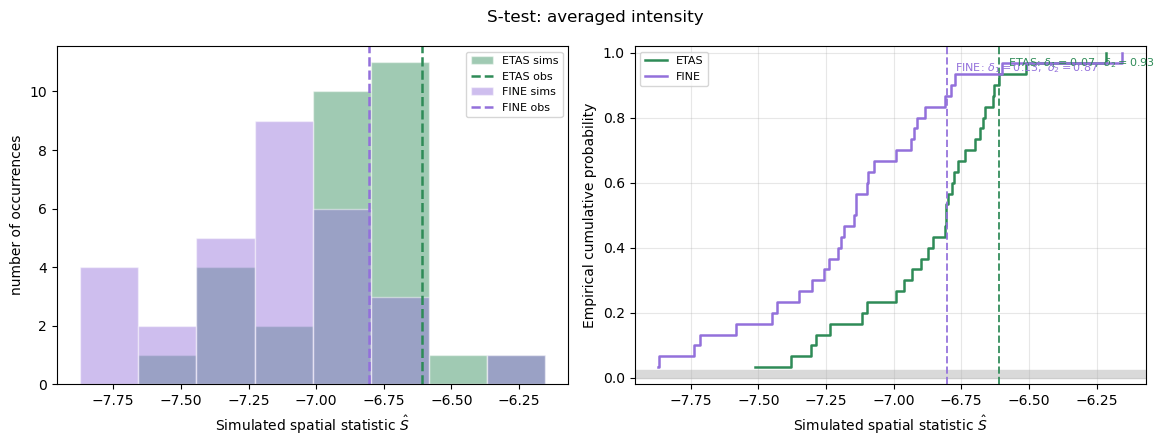

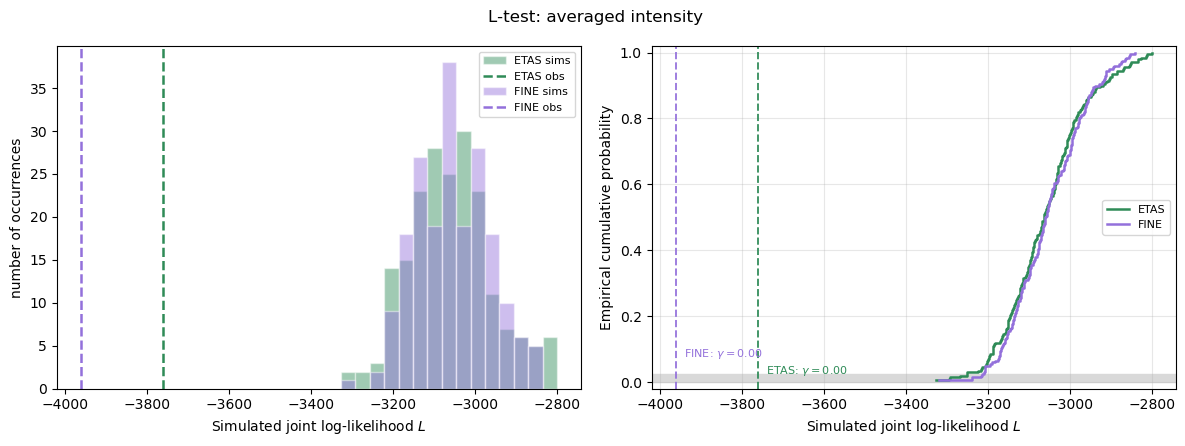

In [32]:
region, study_poly, fit = store.forecast_region()
m_ref = float(fit["m_ref"])
span_start = windows["forecast_start"].min().to_pydatetime()
span_end = windows["forecast_end"].max().to_pydatetime()


def _csep_frame(frame: pd.DataFrame) -> pd.DataFrame:
    out = frame.copy()
    out["time"] = pd.Timestamp("1970-01-01") + pd.to_timedelta(out["time_days"], unit="D")
    return out


def _forecasts():
    built = {}
    for method in METHODS:
        catalogs = [_csep_frame(seed_frames[method][seed]) for seed in SEEDS]
        built[method] = csep_utils.build_catalog_forecast_from_dataframes(
            catalogs,
            name=METHOD_LABELS.get(method, method),
            region=region,
            start_time=span_start,
            end_time=span_end,
            m_ref=m_ref,
            study_poly=study_poly,
        )
    return built


observed_csep = csep_utils.dataframe_to_csep_catalog(
    _csep_frame(observed), catalog_id=0, region=region,
)
catalog_forecasts = _forecasts()
catalog_scores = {
    method: csep_utils.run_csep_catalog_tests(
        forecast, observed_csep, include_l_test=True, l_test_simulations=200, l_test_seed=0,
    )
    for method, forecast in catalog_forecasts.items()
}
display(Markdown("### Concatenated catalogs"))
for fig in csep_utils.plot_csep_metric_overlays(
    catalog_scores, title="concatenated ensemble", colors=METHOD_COLORS, labels=METHOD_LABELS,
):
    show_fig(fig)
molchan_table, molchan_fig = csep_utils.molchan_comparison(
    catalog_forecasts, observed_csep, labels=METHOD_LABELS, colors=METHOD_COLORS,
    title="concatenated ensemble",
)
display(molchan_table)
if molchan_fig is not None:
    show_fig(molchan_fig)

rate_grids = store.mean_rate_grid()
intensity_scores = {}
for method, forecast in catalog_forecasts.items():
    previous_rates = forecast.expected_rates
    forecast.expected_rates = csep_utils.gridded_forecast_from_rates(
        rate_grids[method],
        region,
        forecast.start_time,
        forecast.end_time,
        f"{METHOD_LABELS.get(method, method)} intensity",
    )
    try:
        intensity_scores[method] = csep_utils.run_csep_catalog_tests(
            forecast, observed_csep, include_l_test=True, l_test_simulations=200, l_test_seed=1,
        )
    finally:
        forecast.expected_rates = previous_rates
display(Markdown("### Averaged intensity"))
for fig in csep_utils.plot_csep_metric_overlays(
    intensity_scores,
    title="averaged intensity",
    colors=METHOD_COLORS,
    labels=METHOD_LABELS,
    test_names=("PL-test (Pseudolikelihood)", "M-test", "S-test", "L-test"),
):
    show_fig(fig)


# Metrics per window

In [33]:
window_tests


,step_index,forecast_start,method,n_forecast,n_observed,nbd_variance,nbd_delta1,nbd_delta2,nbd_status,binary_cl_quantile,binary_cl_observed,binary_cl_status,nbd_consistent_95,binary_cl_consistent_95
0,0,2016-05-23 23:05:46,FINE,4.808848,3.0,36.685057,0.518454,0.566966,normal,0.110,-32.863146,normal,True,True
1,0,2016-05-23 23:05:46,etas,4.710345,3.0,24.667816,0.576620,0.525708,normal,0.125,-32.262666,normal,True,True
2,1,2016-05-30 23:05:46,FINE,8.806270,4.0,31.288506,0.840938,0.234625,normal,0.010,-45.738096,normal,True,False
3,1,2016-05-30 23:05:46,etas,5.761093,4.0,19.236782,0.640783,0.466306,normal,0.025,-43.005507,normal,True,False
4,2,2016-06-06 23:05:46,FINE,4.422612,15.0,15.443678,0.024769,0.981580,normal,0.490,-94.528147,normal,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
319,159,2019-06-10 23:05:46,etas,3.758841,11.0,9.840230,0.038389,0.973985,normal,0.345,-86.343341,normal,True,True
320,160,2019-06-17 23:05:46,FINE,4.668498,4.0,20.340230,0.494030,0.599836,normal,0.255,-37.511610,normal,True,True
321,160,2019-06-17 23:05:46,etas,5.347231,4.0,45.098851,0.461057,0.606805,normal,0.115,-39.065061,normal,True,True
322,161,2019-06-24 23:05:46,FINE,3.744629,3.0,17.527586,0.493627,0.610760,normal,0.670,-23.671118,normal,True,True


## Magnitude likelihoods

Before the test set is every labeled train and validation event of the FINE model. The test set is that model's full test split. Forecast rows are every loaded realization.

Pointwise density of each event's magnitude. FINE uses `metrics.kumaraswamy_mixture_instance` with the same shift, stretch, and Jacobian as `metrics.MinusLoglikelihoodConstShiftStretchLoss`. Observed events use the cached train, validation, and test features of that model. Forecast events use the same density, with history equal to the observed catalog up to the window plus earlier events in that realization and window.

ETAS uses the Gutenberg–Richter density `metrics.gr_likelihood` from the same package. The beta and completeness are the inversion values stored for the forecast window that contains the event. Events before the test set use the inversion fit on that pre-test catalog (the first window).

The score is the mean negative log density, the same summary the MAGNET benchmarks report. `runnable_code/cache_rolling_analysis.py` writes `analysis_cache/magnitude_likelihoods.csv` and reuses it on the next run. Each finished window is also saved to `magnitude_likelihoods.partial.csv`, so a stopped run continues instead of starting over. Set `RECOMPUTE_MAGNITUDE_LIKELIHOODS` to recompute.


magnitude likelihoods cached: 162 steps, 2 methods, 30 seeds


Magnitude likelihoods from `/home/neriberman/Repos/etas/outputs/rolling_continuation_hauksson_pre_ridgecrest/horizon_7d/analysis_cache/magnitude_likelihoods.csv` (109699 events).

### Mean negative log likelihood

,population,source,n_events,FINE_mean_neg_log_likelihood,FINE_n_finite,ETAS_mean_neg_log_likelihood,ETAS_n_finite
0,before_test,observed,27990,0.153611,27990,0.206133,27990
1,test,observed,3407,0.258695,3407,0.307546,3407
2,forecast,all realizations,78302,0.257611,78302,0.249418,78302
3,forecast,ETAS,38681,0.363137,38681,0.327021,38681
4,forecast,FINE,39621,0.154588,39621,0.173656,39621


### Forecast realizations

,source,seed,n_events,FINE_mean_neg_log_likelihood,ETAS_mean_neg_log_likelihood
0,FINE,10,2324,0.322596,0.354383
1,FINE,11,968,-0.356181,-0.290038
2,FINE,12,954,-0.151405,-0.106472
3,FINE,13,782,-0.185378,-0.114001
4,FINE,14,2842,0.673501,0.569723
5,FINE,15,2035,0.135770,0.291899
6,FINE,16,1595,0.068688,0.072479
7,FINE,17,1112,-0.124611,-0.071494
8,FINE,18,1735,0.136459,0.031191
9,FINE,19,1355,-0.177243,-0.159090


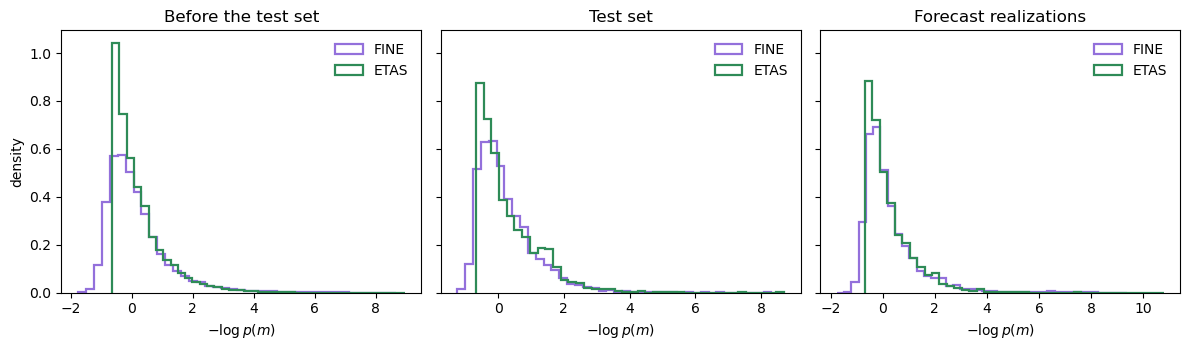

In [34]:
RECOMPUTE_MAGNITUDE_LIKELIHOODS = False

likelihood_events = rolling_analysis.magnitude_likelihoods(
    store,
    config_path=Path(ROLLING_CONFIG_PATH),
    repo_root=REPO_ROOT,
    force=bool(RECOMPUTE_MAGNITUDE_LIKELIHOODS),
    progress=lambda message: print(message, flush=True),
)
display(Markdown(
    f"Magnitude likelihoods from `{store.cache_dir / 'magnitude_likelihoods.csv'}` "
    f"({len(likelihood_events)} events)."
))


def _mean_neg_log_likelihood(density: np.ndarray) -> tuple[float, int]:
    log_density = np.log(np.asarray(density, dtype=float))
    finite = np.isfinite(log_density)
    if not np.any(finite):
        return float("nan"), 0
    return float(-np.mean(log_density[finite])), int(np.sum(finite))


def _summary_row(frame: pd.DataFrame, population: str, source: str) -> dict:
    fine_nll, fine_n = _mean_neg_log_likelihood(frame["fine_likelihood"])
    etas_nll, etas_n = _mean_neg_log_likelihood(frame["etas_likelihood"])
    return {
        "population": population,
        "source": source,
        "n_events": int(len(frame)),
        "FINE_mean_neg_log_likelihood": fine_nll,
        "FINE_n_finite": fine_n,
        "ETAS_mean_neg_log_likelihood": etas_nll,
        "ETAS_n_finite": etas_n,
    }


summary_rows = [
    _summary_row(
        likelihood_events.loc[likelihood_events["population"] == "before_test"],
        "before_test",
        "observed",
    ),
    _summary_row(
        likelihood_events.loc[likelihood_events["population"] == "test"],
        "test",
        "observed",
    ),
]
forecast_events = likelihood_events.loc[likelihood_events["population"] == "forecast"]
summary_rows.append(_summary_row(forecast_events, "forecast", "all realizations"))
for method in METHODS:
    summary_rows.append(_summary_row(
        forecast_events.loc[forecast_events["source"] == method],
        "forecast",
        METHOD_LABELS.get(method, method),
    ))
likelihood_summary = pd.DataFrame(summary_rows)
display(Markdown("### Mean negative log likelihood"))
display(likelihood_summary)

seed_rows = []
for (source, seed), frame in forecast_events.groupby(["source", "seed"], sort=True):
    fine_nll, _fine_n = _mean_neg_log_likelihood(frame["fine_likelihood"])
    etas_nll, _etas_n = _mean_neg_log_likelihood(frame["etas_likelihood"])
    seed_rows.append({
        "source": source,
        "seed": int(seed),
        "n_events": int(len(frame)),
        "FINE_mean_neg_log_likelihood": fine_nll,
        "ETAS_mean_neg_log_likelihood": etas_nll,
    })
per_seed = pd.DataFrame(seed_rows)
display(Markdown("### Forecast realizations"))
display(per_seed)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.6), sharey=True)
panels = (
    ("before_test", "observed", "Before the test set"),
    ("test", "observed", "Test set"),
    ("forecast", None, "Forecast realizations"),
)
for axis, (population, source, title) in zip(axes, panels):
    frame = likelihood_events.loc[likelihood_events["population"] == population]
    if source is not None:
        frame = frame.loc[frame["source"] == source]
    for column, method, label in (
        ("fine_likelihood", "FINE", "FINE"),
        ("etas_likelihood", "etas", "ETAS"),
    ):
        log_density = np.log(frame[column].to_numpy(dtype=float))
        finite = log_density[np.isfinite(log_density)]
        if finite.size == 0:
            continue
        axis.hist(
            -finite,
            bins=40,
            density=True,
            histtype="step",
            linewidth=1.6,
            color=METHOD_COLORS.get(method, "0.3"),
            label=label,
        )
    axis.set_title(title)
    axis.set_xlabel(r"$-\log p(m)$")
    axis.legend(frameon=False)
axes[0].set_ylabel("density")
fig.tight_layout()
show_fig(fig)


## Magnitude likelihood plots

Bars are the mean negative log likelihood. The violin and the mean bar with a standard-deviation error bar summarize every loaded forecast realization. The last bar is one realization, chosen with a fixed seed and named in the title.


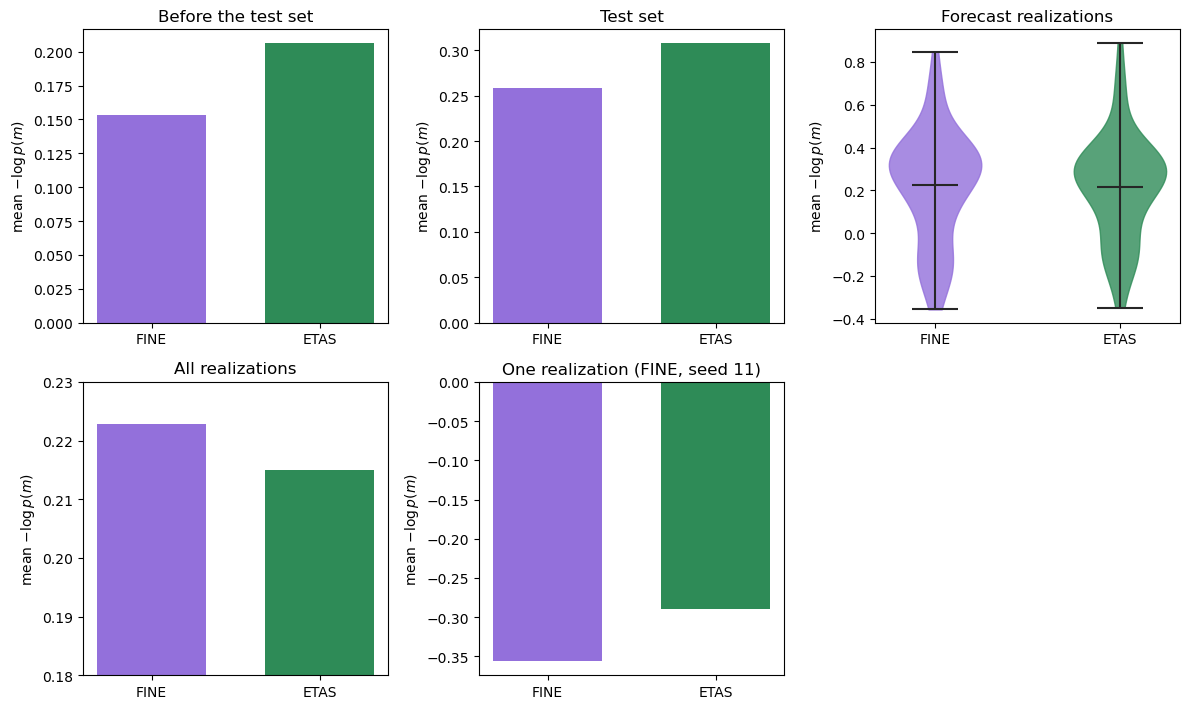

In [43]:
def _mean_neg_log_likelihood(density: np.ndarray) -> tuple[float, int]:
    log_density = np.log(np.asarray(density, dtype=float))
    finite = np.isfinite(log_density)
    if not np.any(finite):
        return float("nan"), 0
    return float(-np.mean(log_density[finite])), int(np.sum(finite))


def _score_pair(frame: pd.DataFrame) -> tuple[float, float]:
    fine, _fine_n = _mean_neg_log_likelihood(frame["fine_likelihood"])
    etas, _etas_n = _mean_neg_log_likelihood(frame["etas_likelihood"])
    return fine, etas


def _model_bars(axis, values, yerr=None):
    axis.bar(
        model_names,
        values,
        color=model_colors,
        width=0.65,
        yerr=yerr,
        capsize=4,
        error_kw={"elinewidth": 1.2, "ecolor": "0.15"},
    )
    axis.set_ylabel(r"mean $-\log p(m)$")


model_names = ["FINE", "ETAS"]
model_colors = [METHOD_COLORS.get("FINE", "C0"), METHOD_COLORS.get("etas", "C1")]
observed = {
    "before_test": likelihood_events.loc[
        (likelihood_events["population"] == "before_test")
        & (likelihood_events["source"] == "observed")
    ],
    "test": likelihood_events.loc[
        (likelihood_events["population"] == "test")
        & (likelihood_events["source"] == "observed")
    ],
}
forecast = likelihood_events.loc[likelihood_events["population"] == "forecast"]
realization_rows = []
for (source, seed), frame in forecast.groupby(["source", "seed"], sort=True):
    fine_nll, etas_nll = _score_pair(frame)
    realization_rows.append({
        "source": source,
        "seed": int(seed),
        "FINE": fine_nll,
        "ETAS": etas_nll,
    })
realization_scores = pd.DataFrame(realization_rows)
picked = realization_scores.sample(n=1, random_state=50).iloc[0]

fig, axes = plt.subplots(2, 3, figsize=(12, 7.2))
for axis, population, title in (
    (axes[0, 0], "before_test", "Before the test set"),
    (axes[0, 1], "test", "Test set"),
):
    _model_bars(axis, _score_pair(observed[population]))
    axis.set_title(title)

parts = axes[0, 2].violinplot(
    [realization_scores["FINE"], realization_scores["ETAS"]],
    positions=[0, 1],
    showmeans=True,
    showmedians=False,
)
for body, color in zip(parts["bodies"], model_colors):
    body.set_facecolor(color)
    body.set_edgecolor(color)
    body.set_alpha(0.8)
for key in ("cbars", "cmins", "cmaxes", "cmeans"):
    if key in parts:
        parts[key].set_color("0.15")
axes[0, 2].set_xticks([0, 1])
axes[0, 2].set_xticklabels(model_names)
axes[0, 2].set_title("Forecast realizations")
axes[0, 2].set_ylabel(r"mean $-\log p(m)$")

_model_bars(
    axes[1, 0],
    [realization_scores["FINE"].mean(), realization_scores["ETAS"].mean()],
    # yerr=[
    #     realization_scores["FINE"].std(ddof=1),
    #     realization_scores["ETAS"].std(ddof=1),
    # ],
)
axes[1, 0].set_title("All realizations")
axes[1, 0].set_ylim(0.18, 0.23)

_model_bars(axes[1, 1], [picked["FINE"], picked["ETAS"]])
axes[1, 1].set_title(
    f"One realization ({METHOD_LABELS.get(picked['source'], picked['source'])}, seed {int(picked['seed'])})"
)
axes[1, 2].axis("off")
fig.tight_layout()
show_fig(fig)
